# Afya Flow

### Hospital-Wide Outpatient Demand & Resource Allocation Prototype

### AIC Kijabe Hospital
AIC Kijabe Hospital is located in Kijabe, Kiambu County, Kenya, started as Kijabe Station was first established by missionaries from AIM as an outpost in 1903 upgrading first hospital at Kijabe, Theodora Hospital, was established in 1915. This served the medical needs of the area until the present complex was begun.
Today, Kijabe Hospital is a non-profit, 363-bed hospital owned and operated by AIC of Kenya as part of a network of four hospitals and 45 dispensaries. It has 1,078 employees as of Jul 26 and strives to balance Kenyan and missionary consultants. The hospital has daily average visits of about 355 and monthly average vistis of 10,677 patients a broad range of inpatient and outpatient curative services to people from the surrounding farming communities.

### Project Overview

The model uses historical outpatient records to identify patterns in patient attendance and predict periods of high demand across hospital departments. These insights will support  staff in providing medical services and efficient resource allocation, helping the hospital reduce congestion and improve patient flow.


# Business Understanding

### Problem Definition

Kijabe experiences variation in patient volumes across days and departments, making it difficult to anticipate where demand will occur and whether available capacity will be sufficient. During high-demand periods, patient volumes may exceed the available clinical capacity, contributing to congestion, longer waiting times and increased pressure on staff and resources. For instance patient volumes vary by day where weekdays have higher visits than weekends with with an average of 35 - 69 vists per hour during peak working hours potentially contribution to longer wait times for patients

### Business Objectives

AfyaFlow aims to use Kijabe Hospital's historical outpatient data and relevant internal operational factors to understand and predict patient demand across the hospital. The goal is to identify where and when high patient volumes are likely to occur and provide insights that can support proactive planning and decision-making.

The project aims:
- To predict outpatient demand in the hospital and time periods.
- To identify departments, days, and time periods that are most likely to experience high patient volumes and congestion.
- To analyse historical patterns and factors that influence changes in outpatient demand.
- To support decisions on how available clinicians and resources can be allocated based on predicted demand.
- To provide hospital-wide insights to support capacity planning and improve patient flow.

### Research Questions
* How can historical patient data and predictive analytics be used to anticipate patient demand and support capacity planning to reduce congestion at Kijabe Hospital?
* What temporal patterns influence patient demand at Kijabe Hospital?
* Can patient-level historical patterns identify recurring patients and help explain predictable components of hospital demand?
* Can a scenario-based simulation help hospital decision-makers evaluate the potential effect of resource allocation decisions on congestion?
  
### Key Stakeholders

* Hospital Management: Requires hospital-wide demand insights to support capacity, staffing, and resource planning.
* Department Managers: Need demand forecasts to prepare for expected changes in patient volumes.
* Clinicians and Nurses: Benefit from better planning and distribution of workload and available clinical capacity.
* Patients: Benefit from improved patient flow, reduced waiting times, and more efficient service delivery.

### Data Science Tasks

The project will analyse Kijabe Hospital's historical outpatient data to identify patterns in patient attendance across departments and different time periods. Predictive models will then be developed to forecast future outpatient demand and identify periods of potentially high patient volumes. These predictions will be translated into decision-support insights to help the hospital plan staffing and resources according to anticipated demand.

# Data Understanding

### Data Overview

Opd_data.csv comes from Kijabe Hospital's outpatient records system. It has 306,306 rows and 6 columns, covering 1 June 2024 to 19 August 2026 (about 26.5 months, with the last month not fully complete). This is the only data we have for the project so far there's no separate data on staff numbers or bed availability yet.

#### Column Description
* PatientNumber - Represents the unique hospital identifier assigned to each patient. It is used to link repeat visits to the same individual and is not a row identifier, since one patient can appear many times.
* RegistrationDate - Represents the date and time at which the patient was registered into a service queue. This is the main temporal field in the dataset and provides the year, month, day of week and hour used for demand analysis.
* Gender - Represents the gender of the patient, recorded as Male or Female.
* Age - Represents the age of the patient at the time of registration, recorded as text with a unit attached, for example "38 Yr(s)", "6 Mth(s)", "3 Week(s)" or "5 Days(s)".
* QueuedTo - Represents the department or clinic the patient was queued to, for example General OPD, MCH, Chronic Care Clinic, Oncology, Renal or Dental. This is the main department field and the unit at which demand is analysed.
* ConsultDescription - Represents the type or purpose of the consultation the patient was booked for, for example General Outpatient Care, Admission, Chemotherapy, MCH Clinic or ENT Return Visit. It gives a finer-
grained view of service type within a department, and also distinguishes new visits from return visits.


In [1]:
# Library Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import time

import warnings
warnings.filterwarnings("ignore")

#Load Dataset
data =  pd.read_csv("Opd_data.csv")

dept_counts = data["QueuedTo"].value_counts().head(20)

In [2]:
#basic understanding of the datset
print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns\n')
print('Dataset Columns:\n',data.columns)
print('\n Dataset Data types:\n',data.dtypes)

The dataset has 306306 rows and 6 columns

Dataset Columns:
 Index(['PatientNumber', 'RegistrationDate', 'Gender', 'Age', 'QueuedTo',
       'ConsultDescription'],
      dtype='object')

 Dataset Data types:
 PatientNumber         object
RegistrationDate      object
Gender                object
Age                   object
QueuedTo              object
ConsultDescription    object
dtype: object


Observation: The dataset has 6 columns. All the data types are correct apart fromthe age columns that should be numeric

In [3]:
#Checking Info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306306 entries, 0 to 306305
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   PatientNumber       306306 non-null  object
 1   RegistrationDate    306306 non-null  object
 2   Gender              306291 non-null  object
 3   Age                 305735 non-null  object
 4   QueuedTo            299528 non-null  object
 5   ConsultDescription  299920 non-null  object
dtypes: object(6)
memory usage: 14.0+ MB


In [4]:
#checking statistics
data.describe(include='O')

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
count,306306,306306,306291,305735,299528,299920
unique,80928,202637,4,142,44,79
top,010099285,04-Feb-2025 00:00,Female,2 Yr(s),GENERAL OPD,General Outpatient Care
freq,266,45,142251,7464,85959,49377


In [5]:
#Checking dataset uniformity
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010575758,01-Jun-2024 00:00,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
1,010575713,01-Jun-2024 00:00,Female,29 Yr(s),NaN,NaN
2,010569291,01-Jun-2024 00:04,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,01-Jun-2024 00:04,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,01-Jun-2024 00:10,Female,2 Yr(s),ADMISSION,Admission


In [6]:
data.tail()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
306301,010625187,19-Aug-2026 11:39,Male,3 Mth(s),DAYCASE,DAYCASE
306302,010631396,19-Aug-2026 11:40,Female,1 Week(s),MCH,Child Welfare and Immunization (CWC)
306303,010632308,19-Aug-2026 11:41,Male,45 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
306304,010592441,19-Aug-2026 11:41,Male,18 Mth(s),PAEDS BKKH,Pediatrics
306305,010621962,19-Aug-2026 11:41,Female,30 Yr(s),MCH,MCH Clinic


In [7]:
data.sample(5)

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
158166,010603191,14-Aug-2025 08:01,Female,69 Yr(s),MEB SPECIALITY CLINIC,GYNAECOLOGY
221356,010015944,27-Jan-2026 12:06,FEMALE,51 Yr(s),PHYSIOTHERAPY,Physiotherapy
181600,010608565,14-Oct-2025 09:08,Female,70 Yr(s),ADMISSION,Admission
44156,010582788,03-Oct-2024 10:34,Male,23 Mth(s),MCH,MCH Clinic
116877,010591167,28-Apr-2025 00:00,Male,72 Yr(s),DAYCASE,DAYCASE


Observation: The data is uniform, however the gender column and consultdescription has a mix of uppercase and lowercase letters

In [8]:
print(data['QueuedTo'].unique())

['GENERAL OPD ' nan 'ADMISSION' 'CASUALTY' 'Gen Surg OPD' 'RENAL' 'MCH'
 'PHYSIOTHERAPY' 'DAYCASE' 'DENTAL' 'SPECIALITY CLINIC' 'PSYCHOLOGY'
 'OHNS' 'ONCOLOGY' 'PRIVATE CLINIC' 'EYE CLINIC' 'PAEDS BKKH'
 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)' 'Ortho OPD' 'PALLIATIVE'
 'Audiology' 'NUTRITION' 'OCCUPATIONAL THERAPY'
 'NEURO SURGERY CONSULTATION' 'FAMILY MEDICINE' 'DIABETIC CLINIC'
 'FAMILY CLINIC' 'Gynae OPD' 'MATERNITY NURSERY' 'TELEMEDICINE' 'MORGUE'
 'CARDIOLOGY' 'KJ000104/19' 'PAEDS' 'RESPIRATORY CENTER' 'HTS' 'PATHOLOGY'
 'MENTAL HEALTH' 'Naivasha Town Clinic' 'MEB SPECIALITY CLINIC'
 'NEUROSURGERY' 'PEDIATRIC NEUROLOGY' 'MEB PHYSIOTHERAPY' 'ANAESTHESIA'
 'All']


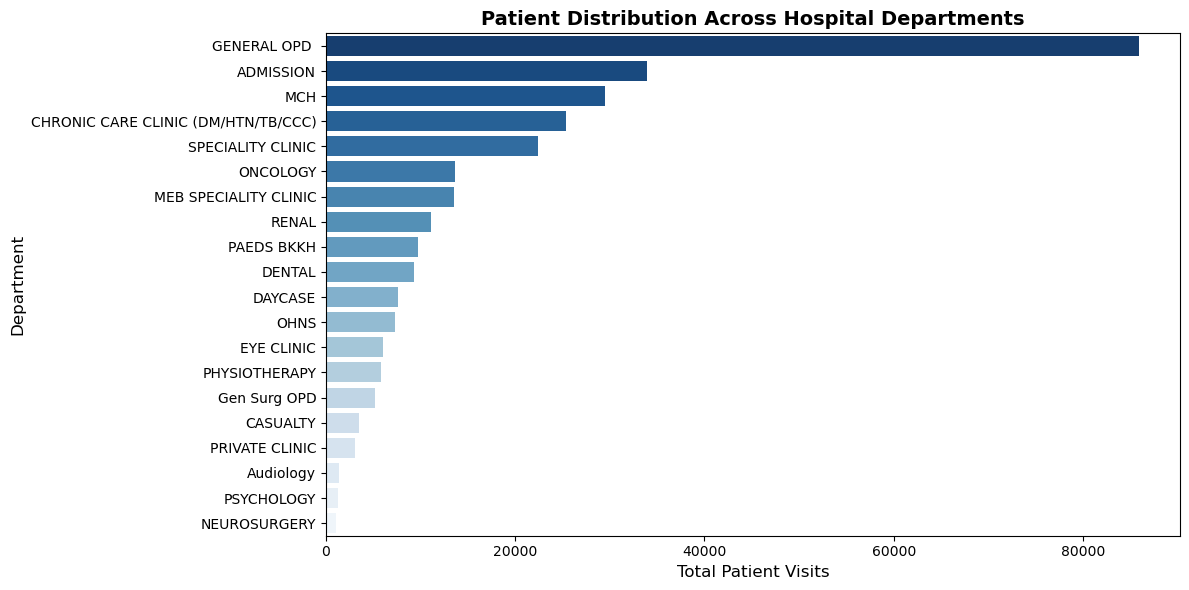

In [9]:
plt.figure(figsize=(12, 6))

# visits per department and sort descending for top 20
dept_counts = data["QueuedTo"].value_counts().head(20)

# horizontal bar plot
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r")

plt.title("Patient Distribution Across Hospital Departments", fontsize=14, fontweight="bold")
plt.xlabel("Total Patient Visits", fontsize=12)
plt.ylabel("Department", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
print(data['ConsultDescription'].unique())

['GEneral Outpatient Care( NEW )' nan 'General Outpatient Care'
 'Admission' 'EMERGENCY' 'CONSULT' 'RENAL DIALYSIS'
 'Child Welfare and Immunization (CWC)' 'MCH Clinic' 'Physiotherapy'
 'MCH (New Patient)' 'DAYCASE' 'Dental Care' 'ORTHOPEDIC' 'UROLOGY'
 'COUNSELLING PSYCHOLOGY' 'ENT First Visit' 'Chemotherapy'
 'GENERAL SURGERY' 'Ophthalmology.' 'ENT Return Visit' 'Pediatrics '
 'Comprehensive Care Centre (CCC)' 'Developmental Clinic '
 'Palliative Revisit' 'Diabetic clinic' 'Staff Clinic' 'ECHO'
 'Gen Surg OPD' 'PLASTICS' 'Cardiology' 'ONCOLOGY CONSULTATION' 'RVA'
 'GYNAECOLOGY' 'Nutrition Consult' 'OCCUPATIONAL THERAPY'
 'SPECIALITY IMED' 'BREAST' 'ANC Revisit' 'Family Planning'
 'Consultant Clinic' 'Paediatric Psychiatry' 'Psychiatry'
 'RENAL CONSULTATION' 'Oncology Service' 'Revisit' 'Counselling'
 'Hepatitis b vaccine' 'PEADS SURGE' 'Clinical psychology consultation'
 'TB CLINIC' 'Postnatal (PNC)' 'HAND CLINIC' 'HYPERTENSION CLINIC'
 'Gyn-oncology' 'Surgical OPD' 'TELEMEDICINE' 'E

In [11]:
#checking for missing values
data.isna().sum()

PatientNumber            0
RegistrationDate         0
Gender                  15
Age                    571
QueuedTo              6778
ConsultDescription    6386
dtype: int64

In [12]:
missing = data.isnull().sum()
missing_percent = (missing/len(data)) * 100
pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

,Missing Count,Missing %
PatientNumber,0,0.000000
RegistrationDate,0,0.000000
Gender,15,0.004897
Age,571,0.186415
QueuedTo,6778,2.212820
ConsultDescription,6386,2.084843


Observation: There are missing values, however they make up a small percentage of the whole data so dropping them will not cause us to lose important insights of the data

In [13]:
#checking for duplicated values
data.duplicated().sum()

np.int64(355)

Observation: We will drop these duplicate values so that we ensure our model learns actual patterns and not repetative ones

In [14]:
#checking how many patients have visited hospital
print(data['PatientNumber'].nunique())
print(len(data))

80928
306306


observation: 80928 patients visited the hospital and the length of the data being larger indicated that there has been patients who have returned to the hospital

In [15]:
# example of return patients
visits = data['PatientNumber'].value_counts()
visits.head()

PatientNumber
010099285    266
010543010    252
010527584    249
010112639    248
010315077    247
Name: count, dtype: int64

In [16]:
# Minimum and maximum dates
dates = pd.to_datetime(data['RegistrationDate'], errors='coerce')
print(f'min: {dates.min()}')
print(f'max: {dates.max()}')

# Time destribution
dates.dt.hour.value_counts().sort_index()

min: 2024-06-01 00:00:00
max: 2026-08-19 11:41:00


RegistrationDate
0     19822
1      1679
2      1042
3       958
4      1627
5      4440
6      9234
7     25072
8     55567
9     51437
10    35298
11    28744
12    20167
13    12188
14    10107
15     8478
16     6645
17     3638
18     2567
19     2085
20     1771
21     1543
22     1245
23      952
Name: count, dtype: int64

Text(0, 0.5, 'Number of patients')

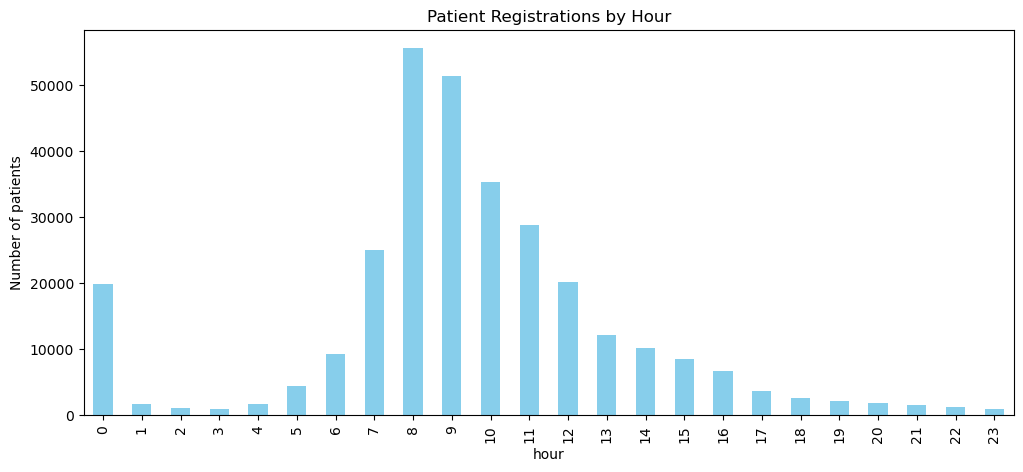

In [17]:
#visual
data["temp_datetime"] = dates
data["hour"] = dates.dt.hour

data["hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12,5),
    title="Patient Registrations by Hour",
    color='skyblue')
plt.ylabel('Number of patients')

Observation: The busiest hours of the day are usually within 07:00 and 14:00 having the high number of patients. From the time range 08:00 and 09:00 are the busiest

In [18]:
# daily visits
data['temp_datetime'].dt.day_name().value_counts()

temp_datetime
Monday       60299
Tuesday      59702
Thursday     59142
Wednesday    55624
Friday       52464
Saturday     11339
Sunday        7736
Name: count, dtype: int64

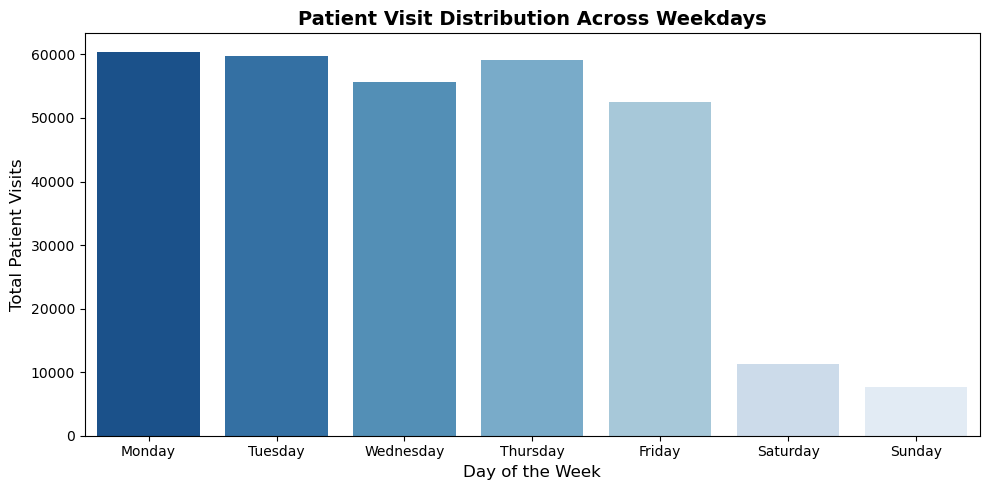

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")
data["day_of_week"] = data["RegistrationDate"].dt.day_name()

# Define chronological weekday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

# Count visits per weekday and reindex
weekday_counts = data["day_of_week"].value_counts().reindex(weekday_order)

# Plot distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette="Blues_r")
plt.title("Patient Visit Distribution Across Weekdays", fontsize=14, fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Patient Visits", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Monday Peak*

Patient volume is highest on Monday and declines steadily through the week,
consistent with backlog from the weekend clearing at the start of the week.

*Weekend Drop-off*

Volumes decline sharply over the weekend, reflecting reduced ambulatory service
hours and limited elective scheduling, which leaves emergency and inpatient
units handling the baseline load.

In [20]:
#Number of departments and how many visits
print(f'Number of departments:', data["QueuedTo"].nunique())
data['QueuedTo'].value_counts(dropna=False)

Number of departments: 44


QueuedTo
GENERAL OPD                            85959
ADMISSION                              33880
MCH                                    29467
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25366
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
MEB SPECIALITY CLINIC                  13523
RENAL                                  11103
PAEDS BKKH                              9734
DENTAL                                  9252
DAYCASE                                 7596
OHNS                                    7290
NaN                                     6778
EYE CLINIC                              6027
PHYSIOTHERAPY                           5826
Gen Surg OPD                            5156
CASUALTY                                3460
PRIVATE CLINIC                          3075
Audiology                               1379
PSYCHOLOGY                              1223
NEUROSURGERY                            1032
OCCUPATIONAL THERAPY                     815
N

In [21]:
# Visits per consultation type
data["ConsultDescription"].value_counts(dropna=False)

ConsultDescription
General Outpatient Care           49377
Admission                         33886
CONSULT                           33336
GEneral Outpatient Care( NEW )    21398
MCH Clinic                        19465
                                  ...  
PAIN CLINIC                           2
Staff Wellness Package                1
HEAD AND NECK VISIT                   1
Head & Neck Return Visit              1
Private Gyn Oncology                  1
Name: count, Length: 80, dtype: int64

Observation: Majority visits are:
- General Outpatient Care           
- Admission                         
- CONSULT

In [22]:
#Distribution of gender
data["Gender"].value_counts(dropna=False)


Gender
Female    142251
Male      112802
FEMALE     32185
MALE       19053
NaN           15
Name: count, dtype: int64

Observation: Theres inconsistent formating which needs to be cleaned

In [23]:
#Age distribution
data["Age"].value_counts()

Age
2 Yr(s)      7464
31 Yr(s)     5741
30 Yr(s)     5533
29 Yr(s)     5418
33 Yr(s)     5255
             ... 
2 Days(s)       2
121 Yr(s)       1
107 Yr(s)       1
117 Yr(s)       1
3 Days(s)       1
Name: count, Length: 142, dtype: int64

Observation

1. Data description
- What's in it: Patient ID, registration date/time, gender, age (written as text, like "38 Yr(s)"), which department the patient was sent to (44 possible departments), and the type of visit (79 possible types). Everything is text or dates no ready-made numbers or categories yet.
- Who the patients are: 80,928 different patients, visiting 3.8 times on average. About 57% are female, 43% male. Median age is 40. Most patients only come once (39%), but a small group (7.7%) comes 10+ times, likely people with ongoing conditions needing regular care.
- Departments: 7 out of 44 departments make up about 70% of all visits, General Outpatient, Admission, MCH, Chronic Care, Speciality Clinic, Oncology, and Renal. The rest get far fewer visits.
- Patterns over time: More patients come on weekdays than weekends, with Monday the busiest and weekends much quieter. Most patients arrive between 8-9am, then it tapers off through the day. 

2. Verify Data Quality

These are common problems in hospital records like this none of them are serious enough to stop the project, but they all need fixing before we build any models:

- Missing information: some rows are missing gender (15), age (571), department (6,778), or visit type (6,386). The missing department and visit type are the most important to fix, since they're central to what we're trying to study.
- 355 rows are exact copies of another row which are probably accidental double entries.
- Gender is written inconsistently: sometimes "Male", sometimes "MALE".
- Visit types are written inconsistently too, with typos and different spellings for what should be the same thing (e.g. "General Outpatient Care" vs "GEneral Outpatient Care( NEW )"). We'll need to fix the typos but keep any real differences, like whether it's a new or returning patient.
- Age is written as text, not numbers, and mixes different units (years, months, weeks, days), so it needs to be converted before we can use it.
- A few ages are unrealistic (over 110 years old) — most likely mistakes.
- 3 rows list departments that don't make sense — they look like test entries, not real departments.
- 10,292 rows show an exact midnight timestamp, which is probably just a placeholder for "we don't know the exact time" rather than real midnight visits — so we should be careful using time-of-day data for these.

# Data Cleaning

### Missing Values

In [24]:
# missing dependable columns queuedto & consultdescription
missing_counts = data[["QueuedTo", "ConsultDescription"]].isna().sum()
print(print(missing_counts))

QueuedTo              6778
ConsultDescription    6386
dtype: int64
None


In [25]:
# boolean to check for rows where both are null
both_missing = data["QueuedTo"].isna() & data["ConsultDescription"].isna()

print(f"Rows where both are missing: {both_missing.sum()}")

Rows where both are missing: 6386


In [26]:
# A side by side comparison of both columns for rows where at least one is missing
missing_audit = data[data["QueuedTo"].isna() | data["ConsultDescription"].isna()]

missing_audit[["PatientNumber", "RegistrationDate", "QueuedTo", "ConsultDescription",]].sample(5)

,PatientNumber,RegistrationDate,QueuedTo,ConsultDescription
155743,010604159,2025-08-08,NaN,NaN
196710,010611727,2025-11-20,NaN,NaN
19854,010578876,2024-07-29,NaN,NaN
187926,010604814,2025-10-30,NaN,NaN
70099,010582482,2024-12-19,NaN,NaN


**Observation:**

Correlated missing values

The missing counts in 'QueuedTo' and 'ConsultDescription' columns are close in magnitude 6778 and 6386 missing values respectively suggesting that the missing values often occur as an unregistered patient encounters where routing metdata was never logged



In [27]:
# drop rows where both queuedto and consultdescription are nan
df_cleaned = data.dropna(subset=["QueuedTo", "ConsultDescription"], inplace=True)

In [28]:
missing_counts2 = data[["QueuedTo", "ConsultDescription"]].isna().sum()
print(print(missing_counts2))

QueuedTo              0
ConsultDescription    0
dtype: int64
None


### Duplicates

In [29]:
data[data.duplicated(keep=False)].sort_values('PatientNumber').head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
172478,010607509,2025-09-19 17:03:00,Male,18 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:03:00,17,Friday
172479,010607509,2025-09-19 17:03:00,Male,18 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:03:00,17,Friday
172484,010607511,2025-09-19 17:47:00,Female,22 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:47:00,17,Friday
172485,010607511,2025-09-19 17:47:00,Female,22 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:47:00,17,Friday
172494,010607515,2025-09-19 21:22:00,Female,21 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 21:22:00,21,Friday


**Observation**

Recorded variables i.e PatientNumber, RegistrationDate, Gender, Age, QueuedTo	ConsultDescription match identically between paired index rows confirming complete transactional duplication rather than clinical routing

In [30]:
# total duplicates
data.duplicated().sum()

np.int64(355)

In [31]:
# total unique duplicates
print(data.duplicated(subset=["PatientNumber", "RegistrationDate"]).sum())

366


In [32]:
# drop duplicates
data = data.drop_duplicates()

data.duplicated().sum()

np.int64(0)

In [33]:
dupes = data[data.duplicated(subset=["PatientNumber", "RegistrationDate"],keep=False)
            ].sort_values(["PatientNumber", "RegistrationDate"])

dupes

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
193239,010611177,2025-11-11 13:40:00,Female,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-11-11 13:40:00,13,Tuesday
193240,010611177,2025-11-11 13:40:00,Female,54 Yr(s),ADMISSION,Admission,2025-11-11 13:40:00,13,Tuesday
201188,010612669,2025-12-01 15:09:00,Female,54 Yr(s),GENERAL OPD,CONSULT,2025-12-01 15:09:00,15,Monday
201189,010612669,2025-12-01 15:09:00,Female,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-12-01 15:09:00,15,Monday
208810,010614068,2025-12-21 20:15:00,Female,68 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-12-21 20:15:00,20,Sunday
208811,010614068,2025-12-21 20:15:00,Female,68 Yr(s),ADMISSION,Admission,2025-12-21 20:15:00,20,Sunday
245573,010621065,2026-03-24 20:39:00,Male,43 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2026-03-24 20:39:00,20,Tuesday
245574,010621065,2026-03-24 20:39:00,Male,43 Yr(s),GENERAL OPD,CONSULT,2026-03-24 20:39:00,20,Tuesday
245923,010621132,2026-03-25 11:30:00,Male,54 Yr(s),GENERAL OPD,ENT First Visit,2026-03-25 11:30:00,11,Wednesday
245924,010621132,2026-03-25 11:30:00,Male,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2026-03-25 11:30:00,11,Wednesday


In [34]:
# drop unique duplicates
records = [193239, 201189, 208810, 245573, 282393, 300782, 296103, 296102, 296046, 279573,267040, 245923]

data = data.drop(records)

**Observation**

The cleaning specifically redundant (NEW) registration logging records such as patient 010611177 shown in indicies 193239 and 193240 implying the dropped rows are secondary
However the patients' comprehensive historical follow up visits were maintained

### Cleaning Timestamps

In [35]:
# total number of midnight entries(00:00)
midnight = data[
    pd.to_datetime(data["RegistrationDate"]).dt.time ==
    pd.Timestamp("00:00").time()
]

print(len(midnight))

10336


In [36]:
midnight.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
0,010575758,2024-06-01,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2024-06-01,0,Saturday
97,010575762,2024-06-02,Female,28 Yr(s),CASUALTY,EMERGENCY,2024-06-02,0,Sunday
167,03009939,2024-06-03,Female,82 Yr(s),ADMISSION,Admission,2024-06-03,0,Monday
168,03010823,2024-06-03,Female,68 Yr(s),ADMISSION,Admission,2024-06-03,0,Monday
170,020092792,2024-06-03,Female,76 Yr(s),ADMISSION,Admission,2024-06-03,0,Monday


In [37]:
# counts per department
midnight[["ConsultDescription", "QueuedTo"]].value_counts().head(20)

ConsultDescription               QueuedTo                           
Admission                        ADMISSION                              7747
DAYCASE                          DAYCASE                                2098
General Outpatient Care          GENERAL OPD                             146
MCH Clinic                       MCH                                      38
RENAL DIALYSIS                   RENAL                                    28
CONSULT                          DAYCASE                                  24
ORTHOPEDIC                       SPECIALITY CLINIC                        24
CONSULT                          GENERAL OPD                              17
ORTHOPEDIC                       MEB SPECIALITY CLINIC                    17
GENERAL SURGERY                  SPECIALITY CLINIC                        14
CONSULT                          Gen Surg OPD                             13
GEneral Outpatient Care( NEW )   GENERAL OPD                              12
ENT Ret

**Observation**

The concentration of 00:00 timestamps that represent a significant volume of records strongly indicates an administrative fallback default where the exact administration times were'nt captured by the system.

These can be observed dominating Admission and  DAYCASE categories which dont reflect standard walk-ins.

In [38]:
# exact midnigt records
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"])

time = data["is_exact_midnight"] = (data["RegistrationDate"].dt.hour == 0) & (data["RegistrationDate"].dt.minute == 0) & (data["RegistrationDate"].dt.second == 0)

print(data["is_exact_midnight"].value_counts())

is_exact_midnight
False    288825
True      10336
Name: count, dtype: int64


In [39]:
data[~data["is_exact_midnight"]].head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
2,010569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 00:04:00,0,Saturday,False
3,010575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 00:04:00,0,Saturday,False
4,010575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission,2024-06-01 00:10:00,0,Saturday,False
5,010454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 01:22:00,1,Saturday,False
6,010573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 01:36:00,1,Saturday,False


In [40]:
from datetime import time
# sort time to be retained
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")

# time filter mask safely
start_time = time(0, 0, 0)
end_time = time(0, 59, 59)
mask = data["RegistrationDate"].dt.time.between(start_time, end_time)
late_night_patients = data[mask]

print(f"Total late night records: {len(late_night_patients)}")

Total late night records: 13257


In [41]:
mapping = (data.dropna(subset=["QueuedTo", "ConsultDescription"]).groupby("ConsultDescription")["QueuedTo"].agg(lambda x: x.value_counts().index[0]))
mapping.sample(5)

ConsultDescription
Nutrition Consult                    NUTRITION
ONCOLOGY CONSULTATION                 ONCOLOGY
EMERGENCY                             CASUALTY
Paediatric Psychiatry               PSYCHOLOGY
GEneral Outpatient Care( NEW )    GENERAL OPD 
Name: QueuedTo, dtype: object

In [42]:
midnight_copy = data.copy()

In [43]:
# index label positions where midnight occurs
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")
data["is_exact_midnight"] = data["RegistrationDate"].dt.time == pd.to_datetime("00:00:00").time()

midnight_labels = data[data["is_exact_midnight"]].index

sample_labels = []
for label in midnight_labels[:5]:
    #  positional index of this label get surrounding rows by label
    pos = data.index.get_loc(label)
    start_pos = max(0, pos - 2)
    end_pos = min(len(data) - 1, pos + 2)
    sample_labels.extend(data.index[start_pos:end_pos + 1])

print(data.loc[list(set(sample_labels)), ["PatientNumber", "RegistrationDate", "QueuedTo"]])

    PatientNumber    RegistrationDate      QueuedTo
0       010575758 2024-06-01 00:00:00  GENERAL OPD 
96      010303277 2024-06-01 22:11:00      CASUALTY
2       010569291 2024-06-01 00:04:00  GENERAL OPD 
3       010575732 2024-06-01 00:04:00  GENERAL OPD 
97      010575762 2024-06-02 00:00:00      CASUALTY
98      010516406 2024-06-02 00:13:00           MCH
99      010575757 2024-06-02 00:30:00  GENERAL OPD 
165     010212494 2024-06-02 21:52:00  GENERAL OPD 
166     010044425 2024-06-02 22:39:00  GENERAL OPD 
167      03009939 2024-06-03 00:00:00     ADMISSION
168      03010823 2024-06-03 00:00:00     ADMISSION
170     020092792 2024-06-03 00:00:00     ADMISSION
173     010575785 2024-06-03 00:00:00  GENERAL OPD 
174     010572681 2024-06-03 00:00:00     ADMISSION
95      010237889 2024-06-01 21:22:00     ADMISSION


In [44]:
# drop the exact midnight records
data = data[~data["is_exact_midnight"]].copy()

In [45]:
data[["PatientNumber", "RegistrationDate", "is_exact_midnight"]].head()

,PatientNumber,RegistrationDate,is_exact_midnight
2,010569291,2024-06-01 00:04:00,False
3,010575732,2024-06-01 00:04:00,False
4,010575731,2024-06-01 00:10:00,False
5,010454966,2024-06-01 01:22:00,False
6,010573369,2024-06-01 01:36:00,False


**Observation**

Dropping of the exact midnight records eliminates artificial spikes that dont reflect true patient flow dynamics, preserving legitimate midnight records that range from 00:01-00:59

### Cleaning Gender and Age


In [46]:
# missing counts for gender and age
missing_gender = data['Gender'].isna().sum()
print(missing_gender)

missing_age = data['Age'].isna().sum()
print(missing_age)

11
552


In [47]:
# display missing  gender and age
data[data["Gender"].isna()][["PatientNumber", "RegistrationDate", "Gender", "Age", "QueuedTo", "ConsultDescription"]].sample(min(5, data["Gender"].isna().sum()))

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
199254,010585697,2025-11-26 08:31:00,NaN,NaN,PAEDS BKKH,Pediatrics
61511,010586478,2024-11-22 11:19:00,NaN,NaN,MCH,Child Welfare and Immunization (CWC)
21006,010576013,2024-07-31 09:15:00,NaN,NaN,PAEDS BKKH,Pediatrics
16377,010286862,2024-07-17 11:06:00,NaN,NaN,EYE CLINIC,Ophthalmology.
97717,010593997,2025-03-07 09:03:00,NaN,NaN,MCH,Child Welfare and Immunization (CWC)


In [48]:
# drop rows where either age or  gender is nan
data = data.dropna(subset=["Age", "Gender"])

**Observation**

Missing demographic data where 11 missing gender entries and 552 missing age entries accounts for less tahn 0.2% of the data set ensuring unbiased demographic distributions across teh cohort

### Dropping irelevant data

In [49]:
history = data[data["QueuedTo"] == "Naivasha Town Clinic"]
history

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
130200,010597967,2025-06-03 06:57:00,Male,79 Yr(s),Naivasha Town Clinic,CONSULT,2025-06-03 06:57:00,6,Tuesday,False


In [50]:
patient_history = data[data["PatientNumber"] == "010597967"]
patient_history

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
119148,010597967,2025-05-04 17:03:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-05-04 17:03:00,17,Sunday,False
122038,010597967,2025-05-12 05:22:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-05-12 05:22:00,5,Monday,False
125669,010597967,2025-05-20 15:37:00,Male,79 Yr(s),DAYCASE,DAYCASE,2025-05-20 15:37:00,15,Tuesday,False
129970,010597967,2025-06-02 06:27:00,Male,79 Yr(s),Gen Surg OPD,CONSULT,2025-06-02 06:27:00,6,Monday,False
130200,010597967,2025-06-03 06:57:00,Male,79 Yr(s),Naivasha Town Clinic,CONSULT,2025-06-03 06:57:00,6,Tuesday,False
135151,010597967,2025-06-16 06:01:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-06-16 06:01:00,6,Monday,False
145575,010597967,2025-07-14 05:38:00,Male,79 Yr(s),SPECIALITY CLINIC,UROLOGY,2025-07-14 05:38:00,5,Monday,False
147034,010597967,2025-07-16 16:13:00,Male,79 Yr(s),DAYCASE,DAYCASE,2025-07-16 16:13:00,16,Wednesday,False
153464,010597967,2025-08-04 06:01:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-08-04 06:01:00,6,Monday,False
164368,010597967,2025-09-01 05:42:00,Male,79 Yr(s),GENERAL OPD,CONSULT,2025-09-01 05:42:00,5,Monday,False


In [51]:
# drop irelevant data
records = [23832,305481,130200]

data = data.drop(records)

In [52]:
cols = ['temp_datetime', 'hour', 'day_of_week', 'is_exact_midnight']
data = data.drop(columns=cols, errors='ignore')

In [53]:
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
2,010569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission
5,010454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care
6,010573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care


In [54]:
data.to_csv("opd_clean.csv", index=False)

# Feature Engineering

### Patients Patterns and Return Behavior

In [55]:
data = pd.read_csv("opd_clean.csv")

df=data.copy()
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'], errors='coerce')

In [56]:
#check the age values
df["Age"].value_counts().head(10)

Age
2 Yr(s)     6999
31 Yr(s)    5448
30 Yr(s)    5229
29 Yr(s)    5157
33 Yr(s)    4956
36 Yr(s)    4819
34 Yr(s)    4797
40 Yr(s)    4759
32 Yr(s)    4713
42 Yr(s)    4698
Name: count, dtype: int64

In [57]:
# check what units exist in Age
df['Age'].str.extract(r'\d+\s*(\D+)')[0].str.strip().value_counts()

0
Yr(s)      274587
Mth(s)      13473
Week(s)       187
Days(s)        23
Name: count, dtype: int64

In [58]:
# split the number from the unit
age_parts = df["Age"].str.extract(r"(?P<num>\d+)\s*(?P<unit>\D+)")
age_parts["num"] = age_parts["num"].astype(int)
age_parts["unit"] = age_parts["unit"].str.strip().str.lower()

# convert everything to years
unit_yrs = {"yr(s)": 1, "mth(s)": 1/12, "week(s)": 1/52, "days(s)": 1/365}
df["Age_num"] = age_parts["num"] * age_parts["unit"].map(unit_yrs)

# confirm every unit was recognised
print(age_parts["unit"].unique())

['yr(s)' 'mth(s)' 'week(s)' 'days(s)']


The Age column mixes units — 44 Yr(s), 6 Mth(s), 3 Week(s), 10 Days(s).
Extracting only the digits would read "6 Mth(s)" as 6 years, misclassifying
roughly 13,700 infant records as children.

We therefore split each value into its number and its unit, convert everything
to a common scale (years), and store the result in Age_num. The unit check
confirms all four units present in the file were recognised.

In [59]:
#Create age groups

def get_age_group(age):
    if age < 1:
        return 'Infant'
    elif age <= 12:
        return 'Child'
    elif age <= 17:
        return 'Adolescent'
    elif age <= 50:
        return 'Adult'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age_num'].apply(get_age_group)


CHANGES: **added senior age group**

In [60]:
# Check the age groups
df[['Age_num', 'AgeGroup']].head(10)

,Age_num,AgeGroup
0,44.0,Adult
1,78.0,Senior
2,2.0,Child
3,31.0,Adult
4,84.0,Senior
5,46.0,Adult
6,50.0,Adult
7,37.0,Adult
8,9.0,Child
9,60.0,Senior


In [61]:
#count patients in each age group
df["AgeGroup"].value_counts()

AgeGroup
Adult         127870
Senior        104908
Child          39665
Adolescent      9860
Infant          5967
Name: count, dtype: int64

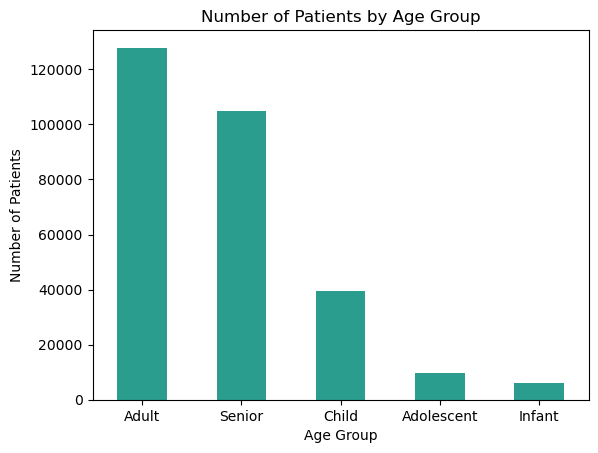

In [62]:
# Visualize the number of patients in each age group
age_counts = df["AgeGroup"].value_counts()
age_counts.plot(kind="bar",color="#2a9d8f")
plt.title("Number of Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

Observation: Most of the records are from adults followed by the seniors then the children while adolescents and infants have the fewest records.

In [63]:
#check the number of patients by gender
gender_counts=df["Gender"].value_counts()
gender_counts

Gender
Female    134298
Male      104393
FEMALE     31210
MALE       18369
Name: count, dtype: int64

In [64]:
#Standardize gender
# Standardize gender labels
df["Gender"] = df["Gender"].str.upper().str.strip()
# Check the result
df["Gender"].value_counts()


Gender
FEMALE    165508
MALE      122762
Name: count, dtype: int64

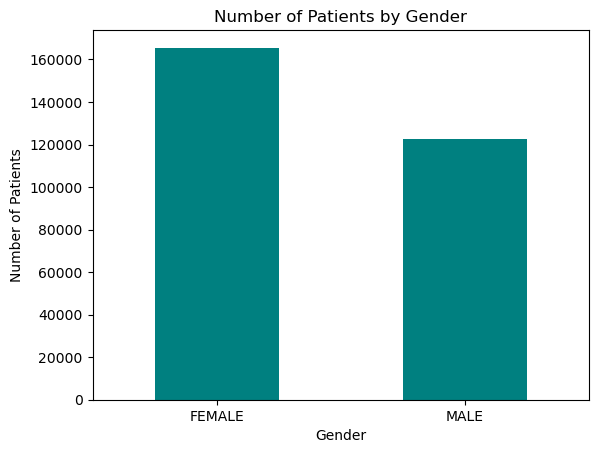

In [65]:
#visualize patients by gender
gender_counts = df["Gender"].value_counts()

gender_counts.plot(kind="bar", color = "teal")

plt.title("Number of Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

#### Return visit feature

In [66]:
# Create a return visit feature
df["ReturnVisit"] = df["PatientNumber"].duplicated(keep="first")

# Check the result
df["ReturnVisit"].value_counts()

ReturnVisit
True     207660
False     80610
Name: count, dtype: int64

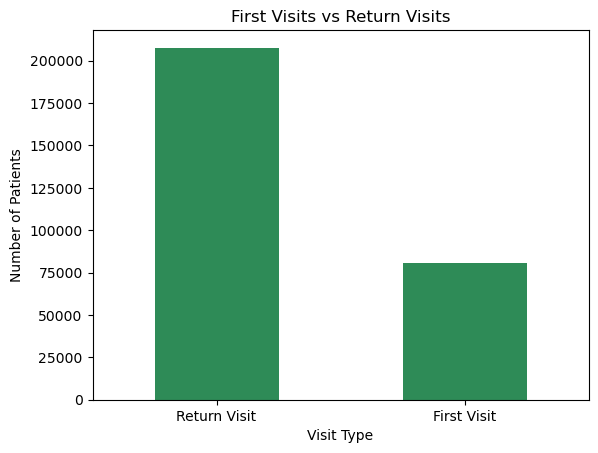

In [67]:
# Visualize first visits and return visits
return_counts = df["ReturnVisit"].value_counts()
return_counts.index = ["Return Visit" if x else "First Visit" for x in return_counts.index]

return_counts.plot(kind="bar", color = "seagreen" )

plt.title("First Visits vs Return Visits")
plt.xlabel("Visit Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

#observation
most of the records are return visits while fewer records are first visits

In [68]:
#RETURN BEHAVIOR BY AGE GROUP
# Check return visits across age groups
age_return = pd.crosstab(df["AgeGroup"], df["ReturnVisit"])

age_return

ReturnVisit,False,True
AgeGroup,,
Adolescent,3587,6273
Adult,36568,91302
Child,13460,26205
Infant,2264,3703
Senior,24731,80177


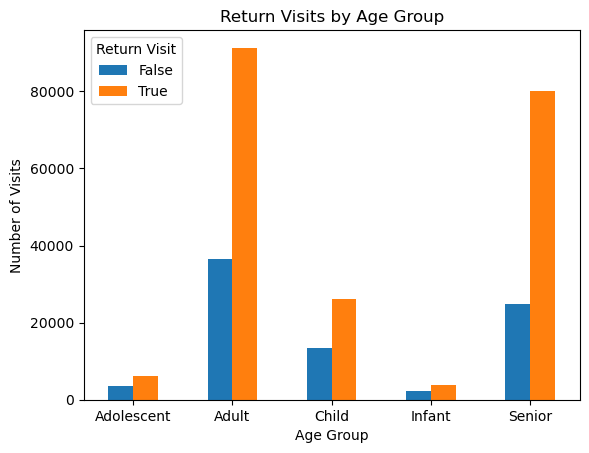

In [69]:
# Visualize return visits by age group
age_return.plot(kind="bar")

plt.title("Return Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Visits")
plt.xticks(rotation=0)
plt.legend(title="Return Visit")
plt.show()

Observation

adults have the highest number of both first and return visits..in all the age groups return visits are higher than the first visit.

In [70]:
# Check return visits across gender
gender_return = pd.crosstab(df["Gender"], df["ReturnVisit"])

gender_return

ReturnVisit,False,True
Gender,,
FEMALE,45733,119775
MALE,34877,87885


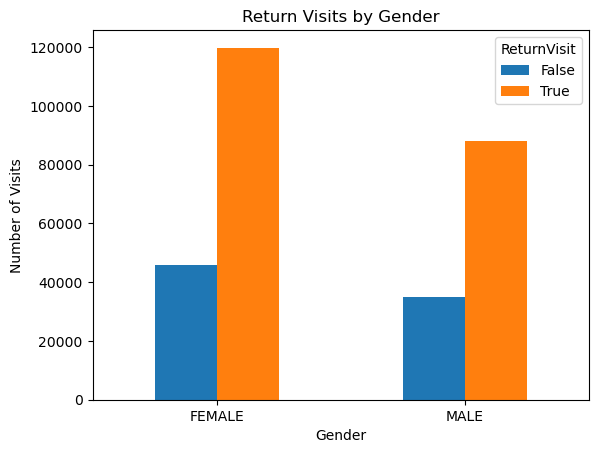

In [71]:
# Visualize return visits by gender
gender_return.plot(kind="bar")

plt.title("Return Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Visits")
plt.xticks(rotation=0)
plt.show()

observations


female patients have more return visits than mal patients



In [72]:
# Calculate return rate for each age group
age_return_rate = pd.crosstab(
    df["AgeGroup"],
    df["ReturnVisit"],
    normalize="index"
) * 100

age_return_rate

ReturnVisit,False,True
AgeGroup,,
Adolescent,36.379310,63.620690
Adult,28.597795,71.402205
Child,33.934199,66.065801
Infant,37.942014,62.057986
Senior,23.573989,76.426011


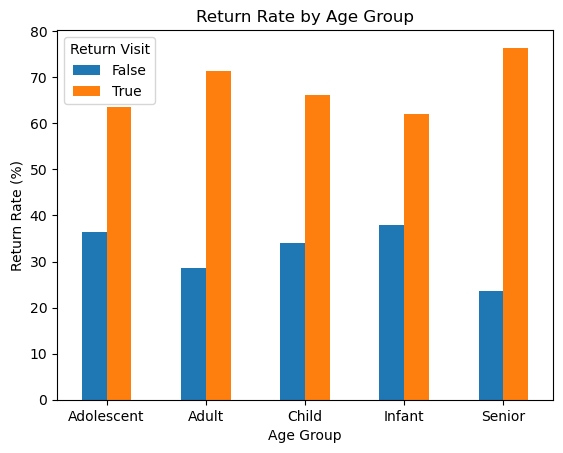

In [73]:
# Visualize return rates by age group
age_return_rate.plot(kind="bar")

plt.title("Return Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Return Visit")
plt.show()

*Observation:* Return rates rise with age. Seniors return most often (76%),
followed by adults (71%). Children (66%), adolescents (64%) and infants (62%)
sit in a similar, lower band.



In [74]:
# Check return visits by consultation type
consult_return = pd.crosstab(
    df["ConsultDescription"],
    df["ReturnVisit"]
)

consult_return

ReturnVisit,False,True
ConsultDescription,,
ANC First Visit,3,2
ANC Revisit,5,18
Admission,5269,20759
Adult Neurology,35,147
Anaesthesia Consult,11,62
...,...,...
Staff Wellness Package,0,1
Surgical OPD,0,2
TB CLINIC,0,16


In [75]:
# Find the consultation types with the most return visits
top_return = consult_return.sort_values(by=True, ascending=False).head(10)

top_return

ReturnVisit,False,True
ConsultDescription,,
General Outpatient Care,11291,37739
Admission,5269,20759
CONSULT,13637,19578
MCH Clinic,3229,16033
RENAL DIALYSIS,55,10960
Chemotherapy,297,10483
ORTHOPEDIC,1417,9599
Comprehensive Care Centre (CCC),1396,6976
Pediatrics,1546,6640


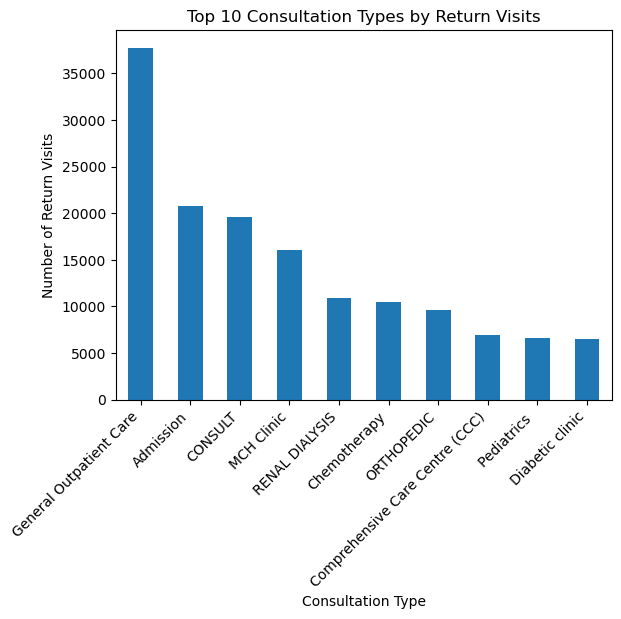

In [76]:
# Visualize the top 10 consultation types by return visits
top_return[True].plot(kind="bar")

plt.title("Top 10 Consultation Types by Return Visits")
plt.xlabel("Consultation Type")
plt.ylabel("Number of Return Visits")
plt.xticks(rotation=45, ha="right")
plt.show()

*Observation:* General Outpatient Care has the highest number of return visits, followed by Admission and CONSULT. This suggests that patients receiving these services are more likely to return for further care.

In [77]:
# Calculate return rate by gender
gender_return_rate = pd.crosstab(
    df["Gender"],
    df["ReturnVisit"],
    normalize="index"
) * 100

gender_return_rate

ReturnVisit,False,True
Gender,,
FEMALE,27.631897,72.368103
MALE,28.410257,71.589743


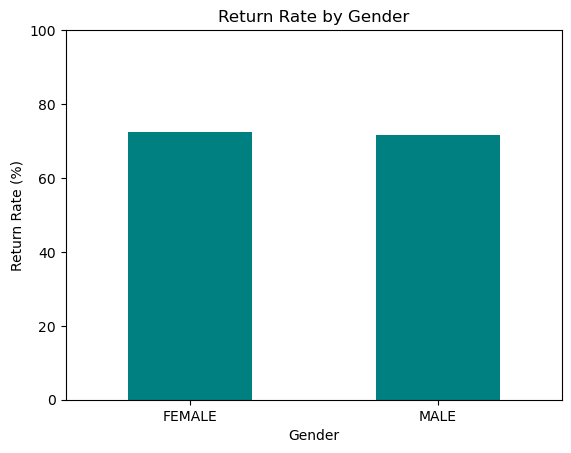

In [78]:
# Visualize return rates by gender
gender_return_rate[True].plot(kind="bar", color = 'teal')

plt.title("Return Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

*Observation:* Female patients have a slightly higher return rate than male patients, but the difference is small. This suggests that gender may not have a strong effect on whether patients return.

In [79]:
# Calculate the total number of patients for each consultation type
consult_total = df["ConsultDescription"].value_counts()

# Keep consultation types with at least 100 patients
common_consults = consult_total[consult_total >= 100].index

# Calculate return rate for each consultation type
consult_return_rate = pd.crosstab(
    df["ConsultDescription"],
    df["ReturnVisit"],
    normalize="index"
) * 100

# Calculate return rate for the more common consultation types
consult_return_rate_filtered = consult_return_rate.loc[common_consults]

# Show the 10 consultation types with the highest return rates
consult_return_rate_filtered.sort_values(
    by=True, ascending=False)

ReturnVisit,False,True
ConsultDescription,,
RENAL DIALYSIS,0.499319,99.500681
Program Patients,0.784077,99.215923
Chemotherapy,2.755102,97.244898
SPECIALITY IMED,2.857143,97.142857
Renal Clinic,3.968254,96.031746
Physiotherapy,4.108496,95.891504
Psychiatry,5.015674,94.984326
Gen Surg OPD,5.177112,94.822888
Spine Clinic,5.853659,94.146341


In [80]:
# Remove consultation types that explicitly describe a return/revisit
consult_return_rate_clean = consult_return_rate_filtered[
    ~consult_return_rate_filtered.index.str.contains(
        "return|revisit", case=False, na=False
    )
]

# Get the 10 consultation types with the highest return rates
top_return_rate = consult_return_rate_clean.sort_values(
    by=True, ascending=False
).head(10)

top_return_rate

ReturnVisit,False,True
ConsultDescription,,
RENAL DIALYSIS,0.499319,99.500681
Program Patients,0.784077,99.215923
Chemotherapy,2.755102,97.244898
SPECIALITY IMED,2.857143,97.142857
Renal Clinic,3.968254,96.031746
Physiotherapy,4.108496,95.891504
Psychiatry,5.015674,94.984326
Gen Surg OPD,5.177112,94.822888
Spine Clinic,5.853659,94.146341


In [81]:
print("consult_return_rate_filtered" in globals())

True


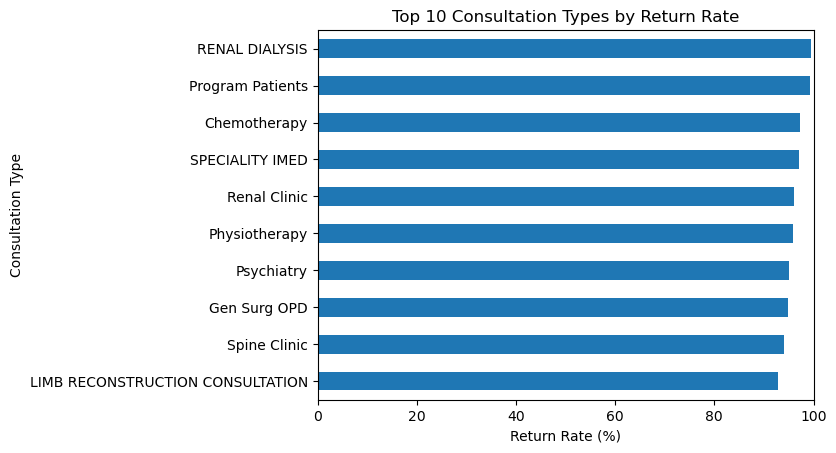

In [82]:
# Visualize the top 10 consultation types by return rate

top_return_rate[True].sort_values().plot(kind="barh")

plt.title("Top 10 Consultation Types by Return Rate")
plt.xlabel("Return Rate (%)")
plt.ylabel("Consultation Type")
plt.xlim(0, 100)
plt.show()

*Observation:* Renal Dialysis has the highest return rate at about 99.5%, followed by Program Patients at about 99.2%. The other consultation types also have high return rates, all above 92%. This shows that patients receiving these services are highly likely to return for further care.

#OVERAL CONCLUSION

The analysis shows that most patients return for further care. Adults have the highest return rate among the age groups while female and male patients have very similar return rates.

Some consultation types especially Renal Dialysis and Program Patients, have very high return rates..Overall the results suggest that patient age and consultation type may influence return behavior while gender appears to have a smaller difference.

#HYPOTHESIS
Null Hypothesis (H₀): There is no significant relationship between patient characteristics and whether a patient returns for another visit.

Alternative Hypothesis (H₁): There is a significant relationship between patient characteristics and whether a patient returns for another visit.

### Feature Engineering for Demand Forecasting

Everything so far has been patient-level (one row per visit). To predict congestion,
we need department-hour level data instead: "how many patients showed up in this
department, in this hour." This section builds that, following the approach used
in the OPD Congestion  Model Selection & Feature Engineering reference notebook.

In [83]:
# Group the ~79 raw consultation labels into 7 broader categories
df["ConsultClean"] = (
    df["ConsultDescription"]
    .fillna("UNKNOWN")
    .str.strip()
    .str.upper()
    .str.replace(r"\.$", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

service_map = {}
for label in ["GENERAL OUTPATIENT CARE", "CONSULT", "GENERAL OUTPATIENT CARE( NEW )",
              "REVISIT", "UNKNOWN", "CONSULTANT CLINIC"]:
    service_map[label] = "Admin / Unspecified"
for label in ["ADMISSION", "DAYCASE", "EMERGENCY"]:
    service_map[label] = "Inpatient / Emergency"
for label in ["RENAL DIALYSIS", "CHEMOTHERAPY", "PHYSIOTHERAPY",
              "HEPATITIS B VACCINE", "OCCUPATIONAL THERAPY"]:
    service_map[label] = "Procedure / Treatment"
for label in ["TELEMEDICINE", "STAFF CLINIC", "STAFF WELLNESS PACKAGE",
              "GENERAL WELLNESS PACKAGE", "PROGRAM PATIENTS", "RVA"]:
    service_map[label] = "Non-Physical / Special Cohort"
for label in ["ECHO", "CANCER SCREENING", "CSSR CANCER SCREENING", "EAR SCREENING"]:
    service_map[label] = "Diagnostic / Screening"
for label in ["MCH CLINIC", "MCH (NEW PATIENT)", "CHILD WELFARE AND IMMUNIZATION (CWC)",
              "DEVELOPMENTAL CLINIC", "FAMILY PLANNING", "ANC REVISIT",
              "ANC FIRST VISIT", "POSTNATAL (PNC)"]:
    service_map[label] = "Maternal & Child Health"

specialty = [
    "ORTHOPEDIC", "COMPREHENSIVE CARE CENTRE (CCC)", "PEDIATRICS", "DENTAL CARE",
    "DIABETIC CLINIC", "GENERAL SURGERY", "GEN SURG OPD", "SURGICAL OPD",
    "ENT RETURN VISIT", "ENT FIRST VISIT", "UROLOGY", "GYNAECOLOGY", "GYNE ONCOLOGY",
    "GYN-ONCOLOGY", "PRIVATE GYN ONCOLOGY", "CARDIOLOGY", "OPHTHALMOLOGY", "EYE CLINIC",
    "ONCOLOGY CONSULTATION", "ONCOLOGY SERVICE", "PLASTICS", "BREAST",
    "NEUROSURGERY OUTPATIENT CLINIC", "ADULT NEUROLOGY", "PAEDS NEUROLOGY",
    "PSYCHIATRY", "PAEDIATRIC PSYCHIATRY", "COUNSELLING PSYCHOLOGY",
    "CLINICAL PSYCHOLOGY CONSULTATION", "COUNSELLING", "NUTRITION CONSULT",
    "SPINE CLINIC", "LIMB RECONSTRUCTION CONSULTATION", "RENAL CLINIC",
    "RENAL CONSULTATION", "NEPHROLOGY CLINIC", "DERMATOLOGY CONSULTATION",
    "ANAESTHESIA CONSULT", "PALLIATIVE REVISIT", "LUNG CLINIC", "HAND CLINIC",
    "TB CLINIC", "HYPERTENSION CLINIC", "PAIN CLINIC", "HEAD AND NECK VISIT",
    "HEAD & NECK RETURN VISIT", "PEADS SURGE", "SPECIALITY IMED",
]
for label in specialty:
    service_map[label] = "Specialty Clinic"

df["ServiceGroup"] = df["ConsultClean"].map(service_map).fillna("Other / Unmapped")
df["ServiceGroup"].value_counts()

ServiceGroup
Admin / Unspecified              105234
Specialty Clinic                  86911
Inpatient / Emergency             34525
Maternal & Child Health           28982
Procedure / Treatment             25719
Non-Physical / Special Cohort      6333
Diagnostic / Screening              566
Name: count, dtype: int64

**Observation**

All consult labels matched the mapping - 0 fell into "Other / Unmapped". Admin/Unspecified
(105,234) and Specialty Clinic (86,911) are the two largest groups, followed by
Inpatient/Emergency, Maternal & Child Health, Procedure/Treatment, Non-Physical/Special
Cohort, and a small Diagnostic/Screening group (566).

### Lab-need features

Each Specialty Clinic label is assigned a likelihood of sending the patient to the lab
(Always/Often/Rarely/Never), plus a typical turnaround time. This matters for congestion
because a patient waiting on same-day lab results occupies space in the building longer
than one who doesn't.

In [84]:
lab_always = ["DIABETIC CLINIC", "COMPREHENSIVE CARE CENTRE (CCC)", "RENAL CLINIC",
    "RENAL CONSULTATION", "NEPHROLOGY CLINIC", "TB CLINIC", "HYPERTENSION CLINIC",
    "ONCOLOGY CONSULTATION", "ONCOLOGY SERVICE", "GYNE ONCOLOGY", "GYN-ONCOLOGY",
    "PRIVATE GYN ONCOLOGY", "BREAST"]
lab_often = ["GENERAL SURGERY", "GEN SURG OPD", "SURGICAL OPD", "ANAESTHESIA CONSULT",
    "CARDIOLOGY", "UROLOGY", "GYNAECOLOGY", "PEDIATRICS", "PEADS SURGE",
    "ADULT NEUROLOGY", "PAEDS NEUROLOGY", "NEUROSURGERY OUTPATIENT CLINIC",
    "LUNG CLINIC", "SPECIALITY IMED", "PALLIATIVE REVISIT"]
lab_rarely = ["ORTHOPEDIC", "SPINE CLINIC", "LIMB RECONSTRUCTION CONSULTATION",
    "HAND CLINIC", "PLASTICS", "DERMATOLOGY CONSULTATION", "OPHTHALMOLOGY",
    "EYE CLINIC", "ENT FIRST VISIT", "ENT RETURN VISIT", "HEAD AND NECK VISIT",
    "HEAD & NECK RETURN VISIT", "PAIN CLINIC", "NUTRITION CONSULT"]
lab_never = ["DENTAL CARE", "PSYCHIATRY", "PAEDIATRIC PSYCHIATRY",
    "COUNSELLING PSYCHOLOGY", "CLINICAL PSYCHOLOGY CONSULTATION", "COUNSELLING"]

lab_map = {}
for x in lab_always: lab_map[x] = "Always"
for x in lab_often:  lab_map[x] = "Often"
for x in lab_rarely: lab_map[x] = "Rarely"
for x in lab_never:  lab_map[x] = "Never"

df["LabNeed"] = df["ConsultClean"].map(lab_map).fillna("Never")
lab_minutes = {"Always": 120, "Often": 120, "Rarely": 90, "Never": 0}
df["LabTatMins"] = df["LabNeed"].map(lab_minutes)
df["LabSameDay"] = df["LabNeed"].isin(["Always", "Often", "Rarely"])

df["LabNeed"].value_counts()

LabNeed
Never     210753
Often      29591
Rarely     27069
Always     20857
Name: count, dtype: int64

**Observation**

Never: 210,753, Often: 29,591, Rarely: 27,069, Always: 20,857 - about 27% of visits
(`LabSameDay`) are estimated to involve a same-day lab step. Note the assumption: anything
not explicitly in the mapping (including "Other / Unmapped" service types) defaults to
"Never" rather than being treated as unknown.

### Calendar features

- `hour` - hour of day (0-23), since OPD traffic isn't evenly spread through the day.
- `day_of_week` - Monday=0 ... Sunday=6, since MCH clinics run on fixed weekdays.
- `is_weekend` - weekends likely behave differently.
- `month` - to capture any seasonal dip/spike.

In [85]:
df["date"] = df["RegistrationDate"].dt.date
df["hour"] = df["RegistrationDate"].dt.hour
df["day_of_week"] = df["RegistrationDate"].dt.dayofweek   # Monday=0 ... Sunday=6
df["is_weekend"] = df["day_of_week"] >= 5
df["month"] = df["RegistrationDate"].dt.month

df[["date", "hour", "day_of_week", "is_weekend", "month"]].sample(5)

,date,hour,day_of_week,is_weekend,month
211567,2026-02-04,8,2,False,2
181883,2025-11-11,14,1,False,11
283643,2026-08-07,18,4,False,8
104551,2025-04-10,8,3,False,4
131835,2025-06-27,8,4,False,6


**Observation**

Data spans 1 June 2024 to 19 August 2026, with all 12 months represented - a good spread
for catching seasonal patterns. `AgeGroup` from earlier in the notebook is left as-is; no
need to rebuild it here.

### Build the modeling table: hourly arrivals per department

This is the key step. So far every row is one visit - there's no "congestion" number yet.
Grouping by date, hour, and department turns each visit into a count: "this many patients
showed up in this department, in this hour." That count becomes what the model predicts.

In [86]:
# Drop rows with an unparseable timestamp - can't place them in a specific hour
ts_df = df.dropna(subset=["RegistrationDate"]).copy()

hourly = (
    ts_df.groupby(["date", "hour", "QueuedTo"])
    .size()
    .reset_index(name="visit_count")
)

hourly["date"] = pd.to_datetime(hourly["date"])
hourly["day_of_week"] = hourly["date"].dt.dayofweek
hourly["is_weekend"] = hourly["day_of_week"] >= 5
hourly["month"] = hourly["date"].dt.month

hourly.head()

,date,hour,QueuedTo,visit_count,day_of_week,is_weekend,month
0,2024-06-01,0,ADMISSION,1,5,True,6
1,2024-06-01,0,GENERAL OPD,2,5,True,6
2,2024-06-01,1,CASUALTY,1,5,True,6
3,2024-06-01,1,GENERAL OPD,2,5,True,6
4,2024-06-01,2,GENERAL OPD,2,5,True,6


In [87]:
hourly["hour"].value_counts()

hour
8     8941
9     8904
10    8018
11    7537
7     6388
12    6370
13    4882
14    4365
6     3837
15    3805
16    3108
5     2430
17    1905
18    1522
0     1414
19    1301
20    1174
4     1134
21    1035
1      995
22     880
2      747
23     709
3      688
Name: count, dtype: int64

**Observation**

82,089 department-hour rows across 41 departments. Typical hour has 1-4 visits (median 2),
busiest single hour hit 59 visits in one department.

### Bonus feature: return-visit share per hour

This notebook already built a `ReturnVisit` flag at the patient level - the reference
notebook doesn't have this. Folding it into the hourly table adds a feature unique to this
project: what share of each hour's patients were returning patients.

In [88]:
return_share = (
    ts_df.groupby(["date", "hour", "QueuedTo"])["ReturnVisit"]
    .mean()
    .reset_index(name="return_visit_share")
)
return_share["date"] = pd.to_datetime(return_share["date"])

hourly = hourly.merge(return_share, on=["date", "hour", "QueuedTo"], how="left")
hourly.head()

,date,hour,QueuedTo,visit_count,day_of_week,is_weekend,month,return_visit_share
0,2024-06-01,0,ADMISSION,1,5,True,6,0.0
1,2024-06-01,0,GENERAL OPD,2,5,True,6,0.0
2,2024-06-01,1,CASUALTY,1,5,True,6,0.0
3,2024-06-01,1,GENERAL OPD,2,5,True,6,0.0
4,2024-06-01,2,GENERAL OPD,2,5,True,6,0.0


**Observation**

Averages 0.72 across all department-hours. For the Renal department specifically it's
0.996 - almost exactly matching the ~99.5% return rate found in the earlier EDA, which is
a good sign this feature captures something real.

### Lag features

The strongest signal for "how busy is a department right now" is usually "how busy was it
a moment ago." Both features below are shifted so the model never sees the value it's
trying to predict.

In [89]:
hourly = hourly.sort_values(["QueuedTo", "date", "hour"]).reset_index(drop=True)

hourly["lag_1h"] = hourly.groupby("QueuedTo")["visit_count"].shift(1)
hourly["rolling_3h_avg"] = (
    hourly.groupby("QueuedTo")["visit_count"]
    .transform(lambda s: s.shift(1).rolling(3).mean())
)

# the first couple of hours per department have no history yet - drop them
model_df = hourly.dropna(subset=["lag_1h", "rolling_3h_avg"]).copy()
model_df.head()

,date,hour,QueuedTo,visit_count,day_of_week,is_weekend,month,return_visit_share,lag_1h,rolling_3h_avg
3,2024-06-02,15,ADMISSION,1,6,True,6,0.0,1.0,1.0
4,2024-06-02,18,ADMISSION,1,6,True,6,0.0,1.0,1.0
5,2024-06-03,7,ADMISSION,1,0,False,6,0.0,1.0,1.0
6,2024-06-03,9,ADMISSION,4,0,False,6,0.0,1.0,1.0
7,2024-06-03,10,ADMISSION,1,0,False,6,0.0,4.0,2.0


**Observation**

Only 121 rows (0.15%) dropped for missing lag history - about 3 rows per department,
right in the expected range.

CHANGES: **Removed sanity check because it should be under modeling**

# Modeling

### Seasonal Naive 

Seasonal Naive Baseline
A Seasonal Naive forecasting model is used as a simple baseline for predicting hospital patient demand. Rather than learning complex relationships from the data, the model assumes that demand at a particular time will be similar to demand at the same time during the previous seasonal period.

For this project, a 7 day seasonal period is appropriate because hospital registrations show a strong weekly pattern, with substantially different demand levels across weekdays and weekends. Therefore, the expected demand for a department at a particular hour can be compared with the demand for the same department and hour one week earlier.

The Seasonal Naive model serves as a benchmark against which more complex forecasting models such as LightGBM can be evaluated. If LightGBM performs better than this simple weekly baseline, its additional complexity provides measurable predictive value.

### Hourly predictions

#### Seaonal naive hourly pred

In [92]:
# a copy for modeling
seasonal_df = modl_df.copy() # for the error here first run the lgbm hrly pred cell [100]

# data is sorted correctly
seasonal_df = seasonal_df.sort_values(["QueuedTo", "timestamp"]).reset_index(drop=True)

# timestamp for the same hour one week earlier
seasonal_df["previous_week_timestamp"] = (seasonal_df["timestamp"] - pd.Timedelta(days=7))

In [93]:
seasonal_df.shape

(797040, 9)

In [94]:
# Create timestamp for the corresponding hour one week earlier
seasonal_df["previous_week_timestamp"] = (seasonal_df["timestamp"] - pd.Timedelta(days=7))

# lookup table for previous week's demand
previous_week = modl_df[["QueuedTo", "timestamp", "visit_count"]].copy()

previous_week = previous_week.rename(columns={"timestamp": "previous_week_timestamp","visit_count": "seasonal_naive"})

# previous week's is merged demand onto the current observation
seasonal_df = seasonal_df.merge(previous_week,on=["QueuedTo", "previous_week_timestamp"],how="left")

In [95]:
# the chronological test period
cutoff = seasonal_df["date"].quantile(0.8)


# train
seasonal_train = seasonal_df[seasonal_df["date"] < cutoff].copy()
# test
seasonal_test = seasonal_df[seasonal_df["date"] >= cutoff].copy()

In [96]:
seasonal_df.head(10)

,timestamp,QueuedTo,visit_count,date,hour,day_of_week,is_weekend,month,previous_week_timestamp,seasonal_naive
0,2024-06-01 00:00:00,ADMISSION,1.0,2024-06-01,0,5,True,6,2024-05-25 00:00:00,NaN
1,2024-06-01 01:00:00,ADMISSION,0.0,2024-06-01,1,5,True,6,2024-05-25 01:00:00,NaN
2,2024-06-01 02:00:00,ADMISSION,0.0,2024-06-01,2,5,True,6,2024-05-25 02:00:00,NaN
3,2024-06-01 03:00:00,ADMISSION,0.0,2024-06-01,3,5,True,6,2024-05-25 03:00:00,NaN
4,2024-06-01 04:00:00,ADMISSION,0.0,2024-06-01,4,5,True,6,2024-05-25 04:00:00,NaN
5,2024-06-01 05:00:00,ADMISSION,0.0,2024-06-01,5,5,True,6,2024-05-25 05:00:00,NaN
6,2024-06-01 06:00:00,ADMISSION,0.0,2024-06-01,6,5,True,6,2024-05-25 06:00:00,NaN
7,2024-06-01 07:00:00,ADMISSION,0.0,2024-06-01,7,5,True,6,2024-05-25 07:00:00,NaN
8,2024-06-01 08:00:00,ADMISSION,0.0,2024-06-01,8,5,True,6,2024-05-25 08:00:00,NaN
9,2024-06-01 09:00:00,ADMISSION,1.0,2024-06-01,9,5,True,6,2024-05-25 09:00:00,NaN


In [97]:
# Select 'queuedto' and 'consultdescription' columns
modl_df = df[["hour", "QueuedTo"]]

# Display the first few rows of the subset
modl_df.head()
combination_counts = df[["hour", "QueuedTo"]].value_counts().reset_index(name="count")
display(combination_counts.head(15))

,hour,QueuedTo,count
0,9,GENERAL OPD,13725
1,8,GENERAL OPD,12495
2,10,GENERAL OPD,10090
3,11,GENERAL OPD,8787
4,7,GENERAL OPD,7732
5,12,GENERAL OPD,6515
6,8,SPECIALITY CLINIC,5770
7,9,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),5374
8,9,MCH,5212
9,8,ONCOLOGY,5134


In [98]:
combination_counts = modl_df[["hour", "QueuedTo"]].value_counts().reset_index(name="count")
display(combination_counts.head(15))

,hour,QueuedTo,count
0,9,GENERAL OPD,13725
1,8,GENERAL OPD,12495
2,10,GENERAL OPD,10090
3,11,GENERAL OPD,8787
4,7,GENERAL OPD,7732
5,12,GENERAL OPD,6515
6,8,SPECIALITY CLINIC,5770
7,9,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),5374
8,9,MCH,5212
9,8,ONCOLOGY,5134


In [99]:
# 1. Filter specifically for 'GENERAL OPD' (adjust string if your department name differs slightly)
gen_opd_df = df[df["QueuedTo"] == "GENERAL OPD"]

# 2. Filter for hours between 18:00 (6 PM) and 07:00 (7 AM)
# This includes 18 through 23, and 0 through 6
night_visits = gen_opd_df[
    (gen_opd_df["hour"] >= 18) | (gen_opd_df["hour"] < 7)
]

# 3. Get the total count of patients
total_night_patients = len(night_visits)
print(f"Total General OPD patients visiting between 18:00 and 07:00: {total_night_patients:,}")

# Optional: View a breakdown by exact hour to see the distribution
hourly_breakdown = night_visits["hour"].value_counts().sort_index()
print("\nVisits breakdown by hour:")
print(hourly_breakdown)

Total General OPD patients visiting between 18:00 and 07:00: 0

Visits breakdown by hour:
Series([], Name: count, dtype: int64)


In [100]:
# calculate the mar and rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

evaluation = seasonal_test.dropna(subset=["seasonal_naive"]).copy()

baseline_mae = mean_absolute_error(evaluation["visit_count"], evaluation["seasonal_naive"])

baseline_rmse = np.sqrt(mean_squared_error(evaluation["visit_count"], evaluation["seasonal_naive"]))

print(f"Seasonal Naive MAE: {baseline_mae:.2f}")
print(f"Seasonal Naive RMSE: {baseline_rmse:.2f}")
print(f"Test observations: {len(evaluation):,}")
print(f"Test period: "f"{evaluation['timestamp'].min()} "f"to "f"{evaluation['timestamp'].max()}")

Seasonal Naive MAE: 0.30
Seasonal Naive RMSE: 1.16
Test observations: 159,408
Test period: 2026-03-11 00:00:00 to 2026-08-19 23:00:00


In [101]:
# basrline summary
print("Test observations:", len(seasonal_test))
print("Departments:", seasonal_test["QueuedTo"].nunique())
print("Test period:", seasonal_test["date"].min(), "to", seasonal_test["date"].max())

Test observations: 159408
Departments: 41
Test period: 2026-03-11 00:00:00 to 2026-08-19 00:00:00


In [102]:
# department level performance
department_baseline = (seasonal_test.groupby("QueuedTo").apply(
    lambda x: pd.Series({"MAE": mean_absolute_error(x["visit_count"], x["seasonal_naive"]),
                         "RMSE": np.sqrt(mean_squared_error(x["visit_count"], 
                          x["seasonal_naive"])), "Actual_Avg_Demand": x["visit_count"].mean()
                           })).reset_index())

department_baseline.sort_values("Actual_Avg_Demand", ascending=False).head(10)

,QueuedTo,MAE,RMSE,Actual_Avg_Demand
12,GENERAL OPD,2.350566,3.949169,4.597737
0,ADMISSION,1.396091,2.376692,1.611368
17,MCH,1.076646,2.247770,1.550412
19,MEB SPECIALITY CLINIC,0.858796,2.353364,1.412294
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),0.834105,2.070578,1.376286
39,SPECIALITY CLINIC,0.597479,1.627708,0.804270
27,ONCOLOGY,0.504372,1.703075,0.747685
37,RENAL,0.742027,2.022698,0.603652
7,DENTAL,0.467593,1.282600,0.528807
30,PAEDS BKKH,0.359311,1.107053,0.483025


### LightGBM hourly pred

In [103]:
# copy of the hourly demand data
modl_df = hourly.copy()

# date set to datetime
modl_df["date"] = pd.to_datetime(modl_df["date"])

# complete hourly timestamps
start_date = modl_df["date"].min()
end_date = modl_df["date"].max()

all_hours = pd.date_range(start=start_date, end=end_date + pd.Timedelta(hours=23), freq="h")

departments = modl_df["QueuedTo"].dropna().unique()

# combination of timestamp and department
complete_grid = pd.MultiIndex.from_product([all_hours, departments],names=["timestamp", "QueuedTo"]).to_frame(index=False)

# timestamp extraction from existing data
modl_df["timestamp"] = (modl_df["date"] + pd.to_timedelta(modl_df["hour"], unit="h"))

# keeping the required columns
modl_df = modl_df[["timestamp", "QueuedTo", "visit_count"]]

# merge onto the complete grid
modl_df = complete_grid.merge(modl_df, on=["timestamp", "QueuedTo"], how="left")

# hours with no recorded visits hence zero demand
modl_df["visit_count"] = modl_df["visit_count"].fillna(0)

# recreate time features
modl_df["date"] = modl_df["timestamp"].dt.date
modl_df["date"] = pd.to_datetime(modl_df["date"])

modl_df["hour"] = modl_df["timestamp"].dt.hour
modl_df["day_of_week"] = modl_df["timestamp"].dt.dayofweek
modl_df["is_weekend"] = modl_df["day_of_week"] >= 5
modl_df["month"] = modl_df["timestamp"].dt.month

# sorting for time series features
modl_df = modl_df.sort_values(["QueuedTo", "timestamp"]).reset_index(drop=True)

modl_df.head()

,timestamp,QueuedTo,visit_count,date,hour,day_of_week,is_weekend,month
0,2024-06-01 00:00:00,ADMISSION,1.0,2024-06-01,0,5,True,6
1,2024-06-01 01:00:00,ADMISSION,0.0,2024-06-01,1,5,True,6
2,2024-06-01 02:00:00,ADMISSION,0.0,2024-06-01,2,5,True,6
3,2024-06-01 03:00:00,ADMISSION,0.0,2024-06-01,3,5,True,6
4,2024-06-01 04:00:00,ADMISSION,0.0,2024-06-01,4,5,True,6


In [104]:
modl_df.shape

(797040, 8)

In [105]:
# lag features
# previous hour
modl_df["lag_1h"] = (modl_df.groupby("QueuedTo")["visit_count"].shift(1))

# previous 3 hour average
modl_df["rolling_3h_avg"] = (modl_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(3).mean()))

modl_df.head()


,timestamp,QueuedTo,visit_count,date,hour,day_of_week,is_weekend,month,lag_1h,rolling_3h_avg
0,2024-06-01 00:00:00,ADMISSION,1.0,2024-06-01,0,5,True,6,NaN,NaN
1,2024-06-01 01:00:00,ADMISSION,0.0,2024-06-01,1,5,True,6,1.0,NaN
2,2024-06-01 02:00:00,ADMISSION,0.0,2024-06-01,2,5,True,6,0.0,NaN
3,2024-06-01 03:00:00,ADMISSION,0.0,2024-06-01,3,5,True,6,0.0,0.333333
4,2024-06-01 04:00:00,ADMISSION,0.0,2024-06-01,4,5,True,6,0.0,0.000000


In [106]:
# seasonal naive benchmark
# Date corresponding to the same hour one week earlier
modl_df["previous_week_timestamp"] = (modl_df["timestamp"] - pd.Timedelta(days=7))

previous_week = modl_df[
    ["timestamp", "QueuedTo", "visit_count"]].rename(
    columns={"timestamp": "previous_week_timestamp", "visit_count": "seasonal_naive"})

modl_df = modl_df.merge(previous_week, on=["previous_week_timestamp", "QueuedTo"], how="left")


In [107]:
# dropping rows with insufficient history
model_df = modl_df.dropna(subset=["lag_1h", "rolling_3h_avg"]).copy()

print("Rows available for modeling:", len(model_df))
print("Departments:", model_df["QueuedTo"].nunique())
print("Date range:", model_df["date"].min(), "to", model_df["date"].max())

Rows available for modeling: 796917
Departments: 41
Date range: 2024-06-01 00:00:00 to 2026-08-19 00:00:00


In [108]:
# chronological train - test split
cutoff = model_df["date"].quantile(0.8)

train = model_df[model_df["date"] < cutoff].copy()

test = model_df[model_df["date"] >= cutoff].copy()

print("Training period:", train["date"].min(), "to", train["date"].max())
print("Testing period:", test["date"].min(), "to", test["date"].max())

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

Training period: 2024-06-01 00:00:00 to 2026-03-10 00:00:00
Testing period: 2026-03-11 00:00:00 to 2026-08-19 00:00:00

Training rows: 637509
Testing rows: 159408


In [109]:
# lgbm features
features = ["hour", "day_of_week", "is_weekend", "month", "lag_1h", "rolling_3h_avg", "QueuedTo"]

target = "visit_count"

X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

In [110]:
# converting department to categorical
X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

In [111]:
import lightgbm as lgb

from sklearn.metrics import (mean_absolute_error, mean_squared_error)

In [112]:
model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 637509, number of used features: 7
[LightGBM] [Info] Start training from score 0.353772


LGBMRegressor(learning_rate=0.05, n_estimators=500, objective='regression',
              random_state=42)

In [113]:
# prediction generation
predictions = model.predict(X_test)

predictions = np.maximum(predictions, 0)

predictions[:10]

array([2.09284767, 1.12526051, 0.75101751, 0.50703489, 0.50527669,
       0.5192248 , 0.6669268 , 1.22188979, 3.00271276, 4.79312985])

In [114]:
# model evalutaion
lgbm_mae = mean_absolute_error(y_test, predictions)

lgbm_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"LightGBM MAE:  {lgbm_mae:.2f}")
print(f"LightGBM RMSE: {lgbm_rmse:.2f}")

LightGBM MAE:  0.24
LightGBM RMSE: 0.86


In [115]:
# lgbm - seasonal naive comparsion
evaluation = test[["timestamp", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

evaluation["lightgbm_prediction"] = predictions

evaluation = evaluation.dropna(subset=["seasonal_naive"]).reset_index(drop=True)

evaluation.head()

,timestamp,QueuedTo,visit_count,seasonal_naive,lightgbm_prediction
0,2026-03-11 00:00:00,ADMISSION,3.0,2.0,2.092848
1,2026-03-11 01:00:00,ADMISSION,2.0,1.0,1.125261
2,2026-03-11 02:00:00,ADMISSION,0.0,1.0,0.751018
3,2026-03-11 03:00:00,ADMISSION,0.0,0.0,0.507035
4,2026-03-11 04:00:00,ADMISSION,0.0,0.0,0.505277


In [116]:
evaluation = test[["timestamp", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

evaluation["lightgbm_prediction"] = predictions

evaluation = evaluation.dropna(subset=["seasonal_naive"])

baseline_mae = mean_absolute_error(evaluation["visit_count"], evaluation["seasonal_naive"])

baseline_rmse = np.sqrt(mean_squared_error(evaluation["visit_count"], evaluation["seasonal_naive"]))

lgbm_mae_eval = mean_absolute_error(evaluation["visit_count"], evaluation["lightgbm_prediction"])

lgbm_rmse_eval = np.sqrt(mean_squared_error(evaluation["visit_count"], evaluation["lightgbm_prediction"]))

print("Seasonal Naive")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")

print("\nLightGBM")
print(f"MAE:  {lgbm_mae_eval:.2f}")
print(f"RMSE: {lgbm_rmse_eval:.2f}")

Seasonal Naive
MAE:  0.30
RMSE: 1.16

LightGBM
MAE:  0.24
RMSE: 0.86


In [117]:
# percentage improvement
mae_improvement = ((baseline_mae - lgbm_mae_eval) / baseline_mae) * 100

rmse_improvement = ((baseline_rmse - lgbm_rmse_eval) / baseline_rmse) * 100

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement:  18.43%
RMSE improvement: 26.38%


In [118]:
# department level performance
department_results = []

for department, group in evaluation.groupby("QueuedTo"):

    actual = group["visit_count"]
    predicted = group["lightgbm_prediction"]
    baseline = group["seasonal_naive"]

    department_results.append({"Department": department, "Observations": len(group), 
    "Average Demand": actual.mean(),"LightGBM MAE": mean_absolute_error(actual, predicted),
    "Seasonal Naive MAE": mean_absolute_error(actual, baseline)})

department_results = pd.DataFrame(department_results)

department_results["Improvement (%)"] = ((department_results["Seasonal Naive MAE"]
                                          - department_results["LightGBM MAE"]) 
                                         / department_results["Seasonal Naive MAE"]) * 100

department_results = department_results.sort_values("Average Demand", ascending=False)

department_results.head(15)

,Department,Observations,Average Demand,LightGBM MAE,Seasonal Naive MAE,Improvement (%)
12,GENERAL OPD,3888,4.597737,1.757425,2.350566,25.233939
0,ADMISSION,3888,1.611368,1.079742,1.396091,22.659630
17,MCH,3888,1.550412,0.796930,1.076646,25.980298
19,MEB SPECIALITY CLINIC,3888,1.412294,0.613346,0.858796,28.580737
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),3888,1.376286,0.625145,0.834105,25.052025
39,SPECIALITY CLINIC,3888,0.804270,0.569980,0.597479,4.602581
27,ONCOLOGY,3888,0.747685,0.467160,0.504372,7.377998
37,RENAL,3888,0.603652,0.695345,0.742027,6.291081
7,DENTAL,3888,0.528807,0.380450,0.467593,18.636463
30,PAEDS BKKH,3888,0.483025,0.338678,0.359311,5.742237


In [119]:
# feature importance
feature_importance = pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})

feature_importance = feature_importance.sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,rolling_3h_avg,3295
0,hour,2975
4,lag_1h,2857
6,QueuedTo,2111
1,day_of_week,1912
3,month,1850
2,is_weekend,0


#### Hourly forecast

In [120]:
print("Hourly dataframe:")
print(hourly.shape)
print(hourly.columns.tolist())

Hourly dataframe:
(82089, 10)
['date', 'hour', 'QueuedTo', 'visit_count', 'day_of_week', 'is_weekend', 'month', 'return_visit_share', 'lag_1h', 'rolling_3h_avg']


In [121]:
print("\nDepartments:")
print(hourly["QueuedTo"].nunique())


Departments:
41


In [122]:
print("\nLast date:")
print(hourly["date"].max())


Last date:
2026-08-19 00:00:00


In [123]:
print("\nHourly model features:")
print(X_train.columns.tolist())


Hourly model features:
['hour', 'day_of_week', 'is_weekend', 'month', 'lag_1h', 'rolling_3h_avg', 'QueuedTo']


In [124]:
# Hourly forecast model

# forecast horizon
forecast_days = 7

# last date available in the historical hourly dataset
last_date = hourly["date"].max()

# future hourly timestamps
future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_days * 24, freq="h")

# department categories used by the trained model
queuedto_categories = model.booster_.pandas_categorical[0]

# Historical data used to initialize recursive features
history = hourly[
    ["date", "hour", "QueuedTo", "visit_count"]
].copy()

# Ensure correct data types
history["date"] = pd.to_datetime(history["date"])

# Store forecasts here
future_forecasts = []

# -------------------------------------------------------
# Recursive forecasting
# -------------------------------------------------------

for timestamp in future_dates:

    current_date = timestamp.normalize()
    current_hour = timestamp.hour
    day_of_week = timestamp.dayofweek
    month = timestamp.month
    is_weekend = int(day_of_week >= 5)

    for department in queuedto_categories:

        # Previous hour's actual/predicted demand
        previous_hour = history[
            (history["QueuedTo"] == department) &
            (history["date"] == timestamp - pd.Timedelta(hours=1))
        ]

        if len(previous_hour) > 0:
            lag_1h = previous_hour["visit_count"].iloc[-1]
        else:
            lag_1h = 0

        # Previous 3 hours for rolling mean
        previous_3h = history[
            (history["QueuedTo"] == department) &
            (history["date"] < timestamp) &
            (history["date"] >= timestamp - pd.Timedelta(hours=3))
        ].sort_values("date")

        if len(previous_3h) > 0:
            rolling_3h_avg = previous_3h["visit_count"].mean()
        else:
            rolling_3h_avg = 0

        # Create model input
        X_future = pd.DataFrame({
            "hour": [current_hour],
            "day_of_week": [day_of_week],
            "is_weekend": [is_weekend],
            "month": [month],
            "lag_1h": [lag_1h],
            "rolling_3h_avg": [rolling_3h_avg],
            "QueuedTo": pd.Categorical(
                [department],
                categories=queuedto_categories
            )
        })

        # Predict
        prediction = model.predict(X_future)[0]

        # Demand cannot be negative
        prediction = max(0, prediction)

        # Save forecast
        future_forecasts.append({
            "date": timestamp,
            "hour": current_hour,
            "QueuedTo": department,
            "predicted_demand": prediction
        })

        # Add prediction to history so it can be used
        # as a lag/rolling value for subsequent hours
        history = pd.concat([
            history,
            pd.DataFrame({
                "date": [timestamp],
                "hour": [current_hour],
                "QueuedTo": [department],
                "visit_count": [prediction]
            })
        ], ignore_index=True)


# Convert to dataframe
hourly_future_forecast = pd.DataFrame(future_forecasts)

# Sort output
hourly_future_forecast = hourly_future_forecast.sort_values(
    ["date", "QueuedTo", "hour"]
).reset_index(drop=True)

print("Hourly future forecast shape:")
print(hourly_future_forecast.shape)

print("\nForecast date range:")
print(
    hourly_future_forecast["date"].min(),
    "to",
    hourly_future_forecast["date"].max()
)

print("\nNumber of departments:")
print(hourly_future_forecast["QueuedTo"].nunique())

hourly_future_forecast.head(20)

Hourly future forecast shape:
(6888, 4)

Forecast date range:
2026-08-19 01:00:00 to 2026-08-26 00:00:00

Number of departments:
41


,date,hour,QueuedTo,predicted_demand
0,2026-08-19 01:00:00,1,ADMISSION,0.261545
1,2026-08-19 01:00:00,1,ANAESTHESIA,0.000489
2,2026-08-19 01:00:00,1,Audiology,0.006173
3,2026-08-19 01:00:00,1,CARDIOLOGY,0.000489
4,2026-08-19 01:00:00,1,CASUALTY,0.029474
5,2026-08-19 01:00:00,1,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),1.768831
6,2026-08-19 01:00:00,1,DAYCASE,0.254450
7,2026-08-19 01:00:00,1,DENTAL,0.977934
8,2026-08-19 01:00:00,1,DIABETIC CLINIC,0.000489
9,2026-08-19 01:00:00,1,EYE CLINIC,0.295982


In [125]:
print("Minimum forecast timestamp:")
print(hourly_future_forecast["date"].min())

print("\nMaximum forecast timestamp:")
print(hourly_future_forecast["date"].max())

print("\nUnique timestamps:")
print(hourly_future_forecast["date"].nunique())

Minimum forecast timestamp:
2026-08-19 01:00:00

Maximum forecast timestamp:
2026-08-26 00:00:00

Unique timestamps:
168


In [126]:
department_counts = (
    hourly_future_forecast
    .groupby("date")["QueuedTo"]
    .nunique()
)

print(department_counts.value_counts())
print(department_counts.head())

QueuedTo
41    168
Name: count, dtype: int64
date
2026-08-19 01:00:00    41
2026-08-19 02:00:00    41
2026-08-19 03:00:00    41
2026-08-19 04:00:00    41
2026-08-19 05:00:00    41
Name: QueuedTo, dtype: int64


In [127]:
hospital_hourly_forecast = (
    hourly_future_forecast
    .groupby("date")["predicted_demand"]
    .sum()
    .reset_index()
)

hospital_hourly_forecast.head(24)

,date,predicted_demand
0,2026-08-19 01:00:00,30.054368
1,2026-08-19 02:00:00,28.254175
2,2026-08-19 03:00:00,29.728463
3,2026-08-19 04:00:00,28.216350
4,2026-08-19 05:00:00,32.713884
5,2026-08-19 06:00:00,44.899144
6,2026-08-19 07:00:00,73.302608
7,2026-08-19 08:00:00,119.309234
8,2026-08-19 09:00:00,104.037608
9,2026-08-19 10:00:00,68.610201


In [128]:
hourly_future_forecast.to_csv(
    "hourly_future_forecast.csv",
    index=False
)

print("Saved:", "hourly_future_forecast.csv")
print("Rows:", len(hourly_future_forecast))

Saved: hourly_future_forecast.csv
Rows: 6888


In [129]:
hourly_to_daily_check = (
    hourly_future_forecast
    .assign(date_only=hourly_future_forecast["date"].dt.date)
    .groupby(["date_only", "QueuedTo"])["predicted_demand"]
    .sum()
    .reset_index()
    .rename(columns={"date_only": "date"})
)

hourly_to_daily_check.head(20)

,date,QueuedTo,predicted_demand
0,2026-08-19,ADMISSION,33.948597
1,2026-08-19,ANAESTHESIA,4.199951
2,2026-08-19,Audiology,4.118691
3,2026-08-19,CARDIOLOGY,2.979412
4,2026-08-19,CASUALTY,5.449112
5,2026-08-19,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),46.745076
6,2026-08-19,DAYCASE,12.246428
7,2026-08-19,DENTAL,24.649006
8,2026-08-19,DIABETIC CLINIC,2.979412
9,2026-08-19,EYE CLINIC,12.438379


In [130]:
# -------------------------------------------------------
# HOURLY FUTURE FORECAST — COVERAGE CHECK
# -------------------------------------------------------

# Load saved forecast
hourly_future_forecast = pd.read_csv(
    "hourly_future_forecast.csv",
    parse_dates=["date"]
)

# Expected values
expected_departments = 41
expected_hours = 168
expected_rows = expected_departments * expected_hours

print("Expected rows:", expected_rows)
print("Actual rows:  ", len(hourly_future_forecast))

# -------------------------------------------------------
# 1. Number of departments
# -------------------------------------------------------

print("\nNumber of departments:")
print(hourly_future_forecast["QueuedTo"].nunique())

# -------------------------------------------------------
# 2. Number of unique timestamps
# -------------------------------------------------------

print("\nNumber of unique timestamps:")
print(hourly_future_forecast["date"].nunique())

# -------------------------------------------------------
# 3. Date/time coverage
# -------------------------------------------------------

print("\nForecast date range:")
print(hourly_future_forecast["date"].min())
print("to")
print(hourly_future_forecast["date"].max())

# -------------------------------------------------------
# 4. Rows per department
# -------------------------------------------------------

rows_per_department = (
    hourly_future_forecast
    .groupby("QueuedTo")
    .size()
)

print("\nRows per department:")
print(rows_per_department)

# Check whether every department has exactly 168 rows
print("\nDepartments with incorrect number of rows:")

print(
    rows_per_department[
        rows_per_department != expected_hours
    ]
)

# -------------------------------------------------------
# 5. Check for duplicate department-hour combinations
# -------------------------------------------------------

duplicates = hourly_future_forecast.duplicated(
    subset=["date", "QueuedTo"],
    keep=False
)

print("\nDuplicate department-hour combinations:")
print(duplicates.sum())

if duplicates.sum() > 0:
    print("\nDuplicates found:")
    print(
        hourly_future_forecast.loc[duplicates]
        .sort_values(["date", "QueuedTo"])
    )

# -------------------------------------------------------
# 6. Check for missing department-hour combinations
# -------------------------------------------------------

expected_dates = pd.date_range(
    start=hourly_future_forecast["date"].min(),
    periods=expected_hours,
    freq="h"
)

expected_departments_list = (
    hourly_future_forecast["QueuedTo"]
    .unique()
)

expected_grid = pd.MultiIndex.from_product(
    [
        expected_dates,
        expected_departments_list
    ],
    names=["date", "QueuedTo"]
)

actual_grid = pd.MultiIndex.from_frame(
    hourly_future_forecast[
        ["date", "QueuedTo"]
    ]
)

missing = expected_grid.difference(actual_grid)

print("\nMissing department-hour combinations:")
print(len(missing))

if len(missing) > 0:
    print("\nMissing combinations:")
    print(missing)

# -------------------------------------------------------
# 7. Final verdict
# -------------------------------------------------------

coverage_ok = (
    len(hourly_future_forecast) == expected_rows
    and hourly_future_forecast["QueuedTo"].nunique() == expected_departments
    and hourly_future_forecast["date"].nunique() == expected_hours
    and duplicates.sum() == 0
    and len(missing) == 0
)

print("\n--------------------------------")
print("HOURLY COVERAGE CHECK")
print("--------------------------------")

if coverage_ok:
    print("PASS — Complete hourly forecast coverage.")
else:
    print("CHECK REQUIRED — Coverage is incomplete or duplicated.")

Expected rows: 6888
Actual rows:   6888

Number of departments:
41

Number of unique timestamps:
168

Forecast date range:
2026-08-19 01:00:00
to
2026-08-26 00:00:00

Rows per department:
QueuedTo
ADMISSION                              168
ANAESTHESIA                            168
Audiology                              168
CARDIOLOGY                             168
CASUALTY                               168
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    168
DAYCASE                                168
DENTAL                                 168
DIABETIC CLINIC                        168
EYE CLINIC                             168
FAMILY CLINIC                          168
FAMILY MEDICINE                        168
GENERAL OPD                            168
Gen Surg OPD                           168
Gynae OPD                              168
HTS                                    168
MATERNITY NURSERY                      168
MCH                                    168
MEB PHYSIOTHERAPY            

In [131]:
# -------------------------------------------------------
# HOURLY FUTURE FORECAST — SANITY CHECK
# -------------------------------------------------------

# 1. Check for missing predictions
print("Missing predictions:")
print(hourly_future_forecast["predicted_demand"].isna().sum())

# 2. Check for negative predictions
print("\nNegative predictions:")
print((hourly_future_forecast["predicted_demand"] < 0).sum())

# 3. Basic statistics
print("\nPrediction statistics:")
print(
    hourly_future_forecast["predicted_demand"]
    .describe()
)

# 4. Find unusually large predictions
# Use the 99th percentile as a diagnostic threshold
threshold = hourly_future_forecast["predicted_demand"].quantile(0.99)

print("\n99th percentile threshold:")
print(threshold)

high_predictions = hourly_future_forecast[
    hourly_future_forecast["predicted_demand"] > threshold
].sort_values(
    "predicted_demand",
    ascending=False
)

print("\nHighest predictions:")
print(high_predictions.head(20))

# 5. Maximum prediction
max_prediction = hourly_future_forecast.loc[
    hourly_future_forecast["predicted_demand"].idxmax()
]

print("\nMaximum predicted demand:")
print(max_prediction)

# 6. Check whether any prediction is exactly zero
zero_predictions = (
    hourly_future_forecast["predicted_demand"] == 0
).sum()

print("\nPredictions equal to zero:")
print(zero_predictions)

# 7. Final sanity verdict
sanity_ok = (
    hourly_future_forecast["predicted_demand"].isna().sum() == 0
    and
    (hourly_future_forecast["predicted_demand"] < 0).sum() == 0
)

print("\n--------------------------------")
print("HOURLY SANITY CHECK")
print("--------------------------------")

if sanity_ok:
    print("PASS — No missing or negative predictions.")
else:
    print("CHECK REQUIRED — Invalid predictions detected.")

Missing predictions:
0

Negative predictions:
0

Prediction statistics:
count    6888.000000
mean        0.579138
std         1.731588
min         0.000000
25%         0.098951
50%         0.151879
75%         0.291066
max        26.655489
Name: predicted_demand, dtype: float64

99th percentile threshold:
8.811075728506086

Highest predictions:
                    date  hour               QueuedTo  predicted_demand
340  2026-08-19 09:00:00     9           GENERAL OPD          26.655489
299  2026-08-19 08:00:00     8           GENERAL OPD          24.369554
5260 2026-08-24 09:00:00     9           GENERAL OPD          23.787215
6244 2026-08-25 09:00:00     9           GENERAL OPD          22.214658
5219 2026-08-24 08:00:00     8           GENERAL OPD          21.791041
6203 2026-08-25 08:00:00     8           GENERAL OPD          21.455858
1324 2026-08-20 09:00:00     9           GENERAL OPD          21.100727
258  2026-08-19 07:00:00     7           GENERAL OPD          20.805600
1283 

### Daily predictions

#### Seasonal naive daily pred

In [132]:
# daily departmental demand dataset
daily = (hourly.groupby(["date", "QueuedTo"])["visit_count"].sum().reset_index())

daily.head()

,date,QueuedTo,visit_count
0,2024-06-01,ADMISSION,3
1,2024-06-01,CASUALTY,7
2,2024-06-01,GENERAL OPD,62
3,2024-06-01,Gen Surg OPD,3
4,2024-06-01,MCH,6


In [133]:
daily.shape

(13168, 3)

In [134]:
# complete daily grid

daily_dates = pd.date_range(daily["date"].min(),daily["date"].max(),freq="D")

departments = daily["QueuedTo"].unique()

complete_daily = pd.MultiIndex.from_product([daily_dates, departments],names=["date", "QueuedTo"]).to_frame(index=False)

complete_daily = complete_daily.merge(daily,on=["date", "QueuedTo"],how="left")

complete_daily["visit_count"] = (complete_daily["visit_count"].fillna(0))

complete_daily.head()

,date,QueuedTo,visit_count
0,2024-06-01,ADMISSION,3.0
1,2024-06-01,CASUALTY,7.0
2,2024-06-01,GENERAL OPD,62.0
3,2024-06-01,Gen Surg OPD,3.0
4,2024-06-01,MCH,6.0


A daily grid is created as a prodct of available dates and departments so as the model is able to calculate that a departments's demand was n exactly 7 days ago

In [135]:
daily.shape

(13168, 3)

In [136]:
# 7 day seasonal naive forecast

complete_daily = complete_daily.sort_values(["QueuedTo", "date"]).reset_index(drop=True)

complete_daily["seasonal_naive"] = (complete_daily.groupby("QueuedTo")["visit_count"].shift(7))

complete_daily.head(15)

,date,QueuedTo,visit_count,seasonal_naive
0,2024-06-01,ADMISSION,3.0,NaN
1,2024-06-02,ADMISSION,2.0,NaN
2,2024-06-03,ADMISSION,32.0,NaN
3,2024-06-04,ADMISSION,31.0,NaN
4,2024-06-05,ADMISSION,18.0,NaN
5,2024-06-06,ADMISSION,20.0,NaN
6,2024-06-07,ADMISSION,16.0,NaN
7,2024-06-08,ADMISSION,0.0,3.0
8,2024-06-09,ADMISSION,3.0,2.0
9,2024-06-10,ADMISSION,26.0,32.0


The model essentially predics based on the acutall demand from 7 days earlier hence the best prediction for a department that day is what was experience on the same day the previous week 

The Nan values are as a result of data unavilablity since thast the prerion in which data collection starts

In [137]:
# daily evaluation data

daily_evaluation = test[["date", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

daily_evaluation = daily_evaluation.dropna(subset=["seasonal_naive"]).reset_index(drop=True)

print("Evaluation rows:", len(daily_evaluation))
daily_evaluation.head()

Evaluation rows: 159408


,date,QueuedTo,visit_count,seasonal_naive
0,2026-03-11,ADMISSION,3.0,2.0
1,2026-03-11,ADMISSION,2.0,1.0
2,2026-03-11,ADMISSION,0.0,1.0
3,2026-03-11,ADMISSION,0.0,0.0
4,2026-03-11,ADMISSION,0.0,0.0


The resulting dataset contains only test period observations for which both an actual value and a corresponding seasonal naive prediction are available. This ensures that the actual and predicted values are aligned correctly before calculating forecasting performance metrics such as MAE and RMSE.

The resulting evaluation dataset contains **6,642 department-day observations**.

In [138]:
# evaluate the daily baseline

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

daily_naive_mae = mean_absolute_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"])

daily_naive_rmse = np.sqrt(mean_squared_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"]))

print("Daily Seasonal Naive MAE:", daily_naive_mae)
print("Daily Seasonal Naive RMSE:", daily_naive_rmse)

Daily Seasonal Naive MAE: 0.2966162300511894
Daily Seasonal Naive RMSE: 1.1647266314747189




The model achieved a **Mean Absolute Error (MAE) of 3.05 patients per department-day**. This means that, on average, the baseline forecast differed from the actual daily demand by approximately 3 patient visits.

The model achieved a **Root Mean Squared Error (RMSE) of 8.09 patients per department-day**. Because RMSE gives greater weight to larger errors, the higher RMSE compared with MAE indicates that some forecasts contained relatively large ee value.

#### LightGBM Daily predictions

In [139]:
# daily lgbm modeling dataset

daily_model_df = complete_daily.copy()

daily_model_df["date"] = pd.to_datetime(daily_model_df["date"])

# sort chronologically within each department
daily_model_df = daily_model_df.sort_values(["QueuedTo", "date"]).reset_index(drop=True)

print("Rows available for modeling:", len(daily_model_df))
print("Departments:", daily_model_df["QueuedTo"].nunique())
print("Date range:", daily_model_df["date"].min(), "to", daily_model_df["date"].max())

daily_model_df.head()

Rows available for modeling: 33210
Departments: 41
Date range: 2024-06-01 00:00:00 to 2026-08-19 00:00:00


,date,QueuedTo,visit_count,seasonal_naive
0,2024-06-01,ADMISSION,3.0,NaN
1,2024-06-02,ADMISSION,2.0,NaN
2,2024-06-03,ADMISSION,32.0,NaN
3,2024-06-04,ADMISSION,31.0,NaN
4,2024-06-05,ADMISSION,18.0,NaN


In [140]:
daily_model_df.shape

(33210, 4)

In [141]:
# Daily lag features

# previous day's demand for the same department
daily_model_df["lag_1d"] = (daily_model_df.groupby("QueuedTo")["visit_count"].shift(1))

# demand from the same department  7 days earlier
daily_model_df["lag_7d"] = (daily_model_df.groupby("QueuedTo")["visit_count"].shift(7))

# average demand over the previous 7 days
daily_model_df["rolling_7d_avg"] = (daily_model_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(7).mean()))

daily_model_df[["date", "QueuedTo", "visit_count", "lag_1d", 'lag_7d', "rolling_7d_avg"]].head(15)

,date,QueuedTo,visit_count,lag_1d,lag_7d,rolling_7d_avg
0,2024-06-01,ADMISSION,3.0,NaN,NaN,NaN
1,2024-06-02,ADMISSION,2.0,3.0,NaN,NaN
2,2024-06-03,ADMISSION,32.0,2.0,NaN,NaN
3,2024-06-04,ADMISSION,31.0,32.0,NaN,NaN
4,2024-06-05,ADMISSION,18.0,31.0,NaN,NaN
5,2024-06-06,ADMISSION,20.0,18.0,NaN,NaN
6,2024-06-07,ADMISSION,16.0,20.0,NaN,NaN
7,2024-06-08,ADMISSION,0.0,16.0,3.0,17.428571
8,2024-06-09,ADMISSION,3.0,0.0,2.0,17.000000
9,2024-06-10,ADMISSION,26.0,3.0,32.0,17.142857


Department vists fro the previous day are listed under `lag_1d` where as `rolling_7d_avg` answers what was a departments's average daily demand over the previous seven days

In [142]:
# daily calendar features

daily_model_df["day_of_week"] = daily_model_df["date"].dt.dayofweek
daily_model_df["is_weekend"] = daily_model_df["day_of_week"].isin([5, 6]).astype(int)
daily_model_df["month"] = daily_model_df["date"].dt.month

daily_model_df[["date", "QueuedTo", "day_of_week", "is_weekend", "month"]].head(15)

,date,QueuedTo,day_of_week,is_weekend,month
0,2024-06-01,ADMISSION,5,1,6
1,2024-06-02,ADMISSION,6,1,6
2,2024-06-03,ADMISSION,0,0,6
3,2024-06-04,ADMISSION,1,0,6
4,2024-06-05,ADMISSION,2,0,6
5,2024-06-06,ADMISSION,3,0,6
6,2024-06-07,ADMISSION,4,0,6
7,2024-06-08,ADMISSION,5,1,6
8,2024-06-09,ADMISSION,6,1,6
9,2024-06-10,ADMISSION,0,0,6


Calendar-based features were created from the `date` column to help the LightGBM model identify recurring patterns in daily patient demand.

These features allow the model to learn whether patient demand varies according to the day of the week, weekends, or month.

In [143]:
# features for the daily LightGBM model

features = ["day_of_week", "is_weekend", "month", "lag_1d", "lag_7d", "rolling_7d_avg", "QueuedTo"]

target = "visit_count"

# rows where the lag/rolling features are not yet available are dropped
daily_lgbm_df = daily_model_df.dropna(subset=["lag_1d", "lag_7d", "rolling_7d_avg"]).copy()

print("Rows available for LightGBM:", len(daily_lgbm_df))
print("Features:", features)
print("Target:", target)

daily_lgbm_df.head(10)

Rows available for LightGBM: 32923
Features: ['day_of_week', 'is_weekend', 'month', 'lag_1d', 'lag_7d', 'rolling_7d_avg', 'QueuedTo']
Target: visit_count


,date,QueuedTo,visit_count,seasonal_naive,lag_1d,lag_7d,rolling_7d_avg,day_of_week,is_weekend,month
7,2024-06-08,ADMISSION,0.0,3.0,16.0,3.0,17.428571,5,1,6
8,2024-06-09,ADMISSION,3.0,2.0,0.0,2.0,17.000000,6,1,6
9,2024-06-10,ADMISSION,26.0,32.0,3.0,32.0,17.142857,0,0,6
10,2024-06-11,ADMISSION,15.0,31.0,26.0,31.0,16.285714,1,0,6
11,2024-06-12,ADMISSION,25.0,18.0,15.0,18.0,14.000000,2,0,6
12,2024-06-13,ADMISSION,23.0,20.0,25.0,20.0,15.000000,3,0,6
13,2024-06-14,ADMISSION,29.0,16.0,23.0,16.0,15.428571,4,0,6
14,2024-06-15,ADMISSION,15.0,0.0,29.0,0.0,17.285714,5,1,6
15,2024-06-16,ADMISSION,10.0,3.0,15.0,3.0,19.428571,6,1,6
16,2024-06-17,ADMISSION,18.0,26.0,10.0,26.0,20.428571,0,0,6



The dataset now contains historical demand, lag features, rolling demand, and calendar features. `lag_7d` matches `seasonal_naive` because both represent demand from the same department exactly seven days earlier. The first seven days were excluded because insufficient historical data was available to calculate the lag and rolling features.

In [144]:
# chronological train-test split

cutoff = daily_lgbm_df["date"].quantile(0.8)

train = daily_lgbm_df[daily_lgbm_df["date"] < cutoff].copy()

test = daily_lgbm_df[daily_lgbm_df["date"] >= cutoff].copy()

print("Cutoff date:", cutoff)
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Cutoff date: 2026-03-12 00:00:00
Training rows: 26322
Testing rows: 6601

Training period:
2024-06-08 00:00:00 to 2026-03-11 00:00:00

Testing period:
2026-03-12 00:00:00 to 2026-08-19 00:00:00


In [145]:
# Prepare features and target

X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

# Treat department as a categorical feature
X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

X_train.head()

Training features: (26322, 7)
Testing features: (6601, 7)


,day_of_week,is_weekend,month,lag_1d,lag_7d,rolling_7d_avg,QueuedTo
7,5,1,6,16.0,3.0,17.428571,ADMISSION
8,6,1,6,0.0,2.0,17.000000,ADMISSION
9,0,0,6,3.0,32.0,17.142857,ADMISSION
10,1,0,6,26.0,31.0,16.285714,ADMISSION
11,2,0,6,15.0,18.0,14.000000,ADMISSION


In [146]:
# train model

model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 26322, number of used features: 7
[LightGBM] [Info] Start training from score 8.495821


LGBMRegressor(learning_rate=0.05, n_estimators=500, objective='regression',
              random_state=42)

In [147]:
print("Training QueuedTo dtype:")
print(daily_model_df["QueuedTo"].dtype)

print("\nTraining QueuedTo categories:")
if hasattr(daily_model_df["QueuedTo"].dtype, "categories"):
    print(daily_model_df["QueuedTo"].cat.categories.tolist())

Training QueuedTo dtype:
object

Training QueuedTo categories:


In [148]:
# generate daily predictions

daily_predictions = model.predict(X_test)

# prevent negative patient count predictions
daily_predictions = np.maximum(daily_predictions, 0)

print("Number of predictions:", len(daily_predictions))
print("First 10 predictions:")
print(daily_predictions[:10])

Number of predictions: 6601
First 10 predictions:
[51.20533672 55.7509046  19.84145044 16.15956206 55.121424   50.89695241
 48.66872351 48.03114353 57.16522716 19.80454244]


In [149]:
# evaluation dataset

daily_evaluation = test[["date", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

daily_evaluation["lightgbm_prediction"] = daily_predictions

daily_evaluation = daily_evaluation.dropna(subset=["seasonal_naive"]).reset_index(drop=True)

daily_evaluation.sample(10)

,date,QueuedTo,visit_count,seasonal_naive,lightgbm_prediction
5594,2026-07-10,PHYSIOTHERAPY,17.0,13.0,11.741999
4450,2026-06-23,ONCOLOGY,30.0,48.0,30.625847
357,2026-04-16,Audiology,0.0,0.0,1.097755
3386,2026-03-17,MORGUE,0.0,0.0,0.089468
6496,2026-05-07,TELEMEDICINE,0.0,7.0,4.142869
5223,2026-05-22,PATHOLOGY,0.0,0.0,0.028900
1649,2026-04-20,FAMILY CLINIC,0.0,0.0,0.101634
5802,2026-03-18,PSYCHOLOGY,1.0,0.0,0.922020
6205,2026-06-07,RESPIRATORY CENTER,0.0,0.0,0.000000
3683,2026-07-31,NEURO SURGERY CONSULTATION,0.0,0.0,0.028239


In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# LGBM performance
lgbm_mae = mean_absolute_error(daily_evaluation["visit_count"],daily_evaluation["lightgbm_prediction"])

lgbm_rmse = np.sqrt(mean_squared_error(daily_evaluation["visit_count"], daily_evaluation["lightgbm_prediction"]))

# Seasonal naive performance
baseline_mae = mean_absolute_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"])

baseline_rmse = np.sqrt(mean_squared_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"]))

print(f"LightGBM MAE: {lgbm_mae:.2f}")
print(f"LightGBM RMSE: {lgbm_rmse:.2f}")

print(f"\nSeasonal Naive MAE: {baseline_mae:.2f}")
print(f"Seasonal Naive RMSE: {baseline_rmse:.2f}")

LightGBM MAE: 2.48
LightGBM RMSE: 6.28

Seasonal Naive MAE: 3.05
Seasonal Naive RMSE: 8.10


In [151]:
# department level performance

department_results = (daily_evaluation.groupby("QueuedTo").apply(lambda df: pd.Series({"Average_Demand": df["visit_count"].mean(), 
                    "LightGBM_MAE": mean_absolute_error(df["visit_count"], df["lightgbm_prediction"]),
                    "LightGBM_RMSE": np.sqrt(mean_squared_error(df["visit_count"], df["lightgbm_prediction"])),
                    "Seasonal_Naive_MAE": mean_absolute_error(df["visit_count"], df["seasonal_naive"]), 
                    "Seasonal_Naive_RMSE": np.sqrt(mean_squared_error(df["visit_count"], df["seasonal_naive"]))})).reset_index())

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Seasonal_Naive_MAE,Seasonal_Naive_RMSE
0,ADMISSION,38.546584,8.219738,12.321636,10.503106,14.718687
1,ANAESTHESIA,0.043478,0.071790,0.412169,0.043478,0.424410
2,Audiology,1.627329,1.294865,1.930073,1.639752,2.630448
3,CARDIOLOGY,0.093168,0.143856,0.331661,0.142857,0.394055
4,CASUALTY,4.813665,2.715468,4.369637,3.714286,5.656854
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,11.667739,9.757764,15.914172
6,DAYCASE,8.105590,3.268890,4.860217,4.347826,6.702183
7,DENTAL,12.596273,3.595252,5.556025,4.813665,7.119652
8,DIABETIC CLINIC,0.068323,0.122031,0.275690,0.136646,0.386094
9,EYE CLINIC,7.987578,2.586685,4.000576,3.372671,5.093535


In [152]:
# calculate percentage improvement over Seasonal Naive

department_results["MAE_Improvement_%"] = ((department_results["Seasonal_Naive_MAE"] - department_results["LightGBM_MAE"])
    / department_results["Seasonal_Naive_MAE"]) * 100

department_results["RMSE_Improvement_%"] = ((department_results["Seasonal_Naive_RMSE"] - department_results["LightGBM_RMSE"])
    / department_results["Seasonal_Naive_RMSE"]) * 100

department_results = department_results.sort_values("MAE_Improvement_%", ascending=False)

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Seasonal_Naive_MAE,Seasonal_Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%
4,CASUALTY,4.813665,2.715468,4.369637,3.714286,5.656854,26.891249,22.755009
7,DENTAL,12.596273,3.595252,5.556025,4.813665,7.119652,25.311535,21.962126
6,DAYCASE,8.105590,3.268890,4.860217,4.347826,6.702183,24.815537,27.483070
17,MCH,37.111801,8.101632,11.687192,10.732919,15.910073,24.516043,26.542184
19,MEB SPECIALITY CLINIC,33.863354,8.727314,14.740074,11.472050,19.823288,23.925417,25.642639
9,EYE CLINIC,7.987578,2.586685,4.000576,3.372671,5.093535,23.304554,21.457770
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,11.667739,9.757764,15.914172,21.937606,26.683339
26,OHNS,9.689441,3.220770,4.929198,4.124224,6.349060,21.906030,22.363334
0,ADMISSION,38.546584,8.219738,12.321636,10.503106,14.718687,21.739927,16.285766
27,ONCOLOGY,17.875776,5.289128,8.161771,6.726708,10.832147,21.371227,24.652322


In [153]:
# calculate wape by department

department_results["LightGBM_WAPE_%"] = (department_results["LightGBM_MAE"] / department_results["Average_Demand"]) * 100

department_results["Seasonal_Naive_WAPE_%"] = (department_results["Seasonal_Naive_MAE"] / department_results["Average_Demand"]) * 100

department_results[["QueuedTo", "Average_Demand", "LightGBM_MAE","LightGBM_WAPE_%","Seasonal_Naive_MAE",
                    "Seasonal_Naive_WAPE_%"]].sort_values("Average_Demand",ascending=False).head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_WAPE_%,Seasonal_Naive_MAE,Seasonal_Naive_WAPE_%
12,GENERAL OPD,110.031056,17.325010,15.745564,21.316770,19.373412
0,ADMISSION,38.546584,8.219738,21.324167,10.503106,27.247825
17,MCH,37.111801,8.101632,21.830339,10.732919,28.920502
19,MEB SPECIALITY CLINIC,33.863354,8.727314,25.772149,11.472050,33.877476
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,23.090947,9.757764,29.580117
39,SPECIALITY CLINIC,19.341615,6.185505,31.980294,7.596273,39.274245
27,ONCOLOGY,17.875776,5.289128,29.588242,6.726708,37.630299
37,RENAL,14.490683,2.842182,19.613857,3.316770,22.888984
7,DENTAL,12.596273,3.595252,28.542190,4.813665,38.214990
30,PAEDS BKKH,11.416149,4.560349,39.946470,4.031056,35.310120


In [154]:
# Calculate true WAPE by department

wape_results = (
    daily_evaluation
    .groupby("QueuedTo")
    .apply(lambda df: pd.Series({
        "LightGBM_WAPE_%": (
            np.abs(
                df["visit_count"] - df["lightgbm_prediction"]
            ).sum()
            / df["visit_count"].sum()
            * 100
            if df["visit_count"].sum() != 0 else np.nan
        ),

        "Seasonal_Naive_WAPE_%": (
            np.abs(
                df["visit_count"] - df["seasonal_naive"]
            ).sum()
            / df["visit_count"].sum()
            * 100
            if df["visit_count"].sum() != 0 else np.nan
        )
    }))
    .reset_index()
)

wape_results.head(15)

,QueuedTo,LightGBM_WAPE_%,Seasonal_Naive_WAPE_%
0,ADMISSION,21.324167,27.247825
1,ANAESTHESIA,165.115856,100.000000
2,Audiology,79.569978,100.763359
3,CARDIOLOGY,154.405096,153.333333
4,CASUALTY,56.411656,77.161290
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),23.090947,29.580117
6,DAYCASE,40.328831,53.639847
7,DENTAL,28.542190,38.214990
8,DIABETIC CLINIC,178.608280,200.000000
9,EYE CLINIC,32.383847,42.223950


In [155]:
department_results = department_results.drop(
    columns=["LightGBM_WAPE_%", "Seasonal_Naive_WAPE_%"],
    errors="ignore"
)

department_results = department_results.merge(
    wape_results,
    on="QueuedTo",
    how="left"
)

department_results.sort_values(
    "Average_Demand",
    ascending=False
).head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Seasonal_Naive_MAE,Seasonal_Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%,LightGBM_WAPE_%,Seasonal_Naive_WAPE_%
13,GENERAL OPD,110.031056,17.325010,23.547056,21.316770,30.004348,18.725915,21.521185,15.745564,19.373412
8,ADMISSION,38.546584,8.219738,12.321636,10.503106,14.718687,21.739927,16.285766,21.324167,27.247825
3,MCH,37.111801,8.101632,11.687192,10.732919,15.910073,24.516043,26.542184,21.830339,28.920502
4,MEB SPECIALITY CLINIC,33.863354,8.727314,14.740074,11.472050,19.823288,23.925417,25.642639,25.772149,33.877476
6,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,11.667739,9.757764,15.914172,21.937606,26.683339,23.090947,29.580117
14,SPECIALITY CLINIC,19.341615,6.185505,9.785049,7.596273,12.986615,18.571842,24.652811,31.980294,39.274245
9,ONCOLOGY,17.875776,5.289128,8.161771,6.726708,10.832147,21.371227,24.652322,29.588242,37.630299
16,RENAL,14.490683,2.842182,4.240875,3.316770,5.080715,14.308749,16.529952,19.613857,22.888984
1,DENTAL,12.596273,3.595252,5.556025,4.813665,7.119652,25.311535,21.962126,28.542190,38.214990
29,PAEDS BKKH,11.416149,4.560349,6.652774,4.031056,6.676649,-13.130372,0.357583,39.946470,35.310120


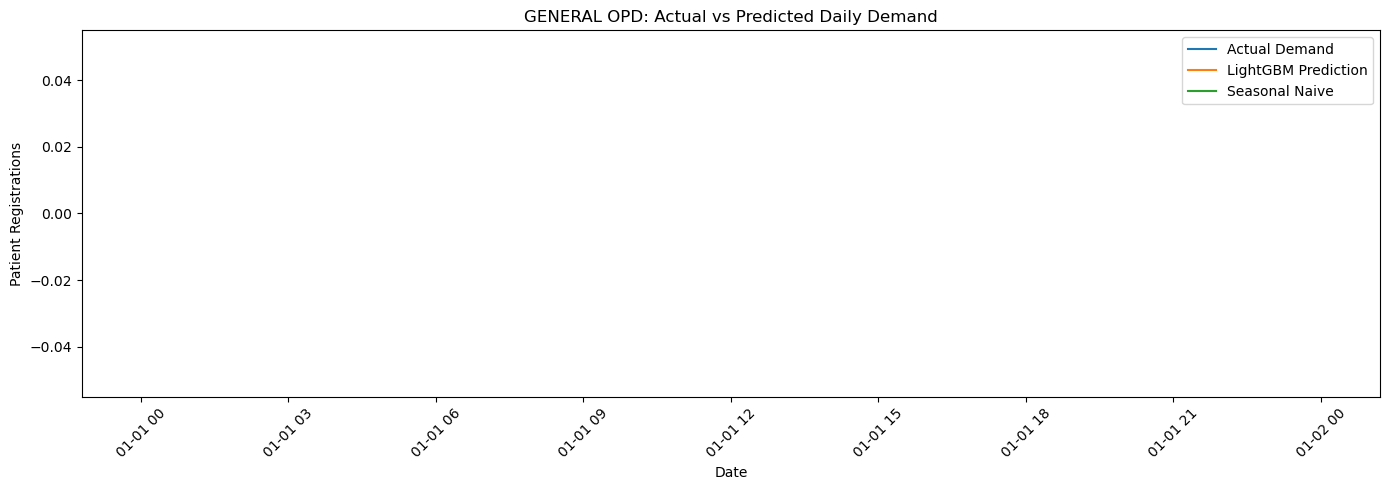

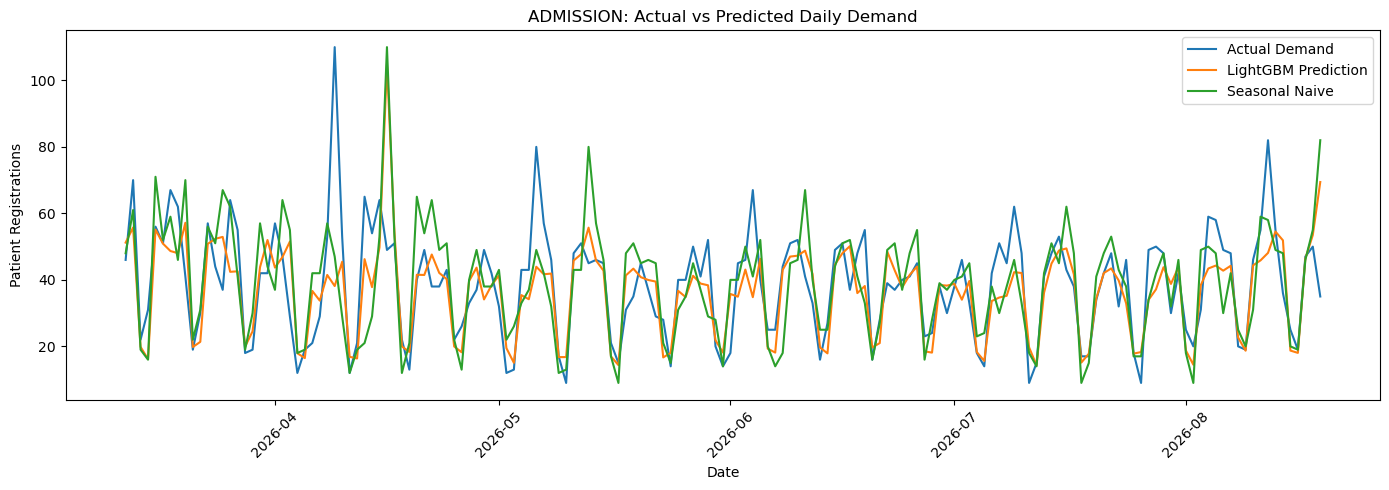

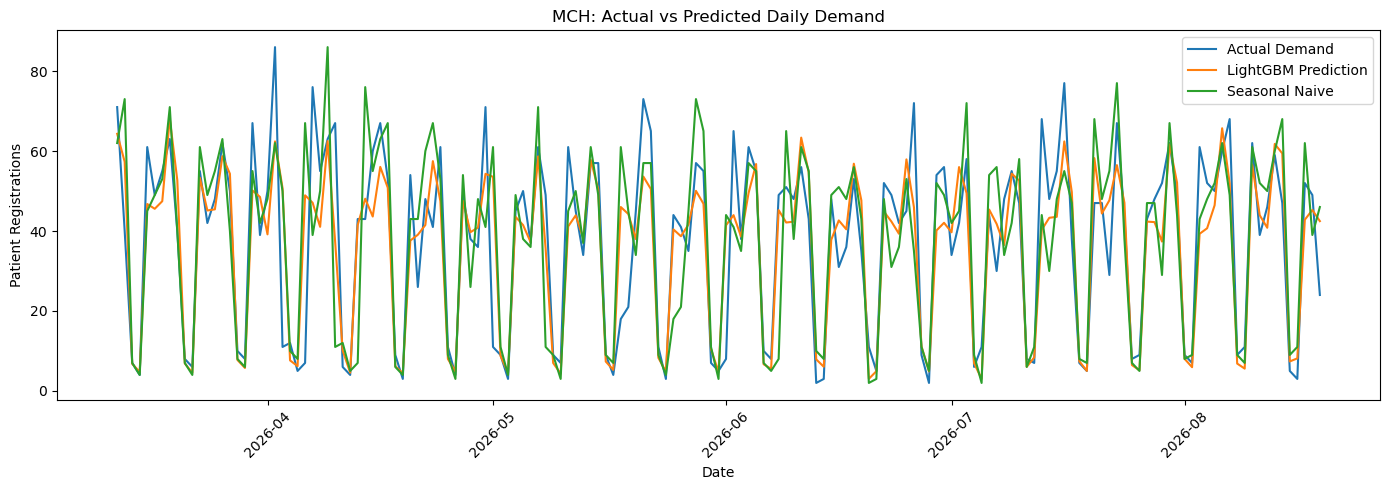

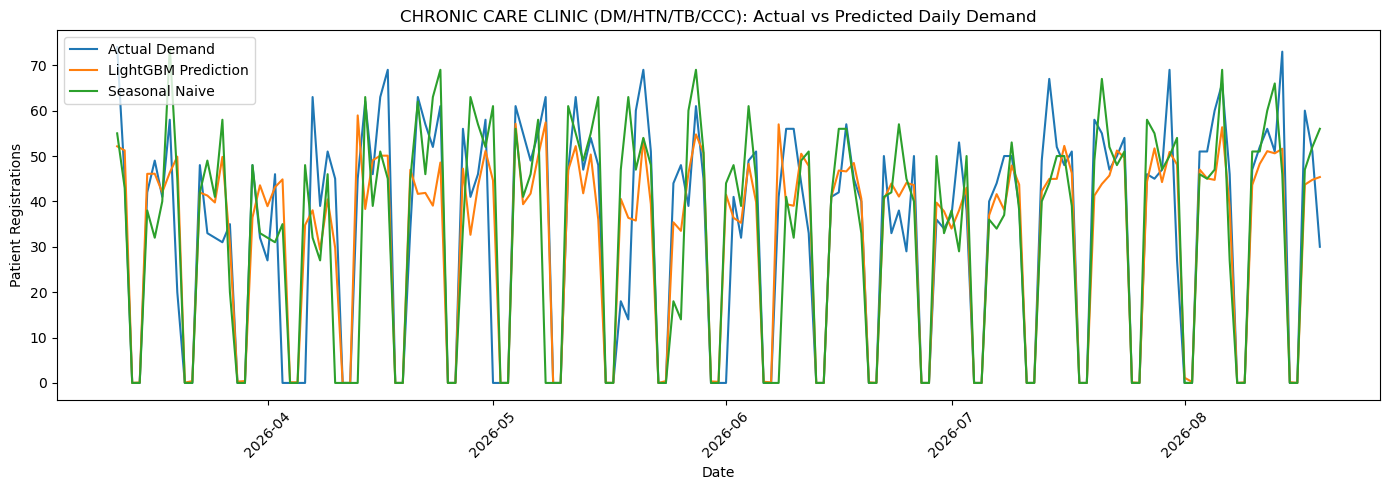

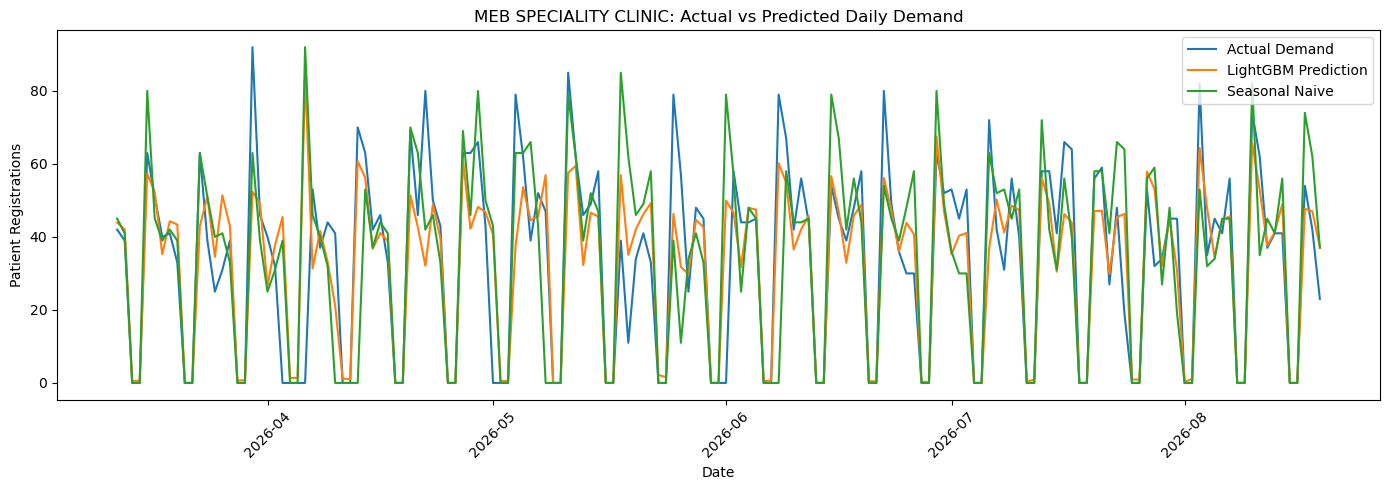

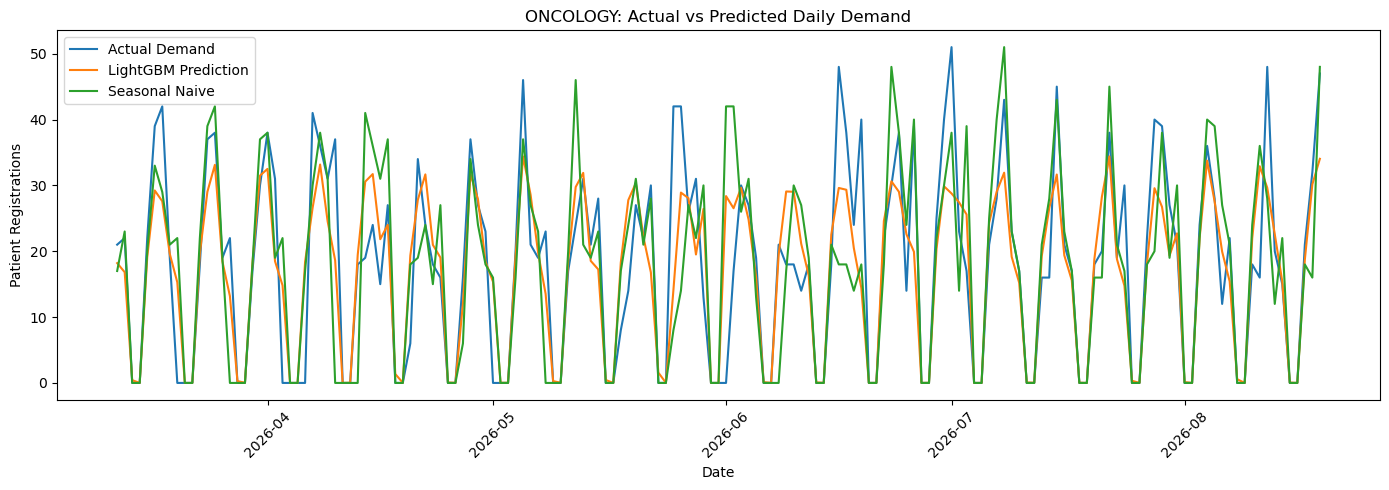

In [156]:
import matplotlib.pyplot as plt

departments_to_plot = [
    "GENERAL OPD",
    "ADMISSION",
    "MCH",
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)",
    "MEB SPECIALITY CLINIC",
    "ONCOLOGY"
]

for department in departments_to_plot:

    dept_data = daily_evaluation[
        daily_evaluation["QueuedTo"] == department
    ].sort_values("date")

    plt.figure(figsize=(14, 5))

    plt.plot(
        dept_data["date"],
        dept_data["visit_count"],
        label="Actual Demand"
    )

    plt.plot(
        dept_data["date"],
        dept_data["lightgbm_prediction"],
        label="LightGBM Prediction"
    )

    plt.plot(
        dept_data["date"],
        dept_data["seasonal_naive"],
        label="Seasonal Naive"
    )

    plt.title(f"{department}: Actual vs Predicted Daily Demand")
    plt.xlabel("Date")
    plt.ylabel("Patient Registrations")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [157]:
# Zero-demand distribution by department and weekday

zero_by_weekday = (
    daily_evaluation
    .assign(
        day_of_week=daily_evaluation["date"].dt.day_name(),
        is_zero=daily_evaluation["visit_count"] == 0
    )
    .groupby(["QueuedTo", "day_of_week"])
    .agg(
        total_days=("visit_count", "size"),
        zero_days=("is_zero", "sum")
    )
    .reset_index()
)

zero_by_weekday["zero_percentage"] = (
    zero_by_weekday["zero_days"] /
    zero_by_weekday["total_days"] * 100
)

zero_by_weekday.head(20)

,QueuedTo,day_of_week,total_days,zero_days,zero_percentage
0,ADMISSION,Friday,23,0,0.000000
1,ADMISSION,Monday,23,0,0.000000
2,ADMISSION,Saturday,23,0,0.000000
3,ADMISSION,Sunday,23,0,0.000000
4,ADMISSION,Thursday,23,0,0.000000
5,ADMISSION,Tuesday,23,0,0.000000
6,ADMISSION,Wednesday,23,0,0.000000
7,ANAESTHESIA,Friday,23,23,100.000000
8,ANAESTHESIA,Monday,23,22,95.652174
9,ANAESTHESIA,Saturday,23,23,100.000000


In [158]:
zero_by_weekday.sort_values(
    "zero_percentage",
    ascending=False
).head(20)

,QueuedTo,day_of_week,total_days,zero_days,zero_percentage
283,TELEMEDICINE,Sunday,23,23,100.0
276,SPECIALITY CLINIC,Sunday,23,23,100.0
13,ANAESTHESIA,Wednesday,23,23,100.0
10,ANAESTHESIA,Sunday,23,23,100.0
9,ANAESTHESIA,Saturday,23,23,100.0
7,ANAESTHESIA,Friday,23,23,100.0
272,RESPIRATORY CENTER,Wednesday,23,23,100.0
11,ANAESTHESIA,Thursday,23,23,100.0
224,PATHOLOGY,Friday,23,23,100.0
237,PEDIATRIC NEUROLOGY,Wednesday,23,23,100.0


In [159]:
# Zero-demand analysis for high-volume departments

high_volume_departments = [
    "GENERAL OPD",
    "ADMISSION",
    "MCH",
    "MEB SPECIALITY CLINIC",
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)",
    "SPECIALITY CLINIC",
    "ONCOLOGY",
    "RENAL"
]

high_volume_zero = zero_by_weekday[
    zero_by_weekday["QueuedTo"].isin(high_volume_departments)
].sort_values(
    ["QueuedTo", "day_of_week"]
)

high_volume_zero

,QueuedTo,day_of_week,total_days,zero_days,zero_percentage
0,ADMISSION,Friday,23,0,0.000000
1,ADMISSION,Monday,23,0,0.000000
2,ADMISSION,Saturday,23,0,0.000000
3,ADMISSION,Sunday,23,0,0.000000
4,ADMISSION,Thursday,23,0,0.000000
5,ADMISSION,Tuesday,23,0,0.000000
6,ADMISSION,Wednesday,23,0,0.000000
35,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Friday,23,2,8.695652
36,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Monday,23,2,8.695652
37,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Saturday,23,23,100.000000


In [160]:
# generating the 7 day future forecast
# using the existing trained daily LightGBM model


# prep historical data
forecast_base = daily_model_df[["date", "QueuedTo", "visit_count"]].copy()

forecast_base["date"] = pd.to_datetime(forecast_base["date"])

forecast_base = forecast_base.sort_values(["QueuedTo", "date"]).reset_index(drop=True)

# get the exact categories used by LightGBM
queuedto_categories = model.booster_.pandas_categorical[0]

print("Number of model categories:", len(queuedto_categories))

# forecast period
last_date = forecast_base["date"].max()

forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),periods=7,freq="D")

departments = queuedto_categories

future_predictions = []

# recursive forecasting
for forecast_date in forecast_dates:

    daily_rows = []

    for department in departments:

        # current historical with previously predicted data
        dept_data = forecast_base[forecast_base["QueuedTo"] == department].sort_values("date")

        # lag 1d
        previous_day = dept_data[
            dept_data["date"] == forecast_date - pd.Timedelta(days=1)]

        if len(previous_day) > 0:
            lag_1d = previous_day["visit_count"].iloc[0]
        else:
            lag_1d = 0

        # lag 7d
        seven_days_before = dept_data[
            dept_data["date"] == forecast_date - pd.Timedelta(days=7)]

        if len(seven_days_before) > 0:
            lag_7d = seven_days_before["visit_count"].iloc[0]
        else:
            lag_7d = 0

        # rolling 7d avg
        rolling_start = forecast_date - pd.Timedelta(days=7)

        previous_7_days = dept_data[(dept_data["date"] >= rolling_start) & (dept_data["date"] < forecast_date)]

        if len(previous_7_days) > 0:
            rolling_7d_avg = previous_7_days["visit_count"].mean()
        else:
            rolling_7d_avg = 0

        # calendar features
        day_of_week = forecast_date.dayofweek
        is_weekend = int(day_of_week >= 5)
        month = forecast_date.month

        # future model row
        X_future = pd.DataFrame({"day_of_week": [day_of_week],"is_weekend": [is_weekend],"month": [month],"lag_1d": [lag_1d],"lag_7d": [lag_7d],"rolling_7d_avg": [rolling_7d_avg],"QueuedTo": pd.Categorical([department], categories=queuedto_categories)})

        # predict
        prediction = model.predict(X_future[features])[0]

        prediction = max(0, prediction)

        daily_rows.append({"date": forecast_date,"QueuedTo": department,"forecast_demand": prediction})

    # convert today's predictions to dataframe
    predicted_day = pd.DataFrame(daily_rows)

    # add predictions to forecast_base
    forecast_base = pd.concat([forecast_base, predicted_day.rename(columns={"forecast_demand": "visit_count"})[["date", "QueuedTo", "visit_count"]]], ignore_index=True)

    future_predictions.extend(daily_rows)


# final future forecast dataframe
daily_future_forecast = pd.DataFrame(future_predictions)

daily_future_forecast = daily_future_forecast.sort_values(["date", "QueuedTo"]).reset_index(drop=True)

print("\n7-Day Future Forecast")
print("=" * 50)

print(daily_future_forecast.head(20))

print("\nForecast date range:")
print(daily_future_forecast["date"].min(),"to",  daily_future_forecast["date"].max())

print("\nNumber of forecast rows:")
print(len(daily_future_forecast))

print("\nNumber of departments:")
print(daily_future_forecast["QueuedTo"].nunique())

Number of model categories: 41


KeyboardInterrupt: 

In [161]:
daily_future_forecast.groupby("date")["forecast_demand"].sum()

NameError: name 'daily_future_forecast' is not defined

In [ ]:
daily_future_forecast[daily_future_forecast["QueuedTo"] == "GENERAL OPD "]

In [ ]:
# general opd historical demand vs same weekdays

general_opd_history = daily_model_df[daily_model_df["QueuedTo"] == "GENERAL OPD "].copy()

general_opd_history["day_name"] = (general_opd_history["date"].dt.day_name())

general_opd_history.groupby("day_name")["visit_count"].agg(["count", "mean", "median", "std"]).reindex(["Monday", "Tuesday","Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

In [ ]:
# compare forecast against historical weekday averages

forecast_general = daily_future_forecast[daily_future_forecast["QueuedTo"] == "GENERAL OPD "].copy()

forecast_general["day_name"] = (forecast_general["date"].dt.day_name())

weekday_summary = (general_opd_history.groupby("day_name")["visit_count"].mean().rename("historical_mean"))

forecast_general = forecast_general.merge(weekday_summary,left_on="day_name",right_index=True,how="left")

forecast_general[["date", "day_name", "forecast_demand", "historical_mean"]]

In [ ]:
# save prototype 1 forecast

forecast_path = "daily_future_forecast.csv"

daily_future_forecast.to_csv(forecast_path, index=False)

print(f"Saved: {forecast_path}")
print(f"Rows: {len(daily_future_forecast)}")

In [ ]:
print(daily_future_forecast.shape)
print(daily_future_forecast.head())
print(daily_future_forecast.tail())

### Weekly prediction

In [174]:
daily_model_df["date"] = pd.to_datetime(daily_model_df["date"])

# starting date of each week
daily_model_df["week"] = (daily_model_df["date"].dt.to_period("W-MON").apply(lambda x: x.start_time))

# daily demand into weekly demand
weekly_model_df = (daily_model_df.groupby(["week", "QueuedTo"])["visit_count"].sum().reset_index())

# chronologically sort within each department
weekly_model_df = (weekly_model_df.sort_values(["QueuedTo", "week"]).reset_index(drop=True))

print("Rows:", len(weekly_model_df))
print("Departments:", weekly_model_df["QueuedTo"].nunique())
print("Date range:", weekly_model_df["week"].min(), "to", weekly_model_df["week"].max())

weekly_model_df.head()

Rows: 4797
Departments: 41
Date range: 2024-05-28 00:00:00 to 2026-08-18 00:00:00


,week,QueuedTo,visit_count
0,2024-05-28,ADMISSION,37.0
1,2024-06-04,ADMISSION,114.0
2,2024-06-11,ADMISSION,135.0
3,2024-06-18,ADMISSION,192.0
4,2024-06-25,ADMISSION,189.0


In [175]:
weekly_model_df.shape

(4797, 3)

In [176]:
print("First week:")
print(
    weekly_model_df[
        weekly_model_df["week"] == weekly_model_df["week"].min()
    ]["visit_count"].describe()
)

print("\nLast week:")
print(
    weekly_model_df[
        weekly_model_df["week"] == weekly_model_df["week"].max()
    ]["visit_count"].describe()
)

First week:
count     41.000000
mean      15.609756
std       40.705576
min        0.000000
25%        0.000000
50%        0.000000
75%       12.000000
max      238.000000
Name: visit_count, dtype: float64

Last week:
count     41.000000
mean      22.560976
std       45.025575
min        0.000000
25%        0.000000
50%        2.000000
75%       28.000000
max      248.000000
Name: visit_count, dtype: float64


In [177]:
week_coverage = (
    daily_model_df
    .groupby("week")["date"]
    .nunique()
)

print("First week days:", week_coverage.iloc[0])
print("Last week days:", week_coverage.iloc[-1])

First week days: 3
Last week days: 2


In [178]:
#  first and last weekly periods
first_week = weekly_model_df["week"].min()
last_week = weekly_model_df["week"].max()

# keep only complete 7-day weeks
weekly_model_df = weekly_model_df[(weekly_model_df["week"] != first_week) & (weekly_model_df["week"] != last_week)].copy()

# reset index
weekly_model_df = (weekly_model_df.sort_values(["QueuedTo", "week"]).reset_index(drop=True))

print("Rows:", len(weekly_model_df))
print("Departments:", weekly_model_df["QueuedTo"].nunique())
print("Date range:", weekly_model_df["week"].min(), "to", weekly_model_df["week"].max())

Rows: 4715
Departments: 41
Date range: 2024-06-04 00:00:00 to 2026-08-11 00:00:00


#### Weekly Naive Baseline

In [179]:
# next week's prediction hence previous week's actual demand

weekly_model_df["naive_prediction"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction
0,2024-06-04,ADMISSION,114.0,NaN
1,2024-06-11,ADMISSION,135.0,114.0
2,2024-06-18,ADMISSION,192.0,135.0
3,2024-06-25,ADMISSION,189.0,192.0
4,2024-07-02,ADMISSION,200.0,189.0
5,2024-07-09,ADMISSION,191.0,200.0
6,2024-07-16,ADMISSION,196.0,191.0
7,2024-07-23,ADMISSION,174.0,196.0
8,2024-07-30,ADMISSION,208.0,174.0
9,2024-08-06,ADMISSION,198.0,208.0


In [180]:
# previous week
weekly_model_df["lag_1w"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

# demand two weeks ago
weekly_model_df["lag_2w"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(2))

# demand four weeks ago
weekly_model_df["lag_4w"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(4))

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w
0,2024-06-04,ADMISSION,114.0,NaN,NaN,NaN,NaN
1,2024-06-11,ADMISSION,135.0,114.0,114.0,NaN,NaN
2,2024-06-18,ADMISSION,192.0,135.0,135.0,114.0,NaN
3,2024-06-25,ADMISSION,189.0,192.0,192.0,135.0,NaN
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0
9,2024-08-06,ADMISSION,198.0,208.0,208.0,174.0,191.0


Weekly Lag Features
Historical demand was added as lag features to provide LightGBM with recent demand
patterns:

lag_1w - demand from the previous week.


lag_2w - demand from two weeks earlier.

lag_4w - demand from four weeks earlier.

These features allow the model to use past weekly demand to predict future demand.

In [181]:
# rolling 4-week average
weekly_model_df["rolling_4w_avg"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(4).mean()))

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w,rolling_4w_avg
0,2024-06-04,ADMISSION,114.0,NaN,NaN,NaN,NaN,NaN
1,2024-06-11,ADMISSION,135.0,114.0,114.0,NaN,NaN,NaN
2,2024-06-18,ADMISSION,192.0,135.0,135.0,114.0,NaN,NaN
3,2024-06-25,ADMISSION,189.0,192.0,192.0,135.0,NaN,NaN
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0,157.50
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0,179.00
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0,193.00
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0,194.00
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0,190.25
9,2024-08-06,ADMISSION,198.0,208.0,208.0,174.0,191.0,192.25


In [182]:
# Calendar Features
weekly_model_df["week"] = pd.to_datetime(weekly_model_df["week"])

weekly_model_df["month"] = weekly_model_df["week"].dt.month
weekly_model_df["quarter"] = weekly_model_df["week"].dt.quarter
weekly_model_df["year"] = weekly_model_df["week"].dt.year

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w,rolling_4w_avg,month,quarter,year
0,2024-06-04,ADMISSION,114.0,NaN,NaN,NaN,NaN,NaN,6,2,2024
1,2024-06-11,ADMISSION,135.0,114.0,114.0,NaN,NaN,NaN,6,2,2024
2,2024-06-18,ADMISSION,192.0,135.0,135.0,114.0,NaN,NaN,6,2,2024
3,2024-06-25,ADMISSION,189.0,192.0,192.0,135.0,NaN,NaN,6,2,2024
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0,157.50,7,3,2024
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0,179.00,7,3,2024
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0,193.00,7,3,2024
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0,194.00,7,3,2024
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0,190.25,7,3,2024
9,2024-08-06,ADMISSION,198.0,208.0,208.0,174.0,191.0,192.25,8,3,2024


This adds month, quarter, and year so LightGBM can learn broader calendar patterns in weekly demand.

In [183]:
features = ["month", "quarter", "year", "lag_1w", "lag_2w", "lag_4w", "rolling_4w_avg", "QueuedTo"]

target = "visit_count"

weekly_lgbm_df = weekly_model_df.dropna(subset=["lag_1w", "lag_2w", "lag_4w", "rolling_4w_avg"]).copy()

print("Rows available for modeling:", len(weekly_lgbm_df))
print("Departments:", weekly_lgbm_df["QueuedTo"].nunique())
print("Date range:", weekly_lgbm_df["week"].min(), "to", weekly_lgbm_df["week"].max())

weekly_lgbm_df.head()

Rows available for modeling: 4551
Departments: 41
Date range: 2024-07-02 00:00:00 to 2026-08-11 00:00:00


,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w,rolling_4w_avg,month,quarter,year
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0,157.50,7,3,2024
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0,179.00,7,3,2024
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0,193.00,7,3,2024
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0,194.00,7,3,2024
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0,190.25,7,3,2024


In [184]:
# chronological train-test split
cutoff = weekly_lgbm_df["week"].quantile(0.8)

train = weekly_lgbm_df[weekly_lgbm_df["week"] < cutoff].copy()

test = weekly_lgbm_df[weekly_lgbm_df["week"] >= cutoff].copy()

print("Cutoff date:", cutoff)
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("Training period:", train["week"].min(), "to", train["week"].max())

print("Testing period:", test["week"].min(), "to", test["week"].max())

Cutoff date: 2026-03-10 00:00:00
Training rows: 3608
Testing rows: 943
Training period: 2024-07-02 00:00:00 to 2026-03-03 00:00:00
Testing period: 2026-03-10 00:00:00 to 2026-08-11 00:00:00


This keeps the data chronological, using the earlier weeks for training and the most recent weeks for testing. This is important for time-series forecasting because we should not train on future data

In [185]:
# Prepare LGBM Training Data
X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

# treat department as a categorical feature
X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

X_train.head()

Training features: (3608, 8)
Testing features: (943, 8)


,month,quarter,year,lag_1w,lag_2w,lag_4w,rolling_4w_avg,QueuedTo
4,7,3,2024,189.0,192.0,114.0,157.50,ADMISSION
5,7,3,2024,200.0,189.0,135.0,179.00,ADMISSION
6,7,3,2024,191.0,200.0,192.0,193.00,ADMISSION
7,7,3,2024,196.0,191.0,189.0,194.00,ADMISSION
8,7,3,2024,174.0,196.0,200.0,190.25,ADMISSION


In [186]:
# train the model
model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1084
[LightGBM] [Info] Number of data points in the train set: 3608, number of used features: 8
[LightGBM] [Info] Start training from score 59.524390


LGBMRegressor(learning_rate=0.05, n_estimators=500, objective='regression',
              random_state=42)

In [187]:
# generate weekly predictions
weekly_predictions = model.predict(X_test)

# demand cannot be negative
weekly_predictions = np.maximum(weekly_predictions, 0)

print("Number of predictions:", len(weekly_predictions))
print("First 10 predictions:")
print(weekly_predictions[:10])

Number of predictions: 943
First 10 predictions:
[285.96 324.22 273.47 297.39 253.92 289.22 277.39 255.81 271.71 292.64]


In [188]:
# evaluation
weekly_evaluation = test[["week", "QueuedTo", "visit_count", "naive_prediction"]].copy()

weekly_evaluation["lightgbm_prediction"] = weekly_predictions

weekly_evaluation.head(10)

,week,QueuedTo,visit_count,naive_prediction,lightgbm_prediction
92,2026-03-10,ADMISSION,336.0,340.0,285.955123
93,2026-03-17,ADMISSION,327.0,336.0,324.221053
94,2026-03-24,ADMISSION,279.0,327.0,273.472667
95,2026-03-31,ADMISSION,227.0,279.0,297.386603
96,2026-04-07,ADMISSION,343.0,227.0,253.924521
97,2026-04-14,ADMISSION,293.0,343.0,289.218827
98,2026-04-21,ADMISSION,249.0,293.0,277.394478
99,2026-04-28,ADMISSION,228.0,249.0,255.807649
100,2026-05-05,ADMISSION,300.0,228.0,271.710277
101,2026-05-12,ADMISSION,254.0,300.0,292.641484


In [189]:
# calculate MAE and RMSE

# lightGBM
lgbm_mae = mean_absolute_error(weekly_evaluation["visit_count"], weekly_evaluation["lightgbm_prediction"])

lgbm_rmse = np.sqrt(mean_squared_error(weekly_evaluation["visit_count"], weekly_evaluation["lightgbm_prediction"]))

# weekly naive
naive_mae = mean_absolute_error(weekly_evaluation["visit_count"], weekly_evaluation["naive_prediction"])

naive_rmse = np.sqrt(mean_squared_error(weekly_evaluation["visit_count"], weekly_evaluation["naive_prediction"]))

print(f"LightGBM MAE: {lgbm_mae:.2f}")
print(f"LightGBM RMSE: {lgbm_rmse:.2f}")
print(f"Weekly Naive MAE: {naive_mae:.2f}")
print(f"Weekly Naive RMSE: {naive_rmse:.2f}")

LightGBM MAE: 10.00
LightGBM RMSE: 21.69
Weekly Naive MAE: 11.05
Weekly Naive RMSE: 23.45


In [190]:
# percentage improvement
mae_improvement = ((naive_mae - lgbm_mae) / naive_mae) * 100

rmse_improvement = ((naive_rmse - lgbm_rmse) / naive_rmse) * 100

print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement: 9.49%
RMSE improvement: 7.48%


In [191]:
department_results = (weekly_evaluation.groupby("QueuedTo").apply(lambda df: pd.Series({"Average_Demand": df["visit_count"].mean(),
                     "LightGBM_MAE": mean_absolute_error(df["visit_count"], 
                      df["lightgbm_prediction"]),"LightGBM_RMSE": np.sqrt(mean_squared_error(df["visit_count"],
                      df["lightgbm_prediction"])), "Naive_MAE": mean_absolute_error(df["visit_count"], df["naive_prediction"]),
                      "Naive_RMSE": np.sqrt(mean_squared_error(df["visit_count"],df["naive_prediction"]))})).reset_index())

department_results["MAE_Improvement_%"] = ((department_results["Naive_MAE"] - department_results["LightGBM_MAE"])
                                           / department_results["Naive_MAE"]) * 100

department_results["RMSE_Improvement_%"] = ((department_results["Naive_RMSE"] - department_results["LightGBM_RMSE"]) 
                                            / department_results["Naive_RMSE"]) * 100

department_results = department_results.sort_values("Average_Demand", ascending=False)

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Naive_MAE,Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%
12,GENERAL OPD,772.782609,66.667593,81.013794,68.782609,86.034877,3.074928,5.836101
0,ADMISSION,270.956522,31.139231,39.777937,34.130435,43.168527,8.764037,7.854310
17,MCH,261.043478,34.930158,41.663526,40.043478,46.634098,12.769422,10.658665
19,MEB SPECIALITY CLINIC,237.869565,43.671548,51.972753,42.086957,54.167213,-3.765041,4.051270
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),230.521739,41.204721,53.504434,36.304348,46.805332,-13.498033,-14.312688
39,SPECIALITY CLINIC,135.217391,27.331586,32.675812,29.347826,38.432889,6.870151,14.979559
27,ONCOLOGY,124.391304,15.361860,18.968362,23.956522,32.405716,35.876085,41.465998
37,RENAL,101.695652,7.620947,10.127272,9.043478,11.355903,15.729917,10.819308
7,DENTAL,88.565217,17.672074,22.535627,17.869565,21.774536,1.105182,-3.495323
30,PAEDS BKKH,80.043478,16.320254,19.472355,17.260870,22.431538,5.449409,13.192068


In [192]:
# Department-Level WAPE
wape_results = (
    weekly_evaluation
    .groupby("QueuedTo")
    .apply(
        lambda df: pd.Series({
            "LightGBM_WAPE_%": (
                np.abs(
                    df["visit_count"] - df["lightgbm_prediction"]
                ).sum()
                / df["visit_count"].sum()
                * 100
                if df["visit_count"].sum() != 0
                else np.nan
            ),

            "Naive_WAPE_%": (
                np.abs(
                    df["visit_count"] - df["naive_prediction"]
                ).sum()
                / df["visit_count"].sum()
                * 100
                if df["visit_count"].sum() != 0
                else np.nan
            )
        })
    )
    .reset_index()
)

department_results = department_results.merge(
    wape_results,
    on="QueuedTo",
    how="left"
)

department_results["WAPE_Improvement_%"] = (
    (department_results["Naive_WAPE_%"] -
     department_results["LightGBM_WAPE_%"])
    / department_results["Naive_WAPE_%"]
) * 100

department_results = department_results.sort_values(
    "Average_Demand",
    ascending=False
)

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Naive_MAE,Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%,LightGBM_WAPE_%,Naive_WAPE_%,WAPE_Improvement_%
0,GENERAL OPD,772.782609,66.667593,81.013794,68.782609,86.034877,3.074928,5.836101,8.626953,8.900641,3.074928
1,ADMISSION,270.956522,31.139231,39.777937,34.130435,43.168527,8.764037,7.854310,11.492335,12.596277,8.764037
2,MCH,261.043478,34.930158,41.663526,40.043478,46.634098,12.769422,10.658665,13.380973,15.339773,12.769422
3,MEB SPECIALITY CLINIC,237.869565,43.671548,51.972753,42.086957,54.167213,-3.765041,4.051270,18.359452,17.693292,-3.765041
4,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),230.521739,41.204721,53.504434,36.304348,46.805332,-13.498033,-14.312688,17.874549,15.748774,-13.498033
5,SPECIALITY CLINIC,135.217391,27.331586,32.675812,29.347826,38.432889,6.870151,14.979559,20.213070,21.704180,6.870151
6,ONCOLOGY,124.391304,15.361860,18.968362,23.956522,32.405716,35.876085,41.465998,12.349625,19.259000,35.876085
7,RENAL,101.695652,7.620947,10.127272,9.043478,11.355903,15.729917,10.819308,7.493877,8.892689,15.729917
8,DENTAL,88.565217,17.672074,22.535627,17.869565,21.774536,1.105182,-3.495323,19.953741,20.176730,1.105182
9,PAEDS BKKH,80.043478,16.320254,19.472355,17.260870,22.431538,5.449409,13.192068,20.389237,21.564367,5.449409


In [193]:
department_results.sort_values(
    "WAPE_Improvement_%",
    ascending=False
)[[
    "QueuedTo",
    "Average_Demand",
    "LightGBM_WAPE_%",
    "Naive_WAPE_%",
    "WAPE_Improvement_%"
]].head(15)

,QueuedTo,Average_Demand,LightGBM_WAPE_%,Naive_WAPE_%,WAPE_Improvement_%
18,TELEMEDICINE,12.695652,39.410954,61.986301,36.419897
20,PSYCHOLOGY,11.000000,44.852763,69.960474,35.888424
6,ONCOLOGY,124.391304,12.349625,19.259000,35.876085
30,DIABETIC CLINIC,0.478261,124.105213,181.818182,31.742133
17,PRIVATE CLINIC,26.043478,31.123027,45.409015,31.460686
21,NUTRITION,6.913043,39.112989,54.088050,27.686451
19,Audiology,11.652174,36.605669,50.373134,27.330968
13,Gen Surg OPD,47.000000,14.061254,19.148936,26.569007
14,PHYSIOTHERAPY,35.956522,27.636757,36.275695,23.814674
12,EYE CLINIC,55.739130,16.572153,20.358814,18.599617


In [194]:
# -------------------------------------------------------
# WEEKLY FORECASTING — DATA PREPARATION
# -------------------------------------------------------

# Make sure daily data is available
daily["date"] = pd.to_datetime(daily["date"])

# Sort chronologically
daily = daily.sort_values(
    ["QueuedTo", "date"]
).reset_index(drop=True)

# Create week starting Tuesday
# This matches the weekly forecasting structure already used
daily["week"] = (
    daily["date"]
    - pd.to_timedelta(
        (daily["date"].dt.dayofweek - 1) % 7,
        unit="D"
    )
)

# Aggregate daily demand into weekly demand
weekly = (
    daily
    .groupby(["week", "QueuedTo"])["visit_count"]
    .sum()
    .reset_index()
)

# Sort
weekly = weekly.sort_values(
    ["QueuedTo", "week"]
).reset_index(drop=True)

print("Weekly dataset shape:")
print(weekly.shape)

print("\nNumber of departments:")
print(weekly["QueuedTo"].nunique())

print("\nWeekly date range:")
print(weekly["week"].min())
print("to")
print(weekly["week"].max())

print("\nSample:")
print(weekly.head(20))

Weekly dataset shape:
(3050, 3)

Number of departments:
41

Weekly date range:
2024-05-28 00:00:00
to
2026-08-18 00:00:00

Sample:
         week   QueuedTo  visit_count
0  2024-05-28  ADMISSION           37
1  2024-06-04  ADMISSION          114
2  2024-06-11  ADMISSION          135
3  2024-06-18  ADMISSION          192
4  2024-06-25  ADMISSION          189
5  2024-07-02  ADMISSION          200
6  2024-07-09  ADMISSION          191
7  2024-07-16  ADMISSION          196
8  2024-07-23  ADMISSION          174
9  2024-07-30  ADMISSION          208
10 2024-08-06  ADMISSION          198
11 2024-08-13  ADMISSION          194
12 2024-08-20  ADMISSION          168
13 2024-08-27  ADMISSION          185
14 2024-09-03  ADMISSION          177
15 2024-09-10  ADMISSION          190
16 2024-09-17  ADMISSION          186
17 2024-09-24  ADMISSION          168
18 2024-10-01  ADMISSION          163
19 2024-10-08  ADMISSION          163


In [195]:
# -------------------------------------------------------
# CHECK WEEKLY COVERAGE
# -------------------------------------------------------

weeks_per_department = (
    weekly
    .groupby("QueuedTo")["week"]
    .nunique()
)

print("Weeks per department:")
print(weeks_per_department)

print("\nMinimum weeks:")
print(weeks_per_department.min())

print("\nMaximum weeks:")
print(weeks_per_department.max())

print("\nDepartments with fewer observations than expected:")

print(
    weeks_per_department[
        weeks_per_department < weeks_per_department.max()
    ]
)

Weeks per department:
QueuedTo
ADMISSION                              117
ANAESTHESIA                              2
Audiology                              113
CARDIOLOGY                              40
CASUALTY                               117
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    117
DAYCASE                                117
DENTAL                                 116
DIABETIC CLINIC                         36
EYE CLINIC                             117
FAMILY CLINIC                           64
FAMILY MEDICINE                         82
GENERAL OPD                            117
Gen Surg OPD                           117
Gynae OPD                               50
HTS                                      4
MATERNITY NURSERY                       21
MCH                                    117
MEB PHYSIOTHERAPY                        1
MEB SPECIALITY CLINIC                   61
MENTAL HEALTH                            3
MORGUE                                  12
NEURO SURGERY CONSULTAT

In [196]:
# -------------------------------------------------------
# REMOVE INCOMPLETE BOUNDARY WEEKS
# -------------------------------------------------------

# Identify the first and last dates in the original daily data
first_date = daily["date"].min()
last_date = daily["date"].max()

# Determine the first and last weekly periods
first_week = weekly["week"].min()
last_week = weekly["week"].max()

print("Original date range:")
print(first_date, "to", last_date)

print("\nBoundary weeks:")
print(first_week, "to", last_week)

# Remove the first and last weekly periods
weekly = weekly[
    (weekly["week"] > first_week) &
    (weekly["week"] < last_week)
].copy()

weekly = weekly.sort_values(
    ["QueuedTo", "week"]
).reset_index(drop=True)

print("\nAfter removing boundary weeks:")
print("Shape:", weekly.shape)

print("Date range:")
print(weekly["week"].min(), "to", weekly["week"].max())

Original date range:
2024-06-01 00:00:00 to 2026-08-19 00:00:00

Boundary weeks:
2024-05-28 00:00:00 to 2026-08-18 00:00:00

After removing boundary weeks:
Shape: (3006, 3)
Date range:
2024-06-04 00:00:00 to 2026-08-11 00:00:00


In [197]:
# -------------------------------------------------------
# WEEKLY DEPARTMENT DATA AVAILABILITY
# -------------------------------------------------------

weeks_per_department = (
    weekly
    .groupby("QueuedTo")["week"]
    .nunique()
    .sort_values()
)

print(weeks_per_department)

print("\n--------------------------------")
print("DATA AVAILABILITY SUMMARY")
print("--------------------------------")

print(
    "Departments with >= 12 weeks:",
    (weeks_per_department >= 12).sum()
)

print(
    "Departments with < 12 weeks:",
    (weeks_per_department < 12).sum()
)

print("\nDepartments with fewer than 12 weeks:")

print(
    weeks_per_department[
        weeks_per_department < 12
    ]
)

QueuedTo
ANAESTHESIA                              1
MEB PHYSIOTHERAPY                        1
RESPIRATORY CENTER                       2
PEDIATRIC NEUROLOGY                      2
MENTAL HEALTH                            3
PATHOLOGY                                3
HTS                                      4
PAEDS                                    6
MORGUE                                  12
MATERNITY NURSERY                       21
NEURO SURGERY CONSULTATION              24
DIABETIC CLINIC                         36
NEUROSURGERY                            38
CARDIOLOGY                              40
Gynae OPD                               50
MEB SPECIALITY CLINIC                   60
FAMILY CLINIC                           63
TELEMEDICINE                            75
FAMILY MEDICINE                         82
PALLIATIVE                              90
Ortho OPD                              103
Audiology                              112
OCCUPATIONAL THERAPY                   113
PS

In [198]:
# -------------------------------------------------------
# WEEKLY MODELING DATASET
# -------------------------------------------------------

# Departments with sufficient weekly history
eligible_departments = (
    weeks_per_department[
        weeks_per_department >= 12
    ]
    .index
    .tolist()
)

print("Eligible departments:", len(eligible_departments))
print(eligible_departments)

# Keep only eligible departments
weekly_model = weekly[
    weekly["QueuedTo"].isin(eligible_departments)
].copy()

# Sort chronologically
weekly_model = weekly_model.sort_values(
    ["QueuedTo", "week"]
).reset_index(drop=True)

print("\nWeekly modeling dataset:")
print(weekly_model.shape)

print("\nDate range:")
print(
    weekly_model["week"].min(),
    "to",
    weekly_model["week"].max()
)

Eligible departments: 33
['MORGUE', 'MATERNITY NURSERY', 'NEURO SURGERY CONSULTATION', 'DIABETIC CLINIC', 'NEUROSURGERY', 'CARDIOLOGY', 'Gynae OPD', 'MEB SPECIALITY CLINIC', 'FAMILY CLINIC', 'TELEMEDICINE', 'FAMILY MEDICINE', 'PALLIATIVE', 'Ortho OPD', 'Audiology', 'OCCUPATIONAL THERAPY', 'PSYCHOLOGY', 'PRIVATE CLINIC', 'DENTAL', 'GENERAL OPD ', 'Gen Surg OPD', 'ADMISSION', 'CASUALTY', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'DAYCASE', 'PAEDS BKKH', 'NUTRITION', 'OHNS', 'ONCOLOGY', 'MCH', 'EYE CLINIC', 'RENAL', 'PHYSIOTHERAPY', 'SPECIALITY CLINIC']

Weekly modeling dataset:
(2984, 3)

Date range:
2024-06-04 00:00:00 to 2026-08-11 00:00:00


In [199]:
# -------------------------------------------------------
# WEEKLY FEATURES
# -------------------------------------------------------

weekly_model["month"] = weekly_model["week"].dt.month
weekly_model["quarter"] = weekly_model["week"].dt.quarter
weekly_model["year"] = weekly_model["week"].dt.year

# Lag features
weekly_model["lag_1w"] = (
    weekly_model
    .groupby("QueuedTo")["visit_count"]
    .shift(1)
)

weekly_model["lag_2w"] = (
    weekly_model
    .groupby("QueuedTo")["visit_count"]
    .shift(2)
)

weekly_model["lag_4w"] = (
    weekly_model
    .groupby("QueuedTo")["visit_count"]
    .shift(4)
)

# 4-week rolling average
weekly_model["rolling_4w_avg"] = (
    weekly_model
    .groupby("QueuedTo")["visit_count"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

print(weekly_model.head(20))

print("\nMissing values:")
print(weekly_model.isna().sum())

         week   QueuedTo  visit_count  month  quarter  year  lag_1w  lag_2w  \
0  2024-06-04  ADMISSION          114      6        2  2024     NaN     NaN   
1  2024-06-11  ADMISSION          135      6        2  2024   114.0     NaN   
2  2024-06-18  ADMISSION          192      6        2  2024   135.0   114.0   
3  2024-06-25  ADMISSION          189      6        2  2024   192.0   135.0   
4  2024-07-02  ADMISSION          200      7        3  2024   189.0   192.0   
5  2024-07-09  ADMISSION          191      7        3  2024   200.0   189.0   
6  2024-07-16  ADMISSION          196      7        3  2024   191.0   200.0   
7  2024-07-23  ADMISSION          174      7        3  2024   196.0   191.0   
8  2024-07-30  ADMISSION          208      7        3  2024   174.0   196.0   
9  2024-08-06  ADMISSION          198      8        3  2024   208.0   174.0   
10 2024-08-13  ADMISSION          194      8        3  2024   198.0   208.0   
11 2024-08-20  ADMISSION          168      8        

In [200]:
# -------------------------------------------------------
# WEEKLY MODELING DATASET + WEEKLY NAIVE BASELINE
# -------------------------------------------------------

# Remove rows where the required lag/rolling features
# cannot be calculated
weekly_model_clean = weekly_model.dropna(
    subset=[
        "lag_1w",
        "lag_2w",
        "lag_4w",
        "rolling_4w_avg"
    ]
).copy()

# Sort chronologically
weekly_model_clean = weekly_model_clean.sort_values(
    ["QueuedTo", "week"]
).reset_index(drop=True)

print("Original modeling rows:")
print(len(weekly_model))

print("\nRows after removing insufficient history:")
print(len(weekly_model_clean))

print("\nRemaining missing values:")
print(
    weekly_model_clean[
        [
            "lag_1w",
            "lag_2w",
            "lag_4w",
            "rolling_4w_avg"
        ]
    ].isna().sum()
)

# -------------------------------------------------------
# WEEKLY NAIVE BASELINE
# -------------------------------------------------------
# Previous week's demand is the forecast for this week

weekly_model_clean["naive_prediction"] = (
    weekly_model_clean["lag_1w"]
)

print("\nWeekly Naive sample:")
print(
    weekly_model_clean[
        [
            "week",
            "QueuedTo",
            "visit_count",
            "naive_prediction"
        ]
    ].head(20)
)

Original modeling rows:
2984

Rows after removing insufficient history:
2852

Remaining missing values:
lag_1w            0
lag_2w            0
lag_4w            0
rolling_4w_avg    0
dtype: int64

Weekly Naive sample:
         week   QueuedTo  visit_count  naive_prediction
0  2024-07-02  ADMISSION          200             189.0
1  2024-07-09  ADMISSION          191             200.0
2  2024-07-16  ADMISSION          196             191.0
3  2024-07-23  ADMISSION          174             196.0
4  2024-07-30  ADMISSION          208             174.0
5  2024-08-06  ADMISSION          198             208.0
6  2024-08-13  ADMISSION          194             198.0
7  2024-08-20  ADMISSION          168             194.0
8  2024-08-27  ADMISSION          185             168.0
9  2024-09-03  ADMISSION          177             185.0
10 2024-09-10  ADMISSION          190             177.0
11 2024-09-17  ADMISSION          186             190.0
12 2024-09-24  ADMISSION          168             186

In [201]:
# -------------------------------------------------------
# FINAL WEEKLY DATASET CHECK
# -------------------------------------------------------

print("\n--------------------------------")
print("WEEKLY DATASET CHECK")
print("--------------------------------")

print("Rows:", len(weekly_model_clean))
print(
    "Departments:",
    weekly_model_clean["QueuedTo"].nunique()
)

print(
    "Date range:",
    weekly_model_clean["week"].min(),
    "to",
    weekly_model_clean["week"].max()
)

print(
    "\nMissing values in modeling features:"
)

print(
    weekly_model_clean[
        [
            "month",
            "quarter",
            "year",
            "lag_1w",
            "lag_2w",
            "lag_4w",
            "rolling_4w_avg"
        ]
    ].isna().sum()
)


--------------------------------
WEEKLY DATASET CHECK
--------------------------------
Rows: 2852
Departments: 33
Date range: 2024-07-02 00:00:00 to 2026-08-11 00:00:00

Missing values in modeling features:
month             0
quarter           0
year              0
lag_1w            0
lag_2w            0
lag_4w            0
rolling_4w_avg    0
dtype: int64


In [202]:
# -------------------------------------------------------
# WEEKLY FORECASTING — CHRONOLOGICAL TRAIN/TEST SPLIT
# -------------------------------------------------------

# Forecast evaluation cutoff
weekly_cutoff = pd.Timestamp("2026-03-10")

# Training data
weekly_train = weekly_model_clean[
    weekly_model_clean["week"] < weekly_cutoff
].copy()

# Test data
weekly_test = weekly_model_clean[
    weekly_model_clean["week"] >= weekly_cutoff
].copy()

print("TRAINING DATA")
print("--------------------------------")
print("Rows:", len(weekly_train))
print("Date range:")
print(
    weekly_train["week"].min(),
    "to",
    weekly_train["week"].max()
)

print("\nTEST DATA")
print("--------------------------------")
print("Rows:", len(weekly_test))
print("Date range:")
print(
    weekly_test["week"].min(),
    "to",
    weekly_test["week"].max()
)

print("\nDepartments in training:")
print(weekly_train["QueuedTo"].nunique())

print("Departments in test:")
print(weekly_test["QueuedTo"].nunique())

TRAINING DATA
--------------------------------
Rows: 2217
Date range:
2024-07-02 00:00:00 to 2026-03-03 00:00:00

TEST DATA
--------------------------------
Rows: 635
Date range:
2026-03-10 00:00:00 to 2026-08-11 00:00:00

Departments in training:
33
Departments in test:
33


In [203]:
# -------------------------------------------------------
# VERIFY DEPARTMENT COVERAGE
# -------------------------------------------------------

train_departments = set(
    weekly_train["QueuedTo"]
)

test_departments = set(
    weekly_test["QueuedTo"]
)

print("Departments missing from training:")
print(
    sorted(
        set(eligible_departments) - train_departments
    )
)

print("\nDepartments missing from test:")
print(
    sorted(
        set(eligible_departments) - test_departments
    )
)

# Final check
if (
    len(train_departments) == 33
    and len(test_departments) == 33
):
    print("\nPASS — All 33 departments exist in both train and test sets.")
else:
    print("\nCHECK REQUIRED — Department coverage problem.")

Departments missing from training:
[]

Departments missing from test:
[]

PASS — All 33 departments exist in both train and test sets.


In [204]:
# -------------------------------------------------------
# WEEKLY NAIVE BASELINE — EVALUATION
# -------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual and Naive predictions from the test set
y_true = weekly_test["visit_count"]
y_naive = weekly_test["naive_prediction"]

# Metrics
naive_mae = mean_absolute_error(
    y_true,
    y_naive
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_naive
    )
)

print("WEEKLY NAIVE BASELINE")
print("--------------------------------")
print(f"MAE:  {naive_mae:.2f}")
print(f"RMSE: {naive_rmse:.2f}")

WEEKLY NAIVE BASELINE
--------------------------------
MAE:  16.22
RMSE: 28.56


In [205]:
# -------------------------------------------------------
# WEEKLY NAIVE — DEPARTMENT PERFORMANCE
# -------------------------------------------------------

department_results = []

for department, group in weekly_test.groupby("QueuedTo"):

    actual = group["visit_count"]
    predicted = group["naive_prediction"]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    wape = (
        np.sum(np.abs(actual - predicted))
        /
        np.sum(np.abs(actual))
    ) * 100

    department_results.append({
        "QueuedTo": department,
        "Naive_MAE": mae,
        "Naive_RMSE": rmse,
        "Naive_WAPE": wape,
        "test_weeks": len(group),
        "average_demand": actual.mean()
    })

weekly_naive_department = pd.DataFrame(
    department_results
)

weekly_naive_department = (
    weekly_naive_department
    .sort_values("Naive_MAE")
    .reset_index(drop=True)
)

print(weekly_naive_department)

                               QueuedTo  Naive_MAE  Naive_RMSE  Naive_WAPE  \
0                                MORGUE   0.000000    0.000000    0.000000   
1            NEURO SURGERY CONSULTATION   0.200000    0.447214   16.666667   
2                            CARDIOLOGY   0.500000    0.707107   40.000000   
3                     MATERNITY NURSERY   0.500000    0.707107   40.000000   
4                       DIABETIC CLINIC   0.555556    0.745356   45.454545   
5                         FAMILY CLINIC   0.800000    1.211060   42.857143   
6                             Ortho OPD   0.857143    1.195229   39.130435   
7                             Gynae OPD   1.125000    1.457738   75.000000   
8                            PALLIATIVE   1.272727    1.595448   70.000000   
9                       FAMILY MEDICINE   1.352941    1.765686   67.647059   
10                 OCCUPATIONAL THERAPY   3.173913    4.027082   55.725191   
11                            NUTRITION   3.739130    4.491538  

In [206]:
# -------------------------------------------------------
# WEEKLY LIGHTGBM MODEL
# -------------------------------------------------------

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features
weekly_features = [
    "month",
    "quarter",
    "year",
    "lag_1w",
    "lag_2w",
    "lag_4w",
    "rolling_4w_avg",
    "QueuedTo"
]

target = "visit_count"

# Create X and y
X_train = weekly_train[weekly_features].copy()
y_train = weekly_train[target].copy()

X_test = weekly_test[weekly_features].copy()
y_test = weekly_test[target].copy()

# Make department categorical
X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype("category")

# Make sure test uses the same categories as training
X_test["QueuedTo"] = X_test["QueuedTo"].cat.set_categories(
    X_train["QueuedTo"].cat.categories
)

# -------------------------------------------------------
# Train LightGBM
# -------------------------------------------------------

weekly_lgbm = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

weekly_lgbm.fit(
    X_train,
    y_train,
    categorical_feature=["QueuedTo"]
)

# -------------------------------------------------------
# Predict test period
# -------------------------------------------------------

weekly_test["lgbm_prediction"] = (
    weekly_lgbm.predict(X_test)
)

# Demand cannot be negative
weekly_test["lgbm_prediction"] = (
    weekly_test["lgbm_prediction"].clip(lower=0)
)

# -------------------------------------------------------
# Metrics
# -------------------------------------------------------

lgbm_mae = mean_absolute_error(
    y_test,
    weekly_test["lgbm_prediction"]
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        weekly_test["lgbm_prediction"]
    )
)

lgbm_wape = (
    np.sum(
        np.abs(
            y_test -
            weekly_test["lgbm_prediction"]
        )
    )
    /
    np.sum(
        np.abs(y_test)
    )
) * 100

print("WEEKLY LIGHTGBM")
print("--------------------------------")
print(f"MAE:  {lgbm_mae:.2f}")
print(f"RMSE: {lgbm_rmse:.2f}")
print(f"WAPE: {lgbm_wape:.2f}%")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 2217, number of used features: 8
[LightGBM] [Info] Start training from score 96.500226
WEEKLY LIGHTGBM
--------------------------------
MAE:  14.66
RMSE: 26.26
WAPE: 14.94%


In [207]:
weekly_lgbm

LGBMRegressor(learning_rate=0.05, n_estimators=300, objective='regression',
              random_state=42)

In [208]:
# -------------------------------------------------------
# LIGHTGBM VS WEEKLY NAIVE
# -------------------------------------------------------

mae_improvement = (
    (naive_mae - lgbm_mae)
    / naive_mae
) * 100

rmse_improvement = (
    (naive_rmse - lgbm_rmse)
    / naive_rmse
) * 100

wape_improvement = (
    (wape - lgbm_wape)
    / wape
) * 100

print("MODEL COMPARISON")
print("--------------------------------")

print(
    f"MAE improvement:  {mae_improvement:.2f}%"
)

print(
    f"RMSE improvement: {rmse_improvement:.2f}%"
)

print(
    f"WAPE improvement: {wape_improvement:.2f}%"
)

MODEL COMPARISON
--------------------------------
MAE improvement:  9.59%
RMSE improvement: 8.06%
WAPE improvement: 75.90%


In [209]:
# -------------------------------------------------------
# WEEKLY LIGHTGBM — DEPARTMENT-LEVEL PERFORMANCE
# -------------------------------------------------------

department_results = []

for department, group in weekly_test.groupby("QueuedTo"):

    actual = group["visit_count"]

    naive_pred = group["naive_prediction"]
    lgbm_pred = group["lgbm_prediction"]

    # Naive metrics
    naive_mae_dept = mean_absolute_error(
        actual,
        naive_pred
    )

    naive_rmse_dept = np.sqrt(
        mean_squared_error(
            actual,
            naive_pred
        )
    )

    # LightGBM metrics
    lgbm_mae_dept = mean_absolute_error(
        actual,
        lgbm_pred
    )

    lgbm_rmse_dept = np.sqrt(
        mean_squared_error(
            actual,
            lgbm_pred
        )
    )

    # WAPE
    naive_wape_dept = (
        np.sum(np.abs(actual - naive_pred))
        /
        np.sum(np.abs(actual))
    ) * 100

    lgbm_wape_dept = (
        np.sum(np.abs(actual - lgbm_pred))
        /
        np.sum(np.abs(actual))
    ) * 100

    # MAE improvement
    mae_improvement = (
        (naive_mae_dept - lgbm_mae_dept)
        /
        naive_mae_dept
    ) * 100 if naive_mae_dept != 0 else 0

    department_results.append({
        "QueuedTo": department,
        "Naive_MAE": naive_mae_dept,
        "LightGBM_MAE": lgbm_mae_dept,
        "Naive_RMSE": naive_rmse_dept,
        "LightGBM_RMSE": lgbm_rmse_dept,
        "Naive_WAPE": naive_wape_dept,
        "LightGBM_WAPE": lgbm_wape_dept,
        "MAE_Improvement_%": mae_improvement,
        "Average_Demand": actual.mean(),
        "Test_Weeks": len(group)
    })

weekly_lgbm_department = pd.DataFrame(
    department_results
)

weekly_lgbm_department = (
    weekly_lgbm_department
    .sort_values(
        "MAE_Improvement_%",
        ascending=False
    )
    .reset_index(drop=True)
)

print(weekly_lgbm_department.to_string(index=False))

                           QueuedTo  Naive_MAE  LightGBM_MAE  Naive_RMSE  LightGBM_RMSE  Naive_WAPE  LightGBM_WAPE  MAE_Improvement_%  Average_Demand  Test_Weeks
                          Gynae OPD   1.125000      0.656032    1.457738       0.721838   75.000000      43.735469          41.686042        1.500000           8
                         PSYCHOLOGY   7.695652      4.791623    9.359952       6.262454   69.960474      43.560208          37.735974       11.000000          23
                       TELEMEDICINE   7.869565      4.972432    9.553056       6.145440   61.986301      39.166420          36.814395       12.695652          23
                     PRIVATE CLINIC  11.826087      8.084423   15.466654      10.286202   45.409015      31.042023          31.639074       26.043478          23
                              RENAL   9.043478      6.410028   11.355903       9.251759    8.892689       6.303149          29.119879      101.695652          23
                       NEURO

In [210]:
# -------------------------------------------------------
# MODEL WIN COUNT
# -------------------------------------------------------

lgbm_wins = (
    weekly_lgbm_department["LightGBM_MAE"]
    <
    weekly_lgbm_department["Naive_MAE"]
).sum()

naive_wins = (
    weekly_lgbm_department["Naive_MAE"]
    <
    weekly_lgbm_department["LightGBM_MAE"]
).sum()

ties = (
    weekly_lgbm_department["Naive_MAE"]
    ==
    weekly_lgbm_department["LightGBM_MAE"]
).sum()

print("MODEL WIN COUNT")
print("--------------------------------")
print("LightGBM wins:", lgbm_wins)
print("Naive wins:  ", naive_wins)
print("Ties:        ", ties)

MODEL WIN COUNT
--------------------------------
LightGBM wins: 27
Naive wins:   6
Ties:         0


In [211]:
# -------------------------------------------------------
# WEEKLY PROPHET — DEPARTMENT-LEVEL EVALUATION
# -------------------------------------------------------

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

prophet_results = []

for department in eligible_departments:

    # -----------------------------------------------
    # Get this department's complete weekly history
    # -----------------------------------------------

    dept_data = weekly_model[
        weekly_model["QueuedTo"] == department
    ][["week", "visit_count"]].copy()

    dept_data = dept_data.sort_values("week")

    # Prophet requires columns: ds and y
    prophet_data = dept_data.rename(
        columns={
            "week": "ds",
            "visit_count": "y"
        }
    )

    # -----------------------------------------------
    # Determine the test start
    # -----------------------------------------------

    train_prophet = prophet_data[
        prophet_data["ds"] < weekly_cutoff
    ].copy()

    test_prophet = prophet_data[
        prophet_data["ds"] >= weekly_cutoff
    ].copy()

    # Skip if insufficient data
    if len(train_prophet) < 12 or len(test_prophet) == 0:
        continue

    # -----------------------------------------------
    # Train Prophet
    # -----------------------------------------------

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    prophet_model.fit(train_prophet)

    # -----------------------------------------------
    # Forecast test period
    # -----------------------------------------------

    future = test_prophet[["ds"]].copy()

    forecast = prophet_model.predict(future)

    # -----------------------------------------------
    # Compare predictions with actual values
    # -----------------------------------------------

    actual = test_prophet["y"].values
    predicted = forecast["yhat"].values

    # Demand cannot be negative
    predicted = np.maximum(predicted, 0)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    wape = (
        np.sum(
            np.abs(actual - predicted)
        )
        /
        np.sum(
            np.abs(actual)
        )
    ) * 100

    prophet_results.append({
        "QueuedTo": department,
        "Prophet_MAE": mae,
        "Prophet_RMSE": rmse,
        "Prophet_WAPE": wape,
        "Test_Weeks": len(test_prophet),
        "Average_Demand": np.mean(actual)
    })

# -----------------------------------------------
# Results
# -----------------------------------------------

weekly_prophet_department = pd.DataFrame(
    prophet_results
)

weekly_prophet_department = (
    weekly_prophet_department
    .sort_values("Prophet_MAE")
    .reset_index(drop=True)
)

print("PROPHET DEPARTMENT RESULTS")
print("--------------------------------")

print(
    weekly_prophet_department.to_string(index=False)
)

print("\nDepartments evaluated:")
print(
    len(weekly_prophet_department)
)

16:40:21 - cmdstanpy - INFO - Chain [1] start processing
16:40:22 - cmdstanpy - INFO - Chain [1] done processing
16:40:22 - cmdstanpy - INFO - Chain [1] start processing
16:40:22 - cmdstanpy - INFO - Chain [1] done processing
16:40:22 - cmdstanpy - INFO - Chain [1] start processing
16:40:22 - cmdstanpy - INFO - Chain [1] done processing
16:40:22 - cmdstanpy - INFO - Chain [1] start processing
16:40:23 - cmdstanpy - INFO - Chain [1] done processing
16:40:23 - cmdstanpy - INFO - Chain [1] start processing
16:40:23 - cmdstanpy - INFO - Chain [1] done processing
16:40:23 - cmdstanpy - INFO - Chain [1] start processing
16:40:23 - cmdstanpy - INFO - Chain [1] done processing
16:40:23 - cmdstanpy - INFO - Chain [1] start processing
16:40:23 - cmdstanpy - INFO - Chain [1] done processing
16:40:24 - cmdstanpy - INFO - Chain [1] start processing
16:40:24 - cmdstanpy - INFO - Chain [1] done processing
16:40:24 - cmdstanpy - INFO - Chain [1] start processing
16:40:24 - cmdstanpy - INFO - Chain [1]

PROPHET DEPARTMENT RESULTS
--------------------------------
                           QueuedTo  Prophet_MAE  Prophet_RMSE  Prophet_WAPE  Test_Weeks  Average_Demand
         NEURO SURGERY CONSULTATION     0.200000      0.447214     16.666667           5        1.200000
                         CARDIOLOGY     0.557381      0.726992     44.590475          12        1.250000
                          Gynae OPD     0.666575      0.798894     44.438322           8        1.500000
                         PALLIATIVE     0.979071      1.207527     53.848899          11        1.818182
                      FAMILY CLINIC     1.052414      1.244165     56.379309          15        1.866667
                    FAMILY MEDICINE     1.236986      1.525334     61.849296          17        2.000000
                  MATERNITY NURSERY     1.559198      1.681574    124.735857           4        1.250000
                          Ortho OPD     1.969423      2.298867     89.908430          21        2.19

In [212]:
# -------------------------------------------------------
# CHECK PROPHET DEPARTMENT COVERAGE
# -------------------------------------------------------

prophet_departments = set(
    weekly_prophet_department["QueuedTo"]
)

lgbm_departments = set(
    weekly_lgbm_department["QueuedTo"]
)

print("Departments evaluated by Prophet:", len(prophet_departments))
print("Departments evaluated by LightGBM:", len(lgbm_departments))

print("\nDepartments missing from Prophet:")

print(
    sorted(
        lgbm_departments - prophet_departments
    )
)

Departments evaluated by Prophet: 32
Departments evaluated by LightGBM: 33

Departments missing from Prophet:
['MORGUE']


In [213]:
# -------------------------------------------------------
# FINAL WEEKLY MODEL COMPARISON
# NAIVE vs LIGHTGBM vs PROPHET
# -------------------------------------------------------

# Keep only departments evaluated by all three models
common_departments = (
    set(weekly_naive_department["QueuedTo"])
    &
    set(weekly_lgbm_department["QueuedTo"])
    &
    set(weekly_prophet_department["QueuedTo"])
)

print("Departments evaluated by all 3 models:")
print(len(common_departments))

# Filter each result table
naive_common = weekly_naive_department[
    weekly_naive_department["QueuedTo"].isin(common_departments)
].copy()

lgbm_common = weekly_lgbm_department[
    weekly_lgbm_department["QueuedTo"].isin(common_departments)
].copy()

prophet_common = weekly_prophet_department[
    weekly_prophet_department["QueuedTo"].isin(common_departments)
].copy()

# Merge results
weekly_model_comparison = (
    naive_common[
        ["QueuedTo", "Naive_MAE", "Naive_RMSE", "Naive_WAPE"]
    ]
    .merge(
        lgbm_common[
            ["QueuedTo", "LightGBM_MAE", "LightGBM_RMSE", "LightGBM_WAPE"]
        ],
        on="QueuedTo"
    )
    .merge(
        prophet_common[
            ["QueuedTo", "Prophet_MAE", "Prophet_RMSE", "Prophet_WAPE"]
        ],
        on="QueuedTo"
    )
)

# Sort by department
weekly_model_comparison = (
    weekly_model_comparison
    .sort_values("QueuedTo")
    .reset_index(drop=True)
)

print("\nFINAL WEEKLY MODEL COMPARISON")
print("--------------------------------")

print(
    weekly_model_comparison.to_string(index=False)
)

Departments evaluated by all 3 models:
32

FINAL WEEKLY MODEL COMPARISON
--------------------------------
                           QueuedTo  Naive_MAE  Naive_RMSE  Naive_WAPE  LightGBM_MAE  LightGBM_RMSE  LightGBM_WAPE  Prophet_MAE  Prophet_RMSE  Prophet_WAPE
                          ADMISSION  34.130435   43.168527   12.596277     31.444682      39.253783      11.605066    54.448181     62.777062     20.094804
                          Audiology   5.869565    7.658471   50.373134      4.264774       5.716421      36.600676     5.201527      6.571270     44.639975
                         CARDIOLOGY   0.500000    0.707107   40.000000      0.459749       0.465005      36.779887     0.557381      0.726992     44.590475
                           CASUALTY  14.260870   18.881783   41.836735     11.488705      14.600745      33.704108    10.428095     13.668904     30.592626
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)  36.304348   46.805332   15.748774     36.781558      48.473332      15.955787

In [214]:
# -------------------------------------------------------
# THREE-WAY MODEL WIN COUNT
# -------------------------------------------------------

mae_columns = [
    "Naive_MAE",
    "LightGBM_MAE",
    "Prophet_MAE"
]

# Find the minimum MAE for each department
weekly_model_comparison["Minimum_MAE"] = (
    weekly_model_comparison[mae_columns]
    .min(axis=1)
)

# Count models achieving the minimum
weekly_model_comparison["Naive_Win"] = (
    weekly_model_comparison["Naive_MAE"]
    == weekly_model_comparison["Minimum_MAE"]
)

weekly_model_comparison["LightGBM_Win"] = (
    weekly_model_comparison["LightGBM_MAE"]
    == weekly_model_comparison["Minimum_MAE"]
)

weekly_model_comparison["Prophet_Win"] = (
    weekly_model_comparison["Prophet_MAE"]
    == weekly_model_comparison["Minimum_MAE"]
)

print("THREE-WAY MODEL RESULTS")
print("--------------------------------")

print(
    "Naive wins:",
    weekly_model_comparison["Naive_Win"].sum()
)

print(
    "LightGBM wins:",
    weekly_model_comparison["LightGBM_Win"].sum()
)

print(
    "Prophet wins:",
    weekly_model_comparison["Prophet_Win"].sum()
)

print(
    "Departments with ties:",
    (
        weekly_model_comparison[
            ["Naive_Win", "LightGBM_Win", "Prophet_Win"]
        ].sum(axis=1) > 1
    ).sum()
)

THREE-WAY MODEL RESULTS
--------------------------------
Naive wins: 4
LightGBM wins: 19
Prophet wins: 10
Departments with ties: 1


In [215]:
# -------------------------------------------------------
# THREE-WAY AGGREGATE COMPARISON
# -------------------------------------------------------

# Keep only the 32 common departments
common_test = weekly_test[
    weekly_test["QueuedTo"].isin(common_departments)
].copy()

# Actual values
actual = common_test["visit_count"].values

# Naive
naive_pred = common_test["naive_prediction"].values

# LightGBM
lgbm_pred = common_test["lgbm_prediction"].values

# -------------------------------------------------------
# Prophet predictions
# -------------------------------------------------------
# Prophet department results contain metrics, not the
# individual predictions, so we cannot reconstruct the
# aggregate Prophet MAE from the table alone.

print("Common departments:", len(common_departments))
print("Test observations:", len(common_test))

print("\nLightGBM on common departments:")
print(
    "MAE:",
    mean_absolute_error(actual, lgbm_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(actual, lgbm_pred))
)

print("\nNaive on common departments:")
print(
    "MAE:",
    mean_absolute_error(actual, naive_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(actual, naive_pred))
)

Common departments: 32
Test observations: 631

LightGBM on common departments:
MAE: 14.74428488686908
RMSE: 26.33977310679123

Naive on common departments:
MAE: 16.31854199683043
RMSE: 28.65060853202163


In [217]:
# ==========================================
# LIGHTGBM + PROPHET ENSEMBLE
# ==========================================

# Start with the LightGBM evaluation data
ensemble_evaluation = weekly_evaluation[
    ["week", "QueuedTo", "visit_count", "lightgbm_prediction"]
].copy()

# Add Prophet predictions
ensemble_evaluation = ensemble_evaluation.merge(
    prophet_predictions[
        ["ds", "QueuedTo", "prophet_prediction"]
    ].rename(columns={"ds": "week"}),
    on=["week", "QueuedTo"],
    how="inner"
)

# 50/50 ensemble
ensemble_evaluation["ensemble_prediction"] = (
    0.5 * ensemble_evaluation["lightgbm_prediction"]
    + 0.5 * ensemble_evaluation["prophet_prediction"]
)

# Prevent negative demand predictions
ensemble_evaluation["ensemble_prediction"] = (
    ensemble_evaluation["ensemble_prediction"].clip(lower=0)
)

ensemble_evaluation.head()

TypeError: list indices must be integers or slices, not list

In [218]:
# prepare weekly data for prophet
from prophet import Prophet

prophet_df = weekly_model_df[["week", "QueuedTo", "visit_count"]].copy()

prophet_df["week"] = pd.to_datetime(prophet_df["week"])

prophet_df = prophet_df.rename(columns={ "week": "ds", "visit_count": "y"})

print("Rows:", len(prophet_df))
print("Departments:", prophet_df["QueuedTo"].nunique())
print("Date range:", prophet_df["ds"].min(), "to", prophet_df["ds"].max())

prophet_df.head()

Rows: 4715
Departments: 41
Date range: 2024-06-04 00:00:00 to 2026-08-11 00:00:00


,ds,QueuedTo,y
0,2024-06-04,ADMISSION,114.0
1,2024-06-11,ADMISSION,135.0
2,2024-06-18,ADMISSION,192.0
3,2024-06-25,ADMISSION,189.0
4,2024-07-02,ADMISSION,200.0


In [219]:
# ==========================================
# ENSEMBLE EVALUATION
# ==========================================

ensemble_mae = mean_absolute_error(
    ensemble_evaluation["visit_count"],
    ensemble_evaluation["ensemble_prediction"]
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        ensemble_evaluation["visit_count"],
        ensemble_evaluation["ensemble_prediction"]
    )
)

ensemble_wape = (
    np.abs(
        ensemble_evaluation["visit_count"]
        - ensemble_evaluation["ensemble_prediction"]
    ).sum()
    / ensemble_evaluation["visit_count"].sum()
) * 100

print("LIGHTGBM + PROPHET ENSEMBLE")
print("--------------------------------")
print(f"MAE:  {ensemble_mae:.2f}")
print(f"RMSE: {ensemble_rmse:.2f}")
print(f"WAPE: {ensemble_wape:.2f}%")

KeyError: 'ensemble_prediction'

In [220]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

print("WEEKLY MODEL COMPARISON")
print("--------------------------------")

print(f"Naive:")
print(f"  MAE:  {naive_mae:.2f}")
print(f"  RMSE: {naive_rmse:.2f}")

print(f"\nLightGBM:")
print(f"  MAE:  {lgbm_mae:.2f}")
print(f"  RMSE: {lgbm_rmse:.2f}")

print(f"\nProphet:")
print(f"  MAE:  {prophet_mae:.2f}")
print(f"  RMSE: {prophet_rmse:.2f}")

print(f"\n50/50 Ensemble:")
print(f"  MAE:  {ensemble_mae:.2f}")
print(f"  RMSE: {ensemble_rmse:.2f}")
print(f"  WAPE: {ensemble_wape:.2f}%")

WEEKLY MODEL COMPARISON
--------------------------------
Naive:
  MAE:  16.22
  RMSE: 28.56

LightGBM:
  MAE:  14.66
  RMSE: 26.26

Prophet:


NameError: name 'prophet_mae' is not defined

In [ ]:
print("Ensemble observations:", len(ensemble_evaluation))
print("Departments:", ensemble_evaluation["QueuedTo"].nunique())
print(
    "Date range:",
    ensemble_evaluation["week"].min(),
    "to",
    ensemble_evaluation["week"].max()
)

In [ ]:
# Get the 32 departments used in the three-way comparison
common_departments = weekly_model_comparison["QueuedTo"].unique()

# Restrict ensemble to those departments
ensemble_common = ensemble_evaluation[
    ensemble_evaluation["QueuedTo"].isin(common_departments)
].copy()

print("Common ensemble observations:", len(ensemble_common))
print("Common departments:", ensemble_common["QueuedTo"].nunique())
print(
    "Date range:",
    ensemble_common["week"].min(),
    "to",
    ensemble_common["week"].max()
)

In [ ]:
ensemble_common_mae = mean_absolute_error(
    ensemble_common["visit_count"],
    ensemble_common["ensemble_prediction"]
)

ensemble_common_rmse = np.sqrt(
    mean_squared_error(
        ensemble_common["visit_count"],
        ensemble_common["ensemble_prediction"]
    )
)

ensemble_common_wape = (
    np.abs(
        ensemble_common["visit_count"]
        - ensemble_common["ensemble_prediction"]
    ).sum()
    / ensemble_common["visit_count"].sum()
) * 100

print("50/50 ENSEMBLE — COMMON DEPARTMENTS")
print("--------------------------------")
print(f"MAE:  {ensemble_common_mae:.2f}")
print(f"RMSE: {ensemble_common_rmse:.2f}")
print(f"WAPE: {ensemble_common_wape:.2f}%")

##### Ensemble weekly model

In [ ]:
# ==========================================
# FINAL 50/50 LIGHTGBM + PROPHET ENSEMBLE
# ==========================================

# LightGBM + Naive predictions
final_ensemble = weekly_evaluation[
    ["week", "QueuedTo", "visit_count",
     "naive_prediction", "lightgbm_prediction"]
].copy()

# Add Prophet predictions
final_ensemble = final_ensemble.merge(
    prophet_predictions[
        ["ds", "QueuedTo", "prophet_prediction"]
    ].rename(columns={"ds": "week"}),
    on=["week", "QueuedTo"],
    how="inner"
)

# Create 50/50 ensemble
final_ensemble["ensemble_prediction"] = (
    0.5 * final_ensemble["lightgbm_prediction"] +
    0.5 * final_ensemble["prophet_prediction"]
)

# Predictions cannot be negative
final_ensemble["ensemble_prediction"] = (
    final_ensemble["ensemble_prediction"].clip(lower=0)
)

print("FINAL ENSEMBLE DATASET")
print("--------------------------------")
print("Observations:", len(final_ensemble))
print("Departments:", final_ensemble["QueuedTo"].nunique())
print(
    "Date range:",
    final_ensemble["week"].min(),
    "to",
    final_ensemble["week"].max()
)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = final_ensemble["visit_count"]

ensemble_mae = mean_absolute_error(
    y_true,
    final_ensemble["ensemble_prediction"]
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        final_ensemble["ensemble_prediction"]
    )
)

ensemble_wape = (
    np.sum(
        np.abs(
            y_true -
            final_ensemble["ensemble_prediction"]
        )
    )
    / np.sum(np.abs(y_true))
) * 100

print("FINAL 50/50 ENSEMBLE")
print("--------------------------------")
print(f"MAE:   {ensemble_mae:.2f}")
print(f"RMSE:  {ensemble_rmse:.2f}")
print(f"WAPE:  {ensemble_wape:.2f}%")

In [ ]:
department_ensemble_results = (
    final_ensemble
    .groupby("QueuedTo")
    .apply(
        lambda x: pd.Series({
            "Average_Demand": x["visit_count"].mean(),
            "Ensemble_MAE": mean_absolute_error(
                x["visit_count"],
                x["ensemble_prediction"]
            ),
            "Ensemble_RMSE": np.sqrt(
                mean_squared_error(
                    x["visit_count"],
                    x["ensemble_prediction"]
                )
            ),
            "WAPE": (
                np.sum(
                    np.abs(
                        x["visit_count"] -
                        x["ensemble_prediction"]
                    )
                )
                / np.sum(np.abs(x["visit_count"]))
            ) * 100
        }),
        include_groups=False
    )
    .reset_index()
)

department_ensemble_results = (
    department_ensemble_results
    .sort_values("Ensemble_MAE")
)

department_ensemble_results.head(10)

In [ ]:
# ==========================================
# FUTURE WEEKLY 50/50 ENSEMBLE FORECAST
# ==========================================

# Make copies so the original predictions are not modified
lgbm_future = weekly_future_forecast.copy()
prophet_future = prophet_future_predictions.copy()

# Standardize the date column
lgbm_future["week"] = pd.to_datetime(lgbm_future["week"])
prophet_future["week"] = pd.to_datetime(prophet_future["ds"])

# Keep only the required columns
lgbm_future = lgbm_future[
    ["week", "QueuedTo", "lightgbm_prediction"]
]

prophet_future = prophet_future[
    ["week", "QueuedTo", "prophet_prediction"]
]

# Combine forecasts
future_weekly_ensemble = lgbm_future.merge(
    prophet_future,
    on=["week", "QueuedTo"],
    how="inner"
)

# 50/50 ensemble
future_weekly_ensemble["ensemble_prediction"] = (
    0.5 * future_weekly_ensemble["lightgbm_prediction"]
    +
    0.5 * future_weekly_ensemble["prophet_prediction"]
)

# Demand cannot be negative
future_weekly_ensemble["ensemble_prediction"] = (
    future_weekly_ensemble["ensemble_prediction"].clip(lower=0)
)

print("FUTURE WEEKLY ENSEMBLE")
print("--------------------------------")
print("Observations:", len(future_weekly_ensemble))
print(
    "Departments:",
    future_weekly_ensemble["QueuedTo"].nunique()
)
print(
    "Date range:",
    future_weekly_ensemble["week"].min(),
    "to",
    future_weekly_ensemble["week"].max()
)

#### Prophet weekly pred

In [ ]:
from prophet import Prophet

prophet_df = weekly_model_df[["week", "QueuedTo", "visit_count"]].copy()

prophet_df["week"] = pd.to_datetime(prophet_df["week"])

prophet_df = prophet_df.rename(columns={ "week": "ds", "visit_count": "y"})

print("Rows:", len(prophet_df))
print("Departments:", prophet_df["QueuedTo"].nunique())
print("Date range:", prophet_df["ds"].min(), "to", prophet_df["ds"].max())

prophet_df.head()

In [ ]:
# create the prophet train-test split
prophet_cutoff = prophet_df["ds"].quantile(0.8)

prophet_train = prophet_df[prophet_df["ds"] < prophet_cutoff].copy()

prophet_test = prophet_df[prophet_df["ds"] >= prophet_cutoff].copy()

print("Cutoff date:", prophet_cutoff)
print("Training rows:", len(prophet_train))
print("Testing rows:", len(prophet_test))

print("Training period:", prophet_train["ds"].min(), "to", prophet_train["ds"].max())

print("Testing period:", prophet_test["ds"].min(), "to", prophet_test["ds"].max())

In [ ]:
prophet_models = {}
prophet_predictions = []

departments = prophet_train["QueuedTo"].unique()

for department in departments:

    # department specific training data
    dept_train = prophet_train[prophet_train["QueuedTo"] == department][["ds", "y"]].copy()

    # create prophet model
    model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)

    # train model
    model.fit(dept_train)

    # dates for a department's test period
    dept_test = prophet_test[prophet_test["QueuedTo"] == department][["ds"]].copy()

    # generate predictions
    forecast = model.predict(dept_test)

    # store predictions
    dept_predictions = dept_test.copy()
    dept_predictions["QueuedTo"] = department
    dept_predictions["prophet_prediction"] = forecast["yhat"].values

    prophet_predictions.append(dept_predictions)
    prophet_models[department] = model

# all department predictions
prophet_predictions = pd.concat(prophet_predictions, ignore_index=True)

# demand cannot be negative
prophet_predictions["prophet_prediction"] = np.maximum(prophet_predictions["prophet_prediction"], 0)

print("Departments modeled:", len(prophet_models))
print("Predictions generated:", len(prophet_predictions))

prophet_predictions.head(10)

In [ ]:
# combine prophet predictions with actual demand
prophet_evaluation = prophet_test[["ds", "QueuedTo", "y"]].copy()

prophet_evaluation = prophet_evaluation.merge(prophet_predictions, on=["ds", "QueuedTo"], how="left")

prophet_evaluation.head(10)

In [ ]:
# evaluate model
prophet_mae = mean_absolute_error(prophet_evaluation["y"], prophet_evaluation["prophet_prediction"])

prophet_rmse = np.sqrt(mean_squared_error(prophet_evaluation["y"], prophet_evaluation["prophet_prediction"]))

print(f"Prophet MAE: {prophet_mae:.2f}")
print(f"Prophet RMSE: {prophet_rmse:.2f}")

In [ ]:
# trio-model comparision
model_comparison = pd.DataFrame({"Model": ["Weekly Naive", "LightGBM", "Prophet"],"MAE": [naive_mae, lgbm_mae, prophet_mae], "RMSE": [naive_rmse, lgbm_rmse, prophet_rmse]})

model_comparison = model_comparison.sort_values("MAE").reset_index(drop=True)

model_comparison

In [ ]:
# prophet department level performance
prophet_department_results = (prophet_evaluation.groupby("QueuedTo").apply(lambda df: pd.Series({"Average_Demand": df["y"].mean(), 
                              "Prophet_MAE": mean_absolute_error(df["y"], df["prophet_prediction"]), 
                              "Prophet_RMSE": np.sqrt(mean_squared_error(df["y"], df["prophet_prediction"]))})).reset_index())

prophet_department_results = (prophet_department_results.sort_values("Average_Demand", ascending=False))

prophet_department_results.head(15)

In [ ]:
model_department_comparison = department_results[["QueuedTo","Average_Demand","LightGBM_MAE","LightGBM_RMSE"]].merge(prophet_department_results[["QueuedTo","Prophet_MAE","Prophet_RMSE"]],on="QueuedTo",how="inner")

model_department_comparison["Best_Model"] = np.where(model_department_comparison["LightGBM_MAE"]< model_department_comparison["Prophet_MAE"],"LightGBM","Prophet")

model_department_comparison = (model_department_comparison.sort_values("Average_Demand", ascending=False).reset_index(drop=True))

model_department_comparison.head(20)

In [ ]:
model_wins = (
    model_department_comparison["Best_Model"]
    .value_counts()
)

print("Model wins by department:")
print(model_wins)

In [ ]:
# calculate department specific ensemble performance
combined_evaluation = weekly_evaluation[["week", "QueuedTo", "visit_count", "lightgbm_prediction"]].copy()

combined_evaluation = combined_evaluation.merge(prophet_evaluation[["ds", "QueuedTo", "prophet_prediction"]].rename(columns={"ds": "week"}),on=["week", "QueuedTo"],how="left")

combined_evaluation = combined_evaluation.merge(department_results[["QueuedTo", "LightGBM_MAE"]],on="QueuedTo",how="left")

combined_evaluation = combined_evaluation.merge(prophet_department_results[["QueuedTo", "Prophet_MAE"]],on="QueuedTo",how="left")

combined_evaluation["selected_prediction"] = np.where(combined_evaluation["LightGBM_MAE"] < combined_evaluation["Prophet_MAE"],combined_evaluation["lightgbm_prediction"], combined_evaluation["prophet_prediction"])

combined_evaluation.sample(5)

In [ ]:
# evaluate the department specific strategy
hybrid_mae = mean_absolute_error(combined_evaluation["visit_count"],combined_evaluation["selected_prediction"])

hybrid_rmse = np.sqrt(mean_squared_error(combined_evaluation["visit_count"],combined_evaluation["selected_prediction"]))

print(f"Diagnostic Hybrid MAE: {hybrid_mae:.2f}")
print(f"Diagnostic Hybrid RMSE: {hybrid_rmse:.2f}")

### Monthly pred

In [ ]:
# corrected monthly dataset
monthly_model_df = (daily_model_df.assign(month_date=pd.to_datetime(daily_model_df["date"]).dt.to_period("M").dt.start_time).groupby(["month_date", "QueuedTo"])["visit_count"].sum().reset_index())

monthly_model_df = (monthly_model_df.sort_values(["QueuedTo", "month_date"]).reset_index(drop=True))

print("Rows:", len(monthly_model_df))
print("Departments:", monthly_model_df["QueuedTo"].nunique())
print("Date range:", monthly_model_df["month_date"].min(), "to", monthly_model_df["month_date"].max())

monthly_model_df.head(10)

In [ ]:
# remove incomplete boundary months
first_month = monthly_model_df["month_date"].min()
last_month = monthly_model_df["month_date"].max()

monthly_model_df = monthly_model_df[(monthly_model_df["month_date"] != first_month) & (monthly_model_df["month_date"] != last_month)].copy()

monthly_model_df = (monthly_model_df.sort_values(["QueuedTo", "month_date"]).reset_index(drop=True))

print("Rows:", len(monthly_model_df))
print("Departments:", monthly_model_df["QueuedTo"].nunique())
print("Date range:", monthly_model_df["month_date"].min(), "to", monthly_model_df["month_date"].max())

#### Monthly Seasonal naive baseline

In [ ]:
monthly_model_df["naive_prediction"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

monthly_model_df.head(10)

In [ ]:
# evaluate the monthly  baseline
monthly_evaluation = monthly_model_df[["month_date", "QueuedTo", "visit_count", "naive_prediction"]].copy()

monthly_evaluation = monthly_evaluation.dropna(subset=["naive_prediction"]).reset_index(drop=True)

monthly_mae = mean_absolute_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"])

monthly_rmse = np.sqrt(mean_squared_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"]))

print(f"Monthly Naive MAE: {monthly_mae:.2f}")
print(f"Monthly Naive RMSE: {monthly_rmse:.2f}")

In [ ]:
# monthly lightGBM features
monthly_model_df["lag_1m"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

monthly_model_df["lag_2m"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(2))

monthly_model_df["lag_3m"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(3))

monthly_model_df["rolling_3m_avg"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(3).mean()))

monthly_model_df["month"] = monthly_model_df["month_date"].dt.month
monthly_model_df["quarter"] = monthly_model_df["month_date"].dt.quarter
monthly_model_df["year"] = monthly_model_df["month_date"].dt.year

monthly_model_df.head(10)

In [ ]:
# create the lightGBM dataset
features = ["month", "quarter", "year", "lag_1m", "lag_2m", "lag_3m", "rolling_3m_avg", "QueuedTo"]

target = "visit_count"

monthly_lgbm_df = monthly_model_df.dropna(subset=["lag_1m","lag_2m","lag_3m","rolling_3m_avg"]).copy()

print("Rows:", len(monthly_lgbm_df))
print("Departments:", monthly_lgbm_df["QueuedTo"].nunique())
print("Date range:", monthly_lgbm_df["month_date"].min(), "to", monthly_lgbm_df["month_date"].max())

In [ ]:
# chronological train-test split
cutoff = monthly_lgbm_df["month_date"].quantile(0.8)

train = monthly_lgbm_df[monthly_lgbm_df["month_date"] < cutoff].copy()

test = monthly_lgbm_df[monthly_lgbm_df["month_date"] >= cutoff].copy()

print("Cutoff date:", cutoff)
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("Training period:", train["month_date"].min(), "to", train["month_date"].max())

print("Testing period:", test["month_date"].min(), "to", test["month_date"].max())

In [ ]:
X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

In [ ]:
# train model
model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

In [162]:
# monthly predictions
monthly_predictions = model.predict(X_test)

# Demand cannot be negative
monthly_predictions = np.maximum(monthly_predictions, 0)

print("Number of predictions:", len(monthly_predictions))
print("First 10 predictions:")
np.set_printoptions(suppress=True, precision=2)
print(monthly_predictions[:10])

Number of predictions: 6601
First 10 predictions:
[51.21 55.75 19.84 16.16 55.12 50.9  48.67 48.03 57.17 19.8 ]


In [163]:
# monthly evaluation dataset
monthly_evaluation = test[["month_date", "QueuedTo", "visit_count", "naive_prediction"]].copy()

monthly_evaluation["lightgbm_prediction"] = monthly_predictions

monthly_evaluation = monthly_evaluation.reset_index(drop=True)

monthly_evaluation.head(10)

KeyError: "['month_date', 'naive_prediction'] not in index"

In [164]:
# evaluate lightGBM vs naive
monthly_lgbm_mae = mean_absolute_error(monthly_evaluation["visit_count"], monthly_evaluation["lightgbm_prediction"])

monthly_lgbm_rmse = np.sqrt(mean_squared_error(monthly_evaluation["visit_count"],monthly_evaluation["lightgbm_prediction"]))

monthly_naive_mae = mean_absolute_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"])

monthly_naive_rmse = np.sqrt(mean_squared_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"]))

print(f"LightGBM MAE: {monthly_lgbm_mae:.2f}")
print(f"LightGBM RMSE: {monthly_lgbm_rmse:.2f}")
print(f"Monthly Naive MAE: {monthly_naive_mae:.2f}")
print(f"Monthly Naive RMSE: {monthly_naive_rmse:.2f}")

NameError: name 'monthly_evaluation' is not defined

#### over fitting??


In [165]:
train_predictions = model.predict(X_train)
train_predictions = np.maximum(train_predictions, 0)

train_mae = mean_absolute_error(
    y_train,
    train_predictions
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_predictions
    )
)

test_mae = mean_absolute_error(
    y_test,
    monthly_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        monthly_predictions
    )
)

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Training MAE: 1.59
Training RMSE: 3.63
Test MAE: 2.48
Test RMSE: 6.28


In [166]:
model_simple = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=7,
    max_depth=4,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

In [167]:
model_simple.fit(
    X_train,
    y_train,
    categorical_feature=["QueuedTo"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 26322, number of used features: 7
[LightGBM] [Info] Start training from score 8.495821


LGBMRegressor(learning_rate=0.05, max_depth=4, num_leaves=7,
              objective='regression', random_state=42, reg_alpha=0.1,
              reg_lambda=0.1)

In [168]:
simple_predictions = model_simple.predict(X_test)
simple_predictions = np.maximum(simple_predictions, 0)

In [169]:
simple_train_predictions = model_simple.predict(X_train)
simple_train_predictions = np.maximum(simple_train_predictions, 0)

simple_train_mae = mean_absolute_error(
    y_train,
    simple_train_predictions
)

simple_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        simple_train_predictions
    )
)

simple_test_mae = mean_absolute_error(
    y_test,
    simple_predictions
)

simple_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        simple_predictions
    )
)

print(f"Training MAE: {simple_train_mae:.2f}")
print(f"Training RMSE: {simple_train_rmse:.2f}")
print(f"Test MAE: {simple_test_mae:.2f}")
print(f"Test RMSE: {simple_test_rmse:.2f}")

Training MAE: 2.35
Training RMSE: 5.68
Test MAE: 2.82
Test RMSE: 6.77


#### Prophet monthly model

In [170]:
# prep data
from prophet import Prophet

monthly_prophet_df = monthly_model_df[["month_date", "QueuedTo", "visit_count"]].copy()

monthly_prophet_df["month_date"] = pd.to_datetime(monthly_prophet_df["month_date"])

monthly_prophet_df = monthly_prophet_df.rename(columns={"month_date": "ds","visit_count": "y"})

print("Rows:", len(monthly_prophet_df))
print("Departments:", monthly_prophet_df["QueuedTo"].nunique())
print("Date range:",monthly_prophet_df["ds"].min(), "to", monthly_prophet_df["ds"].max())

monthly_prophet_df.head()

NameError: name 'monthly_model_df' is not defined

In [ ]:
# chronological split
prophet_cutoff = pd.Timestamp("2026-03-01")

prophet_train = monthly_prophet_df[monthly_prophet_df["ds"] < prophet_cutoff].copy()

prophet_test = monthly_prophet_df[monthly_prophet_df["ds"] >= prophet_cutoff].copy()

print("Training rows:", len(prophet_train))
print("Testing rows:", len(prophet_test))

print("Training period:", prophet_train["ds"].min(), "to", prophet_train["ds"].max())

print("Testing period:", prophet_test["ds"].min(), "to", prophet_test["ds"].max())

In [171]:
# tain Protphet models
prophet_models = {}
prophet_predictions = []

departments = prophet_train["QueuedTo"].unique()

for department in departments:
    dept_train = prophet_train[prophet_train["QueuedTo"] == department][["ds", "y"]].copy()

    model = Prophet(yearly_seasonality=False,weekly_seasonality=False,daily_seasonality=False)

    model.fit(dept_train)

    dept_test = prophet_test[prophet_test["QueuedTo"] == department][["ds"]].copy()

    forecast = model.predict(dept_test)

    dept_predictions = dept_test.copy()
    dept_predictions["QueuedTo"] = department
    dept_predictions["prophet_prediction"] = forecast["yhat"].values

    prophet_predictions.append(dept_predictions)
    prophet_models[department] = model

prophet_predictions = pd.concat(prophet_predictions,ignore_index=True)
prophet_predictions["prophet_prediction"] = np.maximum(prophet_predictions["prophet_prediction"],0)

print("Departments modeled:", len(prophet_models))
print("Number of predictions:", len(prophet_predictions))

NameError: name 'prophet_train' is not defined

In [172]:
# evaluation dataset
monthly_prophet_evaluation = prophet_test[["ds", "QueuedTo", "y"]].copy()

monthly_prophet_evaluation = monthly_prophet_evaluation.merge(prophet_predictions[["ds", "QueuedTo", "prophet_prediction"]],on=["ds", "QueuedTo"], how="left")

monthly_prophet_evaluation.sample(10)

NameError: name 'prophet_test' is not defined

In [ ]:
# evaluate model
monthly_prophet_mae = mean_absolute_error(monthly_prophet_evaluation["y"], monthly_prophet_evaluation["prophet_prediction"])

monthly_prophet_rmse = np.sqrt(mean_squared_error(monthly_prophet_evaluation["y"], monthly_prophet_evaluation["prophet_prediction"]))

print(f"Prophet MAE: {monthly_prophet_mae:.2f}")
print(f"Prophet RMSE: {monthly_prophet_rmse:.2f}")

#### overfitting??


In [ ]:
prophet_seasonal_models = {}
prophet_seasonal_predictions = []

for department in departments:
    dept_train = prophet_train[
        prophet_train["QueuedTo"] == department
    ][["ds", "y"]].copy()

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(dept_train)

    dept_test = prophet_test[
        prophet_test["QueuedTo"] == department
    ][["ds"]].copy()

    forecast = model.predict(dept_test)

    dept_predictions = dept_test.copy()
    dept_predictions["QueuedTo"] = department
    dept_predictions["prophet_seasonal_prediction"] = (
        forecast["yhat"].values
    )

    prophet_seasonal_predictions.append(dept_predictions)
    prophet_seasonal_models[department] = model

prophet_seasonal_predictions = pd.concat(
    prophet_seasonal_predictions,
    ignore_index=True
)

prophet_seasonal_predictions[
    "prophet_seasonal_prediction"
] = np.maximum(
    prophet_seasonal_predictions[
        "prophet_seasonal_prediction"
    ],
    0
)

print(
    "Departments modeled:",
    len(prophet_seasonal_models)
)

print(
    "Number of predictions:",
    len(prophet_seasonal_predictions)
)

In [ ]:
monthly_prophet_seasonal_evaluation = prophet_test[
    ["ds", "QueuedTo", "y"]
].copy()

monthly_prophet_seasonal_evaluation = (
    monthly_prophet_seasonal_evaluation.merge(
        prophet_seasonal_predictions[
            ["ds", "QueuedTo", "prophet_seasonal_prediction"]
        ],
        on=["ds", "QueuedTo"],
        how="left"
    )
)

seasonal_prophet_mae = mean_absolute_error(
    monthly_prophet_seasonal_evaluation["y"],
    monthly_prophet_seasonal_evaluation[
        "prophet_seasonal_prediction"
    ]
)

seasonal_prophet_rmse = np.sqrt(
    mean_squared_error(
        monthly_prophet_seasonal_evaluation["y"],
        monthly_prophet_seasonal_evaluation[
            "prophet_seasonal_prediction"
        ]
    )
)

print(f"Prophet + Yearly Seasonality MAE: {seasonal_prophet_mae:.2f}")
print(f"Prophet + Yearly Seasonality RMSE: {seasonal_prophet_rmse:.2f}")

In [ ]:
monthly_seasonality = (
    monthly_model_df
    .assign(
        month=monthly_model_df["month_date"].dt.month,
        month_name=monthly_model_df["month_date"].dt.month_name()
    )
    .groupby(
        ["QueuedTo", "month", "month_name"]
    )["visit_count"]
    .agg(
        mean_demand="mean",
        median_demand="median",
        std_demand="std"
    )
    .reset_index()
)

monthly_seasonality.head(15)


In [ ]:
seasonal_index = (
    monthly_seasonality
    .groupby("QueuedTo")
    .apply(
        lambda df: df.assign(
            overall_mean=df["mean_demand"].mean(),
            seasonal_index=(
                df["mean_demand"] /
                df["mean_demand"].mean()
            )
        )
    )
    .reset_index(drop=True)
)

seasonal_index.head(12)

In [ ]:
print(data['QueuedTo'].unique())

In [ ]:
print(data['ConsultDescription'].unique())